# v3:
- only the reps

# Steps:
(0) Load  
(1) Train Network  
(2) Look at Margins  
(3) Look at Hidden Representations
(4) Heat Maps of Margins
   

# Waiting for changes:
- os fix for csv

- load margins from csv
- make h1 and h2 smaller?  (probably unnecessary until later)


# Changes
* print out the margin contributions

(0) Load

In [1]:
!cd ~
!pwd

/tmp


In [2]:
import os
from pathlib import Path
cwd = Path.cwd()
if "tmp" in str(cwd).lower():
    #put the directory of the folder that you want here!
    os.chdir("/mnt/smb/locker/abbott-locker/Luke/Nelli Reimplementation/10.16.25 - Reps_Margins/conjunctive_lazy_rich_1e-5_reps_margins_v2")
!pwd

/mnt/smb/locker/abbott-locker/Luke/Nelli Reimplementation/10.16.25 - Reps_Margins/conjunctive_lazy_rich_1e-5_reps_margins_v2


# Knowledge Assembly

In [3]:
# for nellinetworkconjunctive
import sys
import os
parent_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
grandparent_dir = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
greatgrandparent_dir = os.path.abspath(os.path.join(os.getcwd(), '..', '..', '..'))
sys.path.insert(0, greatgrandparent_dir)
sys.path.insert(0, grandparent_dir)
sys.path.insert(0, parent_dir)  

from nellinetworkconjunctivev2 import Network
from helpers import fit_sigmoid, mean_squared_error, rotate, load_behavioural_data
from plotting import plotting_init, matrix_plot, mds_plot

import torch
import numpy as np
from scipy.special import expit
from sklearn import manifold
from sklearn.metrics import euclidean_distances

import matplotlib.pyplot as plt
import seaborn as sns

from multiprocessing import Pool

## Load behavioural data

In [4]:
midd_performance, high_performers, low_performers = load_behavioural_data("../../behavioural-data/")

## Set simulation mode

In [5]:
mode = "main" # "lazy-regime", "two-readouts", "fixed-inputs"
mode2 = "main"

## Set Hyperparameters

In [6]:
# Random seeds
seeds_n = 1
mds_seed = 1

# Number of input items
items_n = 7

# Experiment details
training_blocks = 1
trials = 3000
training_length = training_blocks * trials
# stitching_steps = 20

# Network hyperparameters
readouts = 2 if mode == "two-readouts" else 1
h1_size = 20

if mode == "lazy-regime":
    w1_weight_std = np.sqrt(6. / items_n)
    w2_weight_std = np.sqrt(10. / h1_size)
else:
    w1_weight_std = 0.025 * np.sqrt(1 / items_n)
    w2_weight_std = np.sqrt(1 / h1_size)

proportion = 1e5    
    
if mode2 == "lazy-regime":
    w3_weight_std = np.sqrt(6. / items_n)
    w4_weight_std = np.sqrt(10. / h1_size)
else:
    w3_weight_std = 0.025 * np.sqrt(1 / items_n) / proportion
    w4_weight_std = np.sqrt(1 / h1_size) / proportion

learning_rate = 0.03 if mode == "lazy-regime" else 0.05
learning_rate_layers_3_4 = 0.05

# Parameter space for gridsearch
gammas = np.concatenate([[0], np.geomspace(1e-4, 1, 69)])
ss = np.geomspace(1e-2, 100, 65)

In [7]:
print(w1_weight_std)
print(w3_weight_std)

0.00944911182523068
9.44911182523068e-08


# TI Exp with conjunctive population

# (1) Train Network 

In [8]:
def train_networks_exp(gamma):
    # Log
    results = {
        "train": {
            "losses": np.zeros((seeds_n, training_length)),
            "w1s": np.zeros((seeds_n, training_length, h1_size, items_n)),
            "w2s": np.zeros((seeds_n, training_length, readouts, h1_size)),
            "h1s": np.zeros((seeds_n, training_length, items_n, h1_size)),
            "h2s": np.zeros((seeds_n, training_length, items_n, h1_size)),
            "a1s": np.zeros((seeds_n, training_length, items_n, h1_size)), 
            "b1s": np.zeros((seeds_n, training_length, items_n, h1_size)),
            "b3s": np.zeros((seeds_n, training_length, items_n, items_n)),
            "certainties": np.zeros((seeds_n, training_length, items_n, items_n)),
            "evals": np.zeros((seeds_n, items_n, items_n)),
        },
    }
    
    results["train"]["training_progress"] = np.zeros((seeds_n, training_length, items_n, items_n))
    
    for seed in range(seeds_n):
        np.random.seed(seed)
        torch.manual_seed(seed)

        # Init Network
        model = Network(items_n, h1_size, w1_weight_std, w2_weight_std, w3_weight_std, w4_weight_std, readouts=readouts)
        criterion = torch.nn.MSELoss()
        optimiser = torch.optim.SGD([
            {'params': [*model.layer_1.parameters(), *model.layer_2.parameters()], 'lr': learning_rate},
            {'params': [*model.layer_3.parameters(), *model.layer_4.parameters()], 'lr': learning_rate_layers_3_4}
        ])

        training_step = 0
        items_per_context = items_n
        
        for block in range(training_blocks): 
            items_per_context = 7
            p = 4
            q = 2
            training_pairs_norm = np.asarray(list(zip(range(0, items_per_context - 1), range(1, items_per_context))))
            training_pairs_exp = np.asarray([[p,q]])
            training_pairs = np.concatenate([training_pairs_norm, training_pairs_exp], axis=0)
            for trial in range(trials):
                # Sample input and target
                random_index = np.random.randint(0, len(training_pairs))
                item_1, item_2 = np.random.choice(training_pairs[random_index], 2, False)
                if readouts == 1:
                    if item_1 == p and item_2 == q or item_1 == q and item_2 == p:
                        exception = True
                    else:
                        exception = False
                    if not exception:
                        target = torch.tensor([1. if item_1 > item_2 else -1.])
                    else:
                        target = torch.tensor([-1. if item_1 > item_2 else 1.])

                #UNCHANGED SO FAR
                elif readouts == 2:
                    target = torch.tensor([1., -1.] if item_1 > item_2 else [-1., 1.])


                # Forward propagate and backpropagate
                optimiser.zero_grad()
                _, output = model(item_1, item_2)
                model.loss = criterion(output, target)
                model.loss.backward()
                model.correct(learning_rate, gamma)
                optimiser.step()

                # Log
                with torch.no_grad():
                    results["train"]["losses"][seed, training_step] = model.loss.item()
                    results["train"]["w1s"][seed, training_step] = model.layer_1.weight.detach().numpy().copy()
                    results["train"]["w2s"][seed, training_step] = model.layer_2.weight.detach().numpy().copy()
                    results["train"]["h1s"][seed, training_step] = model.extract_h1s()
                    results["train"]["h2s"][seed, training_step] = model.extract_h2s()
                    results["train"]["a1s"][seed, training_step] = model.extract_a1s()
                    results["train"]["b1s"][seed, training_step] = model.extract_pair_b1s()
                    results["train"]["b3s"][seed, training_step] = model.extract_pair_b3s()
                    results["train"]["certainties"][seed, training_step] = model.pairwise_certainty.a.copy()
                    results["train"]["training_progress"][seed, training_step] = model.evaluate()
                
                training_step += 1
        
        # Evaluate
        with torch.no_grad():
            results["train"]["evals"][seed] = model.evaluate()
        
    return gamma, results

In [9]:
results = train_networks_exp(.1)

AttributeError: 'Network' object has no attribute 'extract_pair_b1s'

In [ ]:
if type(results) == tuple :
    results = results[1]
print(type(results))


<class 'dict'>


In [ ]:
# Local safe matrix plot that works for odd items_n (do not rely on plotting.matrix_plot)
def matrix_plot_safe(data, ax, items_n, vmin=None, vmax=None):
    if vmin is None:
        im = ax.imshow(data, cmap=plt.cm.magma)
    else:
        im = ax.imshow(data, cmap=plt.cm.magma, vmin=vmin, vmax=vmax)
    ax.set_xticks(range(items_n))
    ax.set_yticks(range(items_n))
    if items_n % 2 == 0:
        labels = list(range(1, items_n // 2 + 1)) * 2
    else:
        labels = list(range(1, items_n + 1))
    ax.set_xticklabels(labels, va='center', fontsize=10, fontweight="bold")
    ax.set_yticklabels(labels, ha='center', fontsize=10, fontweight="bold")
    ax.tick_params(left=False, bottom=False)
    for pos in ["top", "right", "bottom", "left"]:
        ax.spines[pos].set_linewidth(1)
        ax.spines[pos].set_color([0.5] * 3)
    return im

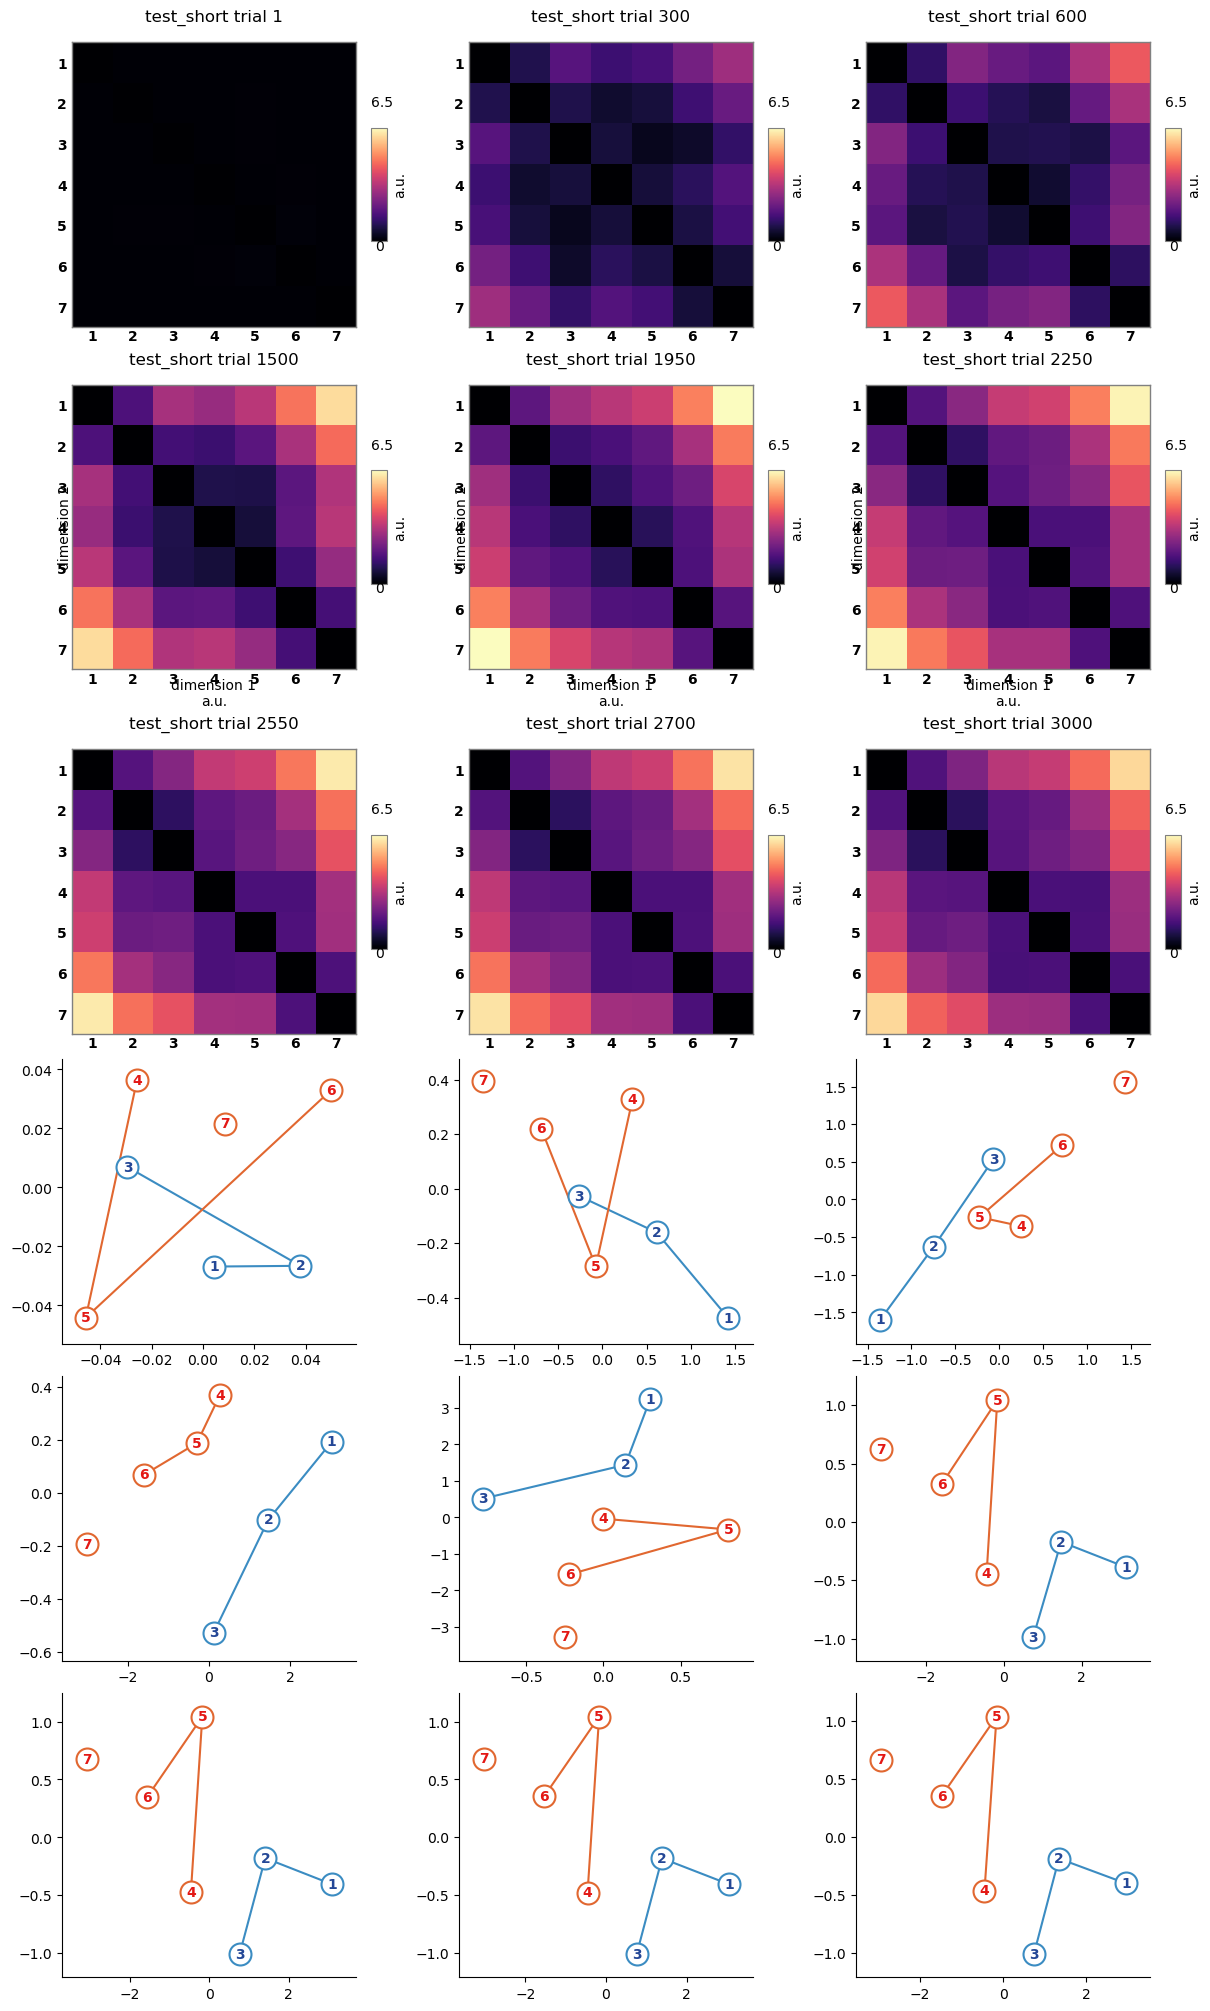

In [ ]:
sgd = 0.

positions = [0.00, 0.10, 0.20, 0.50, 0.65, 0.75, 0.85, 0.90, 1.00]

# Extraxt maximum euclidean distance
all_h1s = np.mean(results["train"]["h1s"], axis=0)

steps_after_training = all_h1s.shape[0] - 1

fig, axs = plt.subplots(6, 3, figsize=(12., 20), constrained_layout=True)
fig.patch.set_facecolor('white')

# Plot euclidean distances
vmax = 0.
for i in range(len(positions)):
    h1s = all_h1s[int(positions[i] * steps_after_training)]
    vmax_ = np.round(np.max(euclidean_distances(h1s)), 1)
    if vmax_ > vmax:
        vmax = vmax_

for idx in range(9):
    j = idx // 3
    i = idx % 3
    h1s = all_h1s[int(positions[idx] * steps_after_training)]
    im = matrix_plot_safe(euclidean_distances(h1s), axs[j, i], items_n, 0., vmax)
    axs[j, i].set_title(f"test_short trial {int(positions[idx] * steps_after_training) + 1}", pad=15)

    cbar = fig.colorbar(im, ax=axs[j, i], anchor=(0., 0.5), shrink=.4, aspect=7.)
    cbar.set_ticks([])
    cbar.ax.text(.7, vmax*1.22, vmax, ha='center', va='center')
    cbar.ax.text(.5, -0.25, 0, ha='center', va='center')
    cbar.set_label("a.u.")
    cbar.outline.set_edgecolor([0.5] * 3)

# Plot MDSs
for idx in range(9):
    j = (idx // 3) + 3
    i = idx % 3
    distances = euclidean_distances(all_h1s[int(positions[idx] * steps_after_training)])
    mds = manifold.MDS(n_components=2, eps=1e-9, dissimilarity="precomputed", random_state=mds_seed,
                    normalized_stress="auto")
    d1, d2 = mds.fit(distances).embedding_.T

    if idx == 0:
        rotate(d1, d2, 250.)
    if idx == 1:
        rotate(d1, d2, 230.)
    else:
        rotate(d1, d2, 260.)

    mds_plot((d1, d2), axs[j, i], items_n)

    # lim = 0.50
    # axs[1, i].set_xlim(-lim, lim)
    # axs[1, i].set_ylim(-lim, lim)
    # axs[1, i].set_xticks([-0.5, 0.5])
    # axs[1, i].set_yticks([-0.5, 0.5])
    
    # Set border color
    for pos in ["left", "bottom"]:
        axs[1, i].spines[pos].set_linewidth(1)
        axs[1, i].spines[pos].set_color([0.5]*3)

    axs[1, i].set_xlabel("dimension 1\na.u.", labelpad=-6.)
    axs[1, i].set_ylabel("dimension 2", labelpad=-11.)

plot H1s

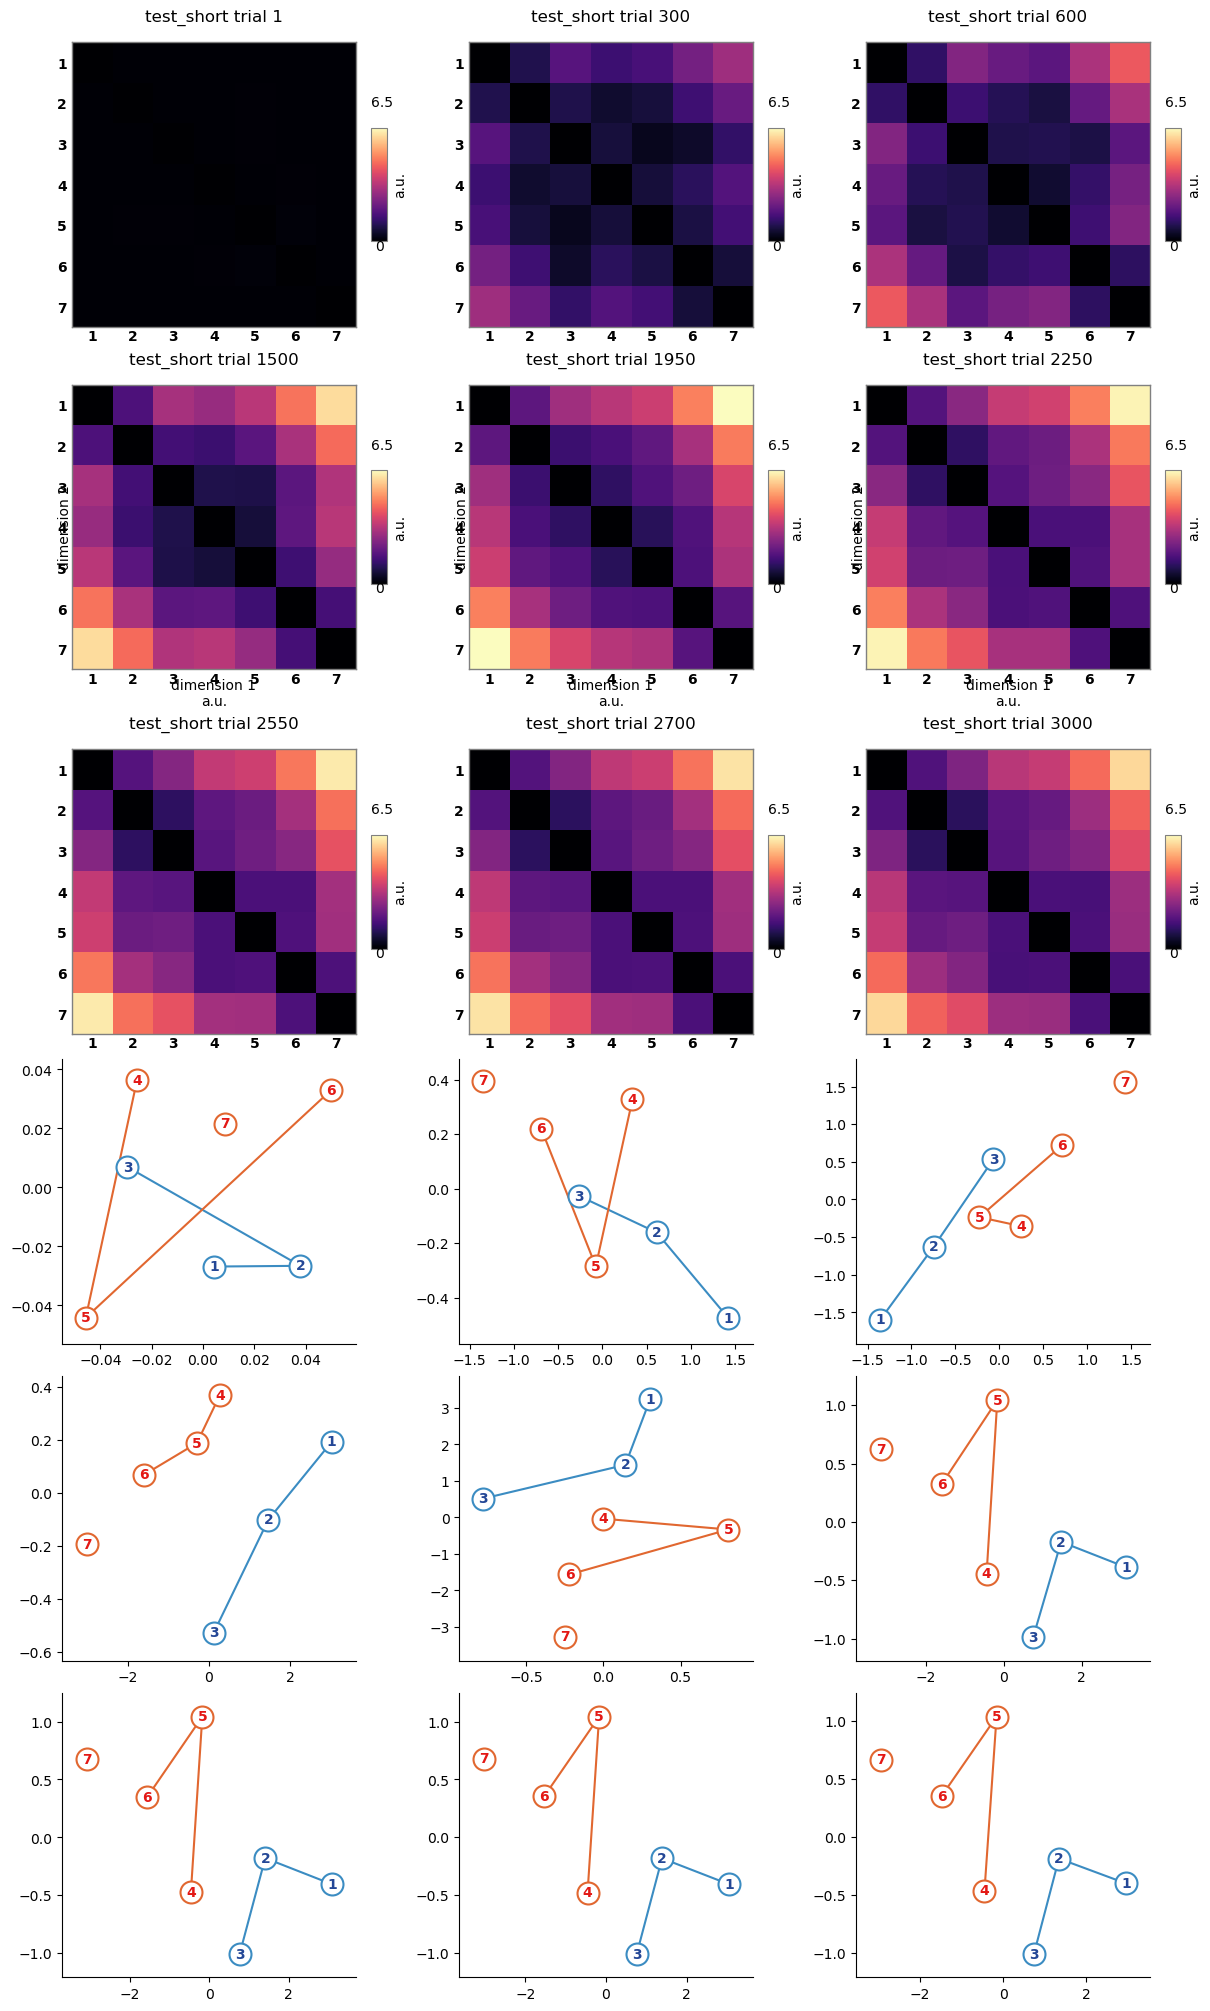

In [ ]:
sgd = 0.

positions = [0.00, 0.10, 0.20, 0.50, 0.65, 0.75, 0.85, 0.90, 1.00]

# Extraxt maximum euclidean distance
all_h1s = np.mean(results["train"]["h1s"], axis=0)

steps_after_training = all_h1s.shape[0] - 1

fig, axs = plt.subplots(6, 3, figsize=(12., 20), constrained_layout=True)
fig.patch.set_facecolor('white')

# Plot euclidean distances
vmax = 0.
for i in range(len(positions)):
    h1s = all_h1s[int(positions[i] * steps_after_training)]
    vmax_ = np.round(np.max(euclidean_distances(h1s)), 1)
    if vmax_ > vmax:
        vmax = vmax_

for idx in range(9):
    j = idx // 3
    i = idx % 3
    h1s = all_h1s[int(positions[idx] * steps_after_training)]
    im = matrix_plot_safe(euclidean_distances(h1s), axs[j, i], items_n, 0., vmax)
    axs[j, i].set_title(f"test_short trial {int(positions[idx] * steps_after_training) + 1}", pad=15)

    cbar = fig.colorbar(im, ax=axs[j, i], anchor=(0., 0.5), shrink=.4, aspect=7.)
    cbar.set_ticks([])
    cbar.ax.text(.7, vmax*1.22, vmax, ha='center', va='center')
    cbar.ax.text(.5, -0.25, 0, ha='center', va='center')
    cbar.set_label("a.u.")
    cbar.outline.set_edgecolor([0.5] * 3)

# Plot MDSs
for idx in range(9):
    j = (idx // 3) + 3
    i = idx % 3
    distances = euclidean_distances(all_h1s[int(positions[idx] * steps_after_training)])
    mds = manifold.MDS(n_components=2, eps=1e-9, dissimilarity="precomputed", random_state=mds_seed,
                    normalized_stress="auto")
    d1, d2 = mds.fit(distances).embedding_.T

    if idx == 0:
        rotate(d1, d2, 250.)
    if idx == 1:
        rotate(d1, d2, 230.)
    else:
        rotate(d1, d2, 260.)

    mds_plot((d1, d2), axs[j, i], items_n)

    # lim = 0.50
    # axs[1, i].set_xlim(-lim, lim)
    # axs[1, i].set_ylim(-lim, lim)
    # axs[1, i].set_xticks([-0.5, 0.5])
    # axs[1, i].set_yticks([-0.5, 0.5])
    
    # Set border color
    for pos in ["left", "bottom"]:
        axs[1, i].spines[pos].set_linewidth(1)
        axs[1, i].spines[pos].set_color([0.5]*3)

    axs[1, i].set_xlabel("dimension 1\na.u.", labelpad=-6.)
    axs[1, i].set_ylabel("dimension 2", labelpad=-11.)

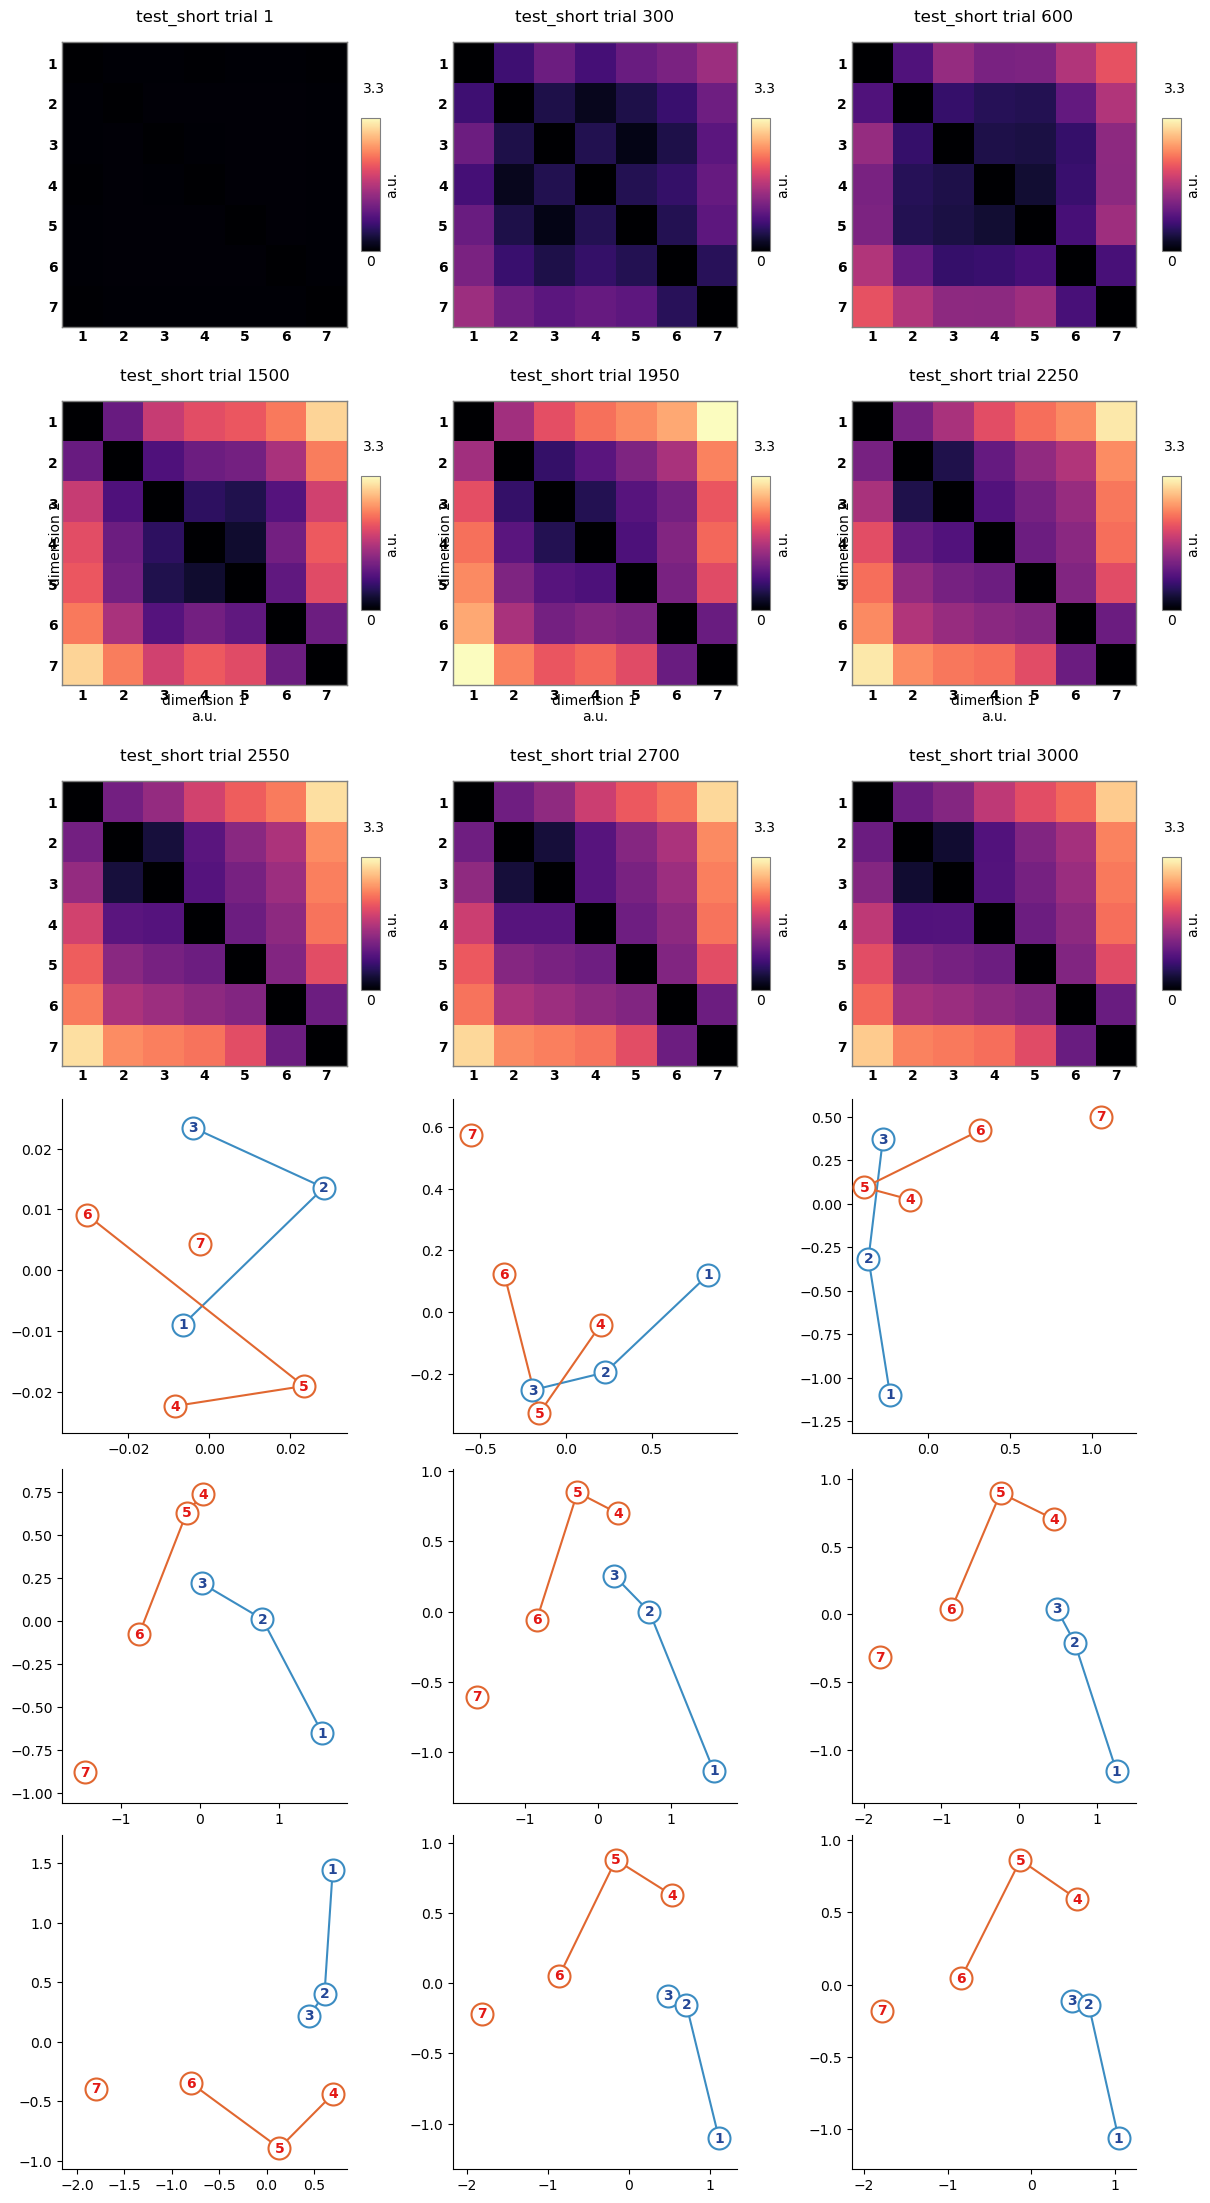

In [ ]:
sgd = 0.

positions = [0.00, 0.10, 0.20, 0.50, 0.65, 0.75, 0.85, 0.90, 1.00]

# Extraxt maximum euclidean distance
all_a1s = np.mean(results["train"]["a1s"], axis=0)

steps_after_training = all_a1s.shape[0] - 1

fig, axs = plt.subplots(6, 3, figsize=(12., 22), constrained_layout=True)
fig.patch.set_facecolor('white')

# Plot euclidean distances
vmax = 0.
for i in range(len(positions)):
    a1s = all_a1s[int(positions[i] * steps_after_training)]
    vmax_ = np.round(np.max(euclidean_distances(a1s)), 1)
    if vmax_ > vmax:
        vmax = vmax_

for idx in range(9):
    j = idx // 3
    i = idx % 3
    a1s = all_a1s[int(positions[idx] * steps_after_training)]
    im = matrix_plot_safe(euclidean_distances(a1s), axs[j, i], items_n, 0., vmax)
    axs[j, i].set_title(f"test_short trial {int(positions[idx] * steps_after_training) + 1}", pad=15)

    cbar = fig.colorbar(im, ax=axs[j, i], anchor=(0., 0.5), shrink=.4, aspect=7.)
    cbar.set_ticks([])
    cbar.ax.text(.7, vmax*1.22, vmax, ha='center', va='center')
    cbar.ax.text(.5, -0.25, 0, ha='center', va='center')
    cbar.set_label("a.u.")
    cbar.outline.set_edgecolor([0.5] * 3)

# Plot MDSs
for idx in range(9):
    j = (idx // 3) + 3
    i = idx % 3
    distances = euclidean_distances(all_a1s[int(positions[idx] * steps_after_training)])
    mds = manifold.MDS(n_components=2, eps=1e-9, dissimilarity="precomputed", random_state=mds_seed,
                    normalized_stress="auto")
    d1, d2 = mds.fit(distances).embedding_.T

    if idx == 0:
        rotate(d1, d2, 250.)
    if idx == 1:
        rotate(d1, d2, 230.)
    else:
        rotate(d1, d2, 260.)

    mds_plot((d1, d2), axs[j, i], items_n)

    # lim = 0.50
    # axs[1, i].set_xlim(-lim, lim)
    # axs[1, i].set_ylim(-lim, lim)
    # axs[1, i].set_xticks([-0.5, 0.5])
    # axs[1, i].set_yticks([-0.5, 0.5])
    
    # Set border color
    for pos in ["left", "bottom"]:
        axs[1, i].spines[pos].set_linewidth(1)
        axs[1, i].spines[pos].set_color([0.5]*3)

    axs[1, i].set_xlabel("dimension 1\na.u.", labelpad=-6.)
    axs[1, i].set_ylabel("dimension 2", labelpad=-11.)

In [ ]:
#FLAG

#Write b1s and b3s

import csv
import gzip
import shutil

# Extract training pair results and save to CSV
# We'll save the average margin over seeds for each pair (i, j) at each time step
# Additionally, save b1s and b3s activations (per time_step, item, unit) with per-seed values, mean, and std

# If results is a tuple, unpack it to get the actual results dict
if isinstance(results, tuple):
    results = results[1]
train_dict = results["train"]

# Margins (training_progress): shape (seeds_n, time_steps, items_n, items_n)
training_progress = train_dict["training_progress"]
seeds_n, time_steps, items_n, _ = training_progress.shape

# Prepare CSV header for margins
header_margins = ["time_step", "i", "j"] + [f"seed_{seed}" for seed in range(seeds_n)] + ["mean_margin", "std_margin"]

# Save b1s if available: shape (seeds_n, time_steps, items_n, b1_size)
if "b1s" in train_dict and train_dict["b1s"] is not None:
    b1s = train_dict["b1s"]
    b1_seeds, b1_time_steps, b1_items_n, b1_size = b1s.shape
    assert b1_seeds == seeds_n and b1_time_steps == time_steps and b1_items_n == items_n, "b1s shape mismatch"

    header_b1 = ["time_step", "item", "unit"] + [f"seed_{seed}" for seed in range(seeds_n)] + ["mean_activation", "std_activation"]
    rows_b1 = []
    for t in range(time_steps):
        for i in range(items_n):
            for unit in range(b1_size):
                vals = b1s[:, t, i, unit]
                rows_b1.append([t, i, unit] + list(vals) + [vals.mean(), vals.std()])

    b1_csv_filename = f"conjunctive_lazy_rich_b1s.csv"
    with open(b1_csv_filename, mode="w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow(header_b1)
        writer.writerows(rows_b1)
    # Gzip the b1s CSV
    b1_csv_gz_filename = b1_csv_filename + ".gz"
    with open(b1_csv_filename, 'rb') as f_in, gzip.open(b1_csv_gz_filename, 'wb') as f_out:
        shutil.copyfileobj(f_in, f_out)
    print(f"b1 activations saved to {b1_csv_filename} (gzipped to {b1_csv_gz_filename})")
else:
    print("b1s not found in results['train']; skipping b1 CSV.")

# Save b3s if available: shape (seeds_n, time_steps, items_n, b3_size)
if "b3s" in train_dict and train_dict["b3s"] is not None:
    b3s = train_dict["b3s"]
    b3_seeds, b3_time_steps, b3_items_n, b3_items_n = b3s.shape
    if b3_seeds == seeds_n and b3_time_steps == time_steps and b3_items_n == items_n:
        header_b3 = ["time_step", "item", "unit"] + [f"seed_{seed}" for seed in range(seeds_n)] + ["mean_activation", "std_activation"]
        rows_b3 = []
        for t in range(time_steps):
            for i in range(items_n):
                for unit in range(items_n):
                    vals = b3s[:, t, i, unit]
                    rows_b3.append([t, i, unit] + list(vals) + [vals.mean(), vals.std()])

        b3_csv_filename = f"conjunctive_lazy_rich_b3s.csv"
        with open(b3_csv_filename, mode="w", newline="") as f:
            writer = csv.writer(f)
            writer.writerow(header_b3)
            writer.writerows(rows_b3)
        # Gzip the b3s CSV
        b3_csv_gz_filename = b3_csv_filename + ".gz"
        with open(b3_csv_filename, 'rb') as f_in, gzip.open(b3_csv_gz_filename, 'wb') as f_out:
            shutil.copyfileobj(f_in, f_out)
        print(f"b3 activations saved to {b3_csv_filename} (gzipped to {b3_csv_gz_filename})")
    else:
        print("b3s shape mismatch with training_progress; skipping b3 CSV.")
else:
    print("b3s not found in results['train']; skipping b3 CSV.")

In [ ]:
# MDS of all ordered pairs (b1, from CSV) at all requested steps, with Kruskal stress-1 and (raw) Kruskal stress
import numpy as np
import matplotlib.pyplot as plt
from sklearn import manifold
from sklearn.metrics import euclidean_distances
from scipy.stats import pearsonr
import pandas as pd

# Use CSV-loaded b1 data if available; else load from gz in this folder
if 'all_b1s' in globals():
    B1_avg = all_b1s  # shape: (time_steps, items_n, b1_size) already averaged across seeds
else:
    def load_b1_mean_from_csv_gz(csv_gz_path):
        df = pd.read_csv(csv_gz_path, compression='gzip')
        seed_cols = [c for c in df.columns if c.startswith('seed_')]
        # Mean across seeds per (time_step, item, unit)
        grouped = df.groupby(['time_step', 'item', 'unit'])[seed_cols].mean()
        mean_series = grouped.mean(axis=1)  # average across seed columns
        time_steps = int(df['time_step'].max()) + 1
        items_n_inferred = int(df['item'].max()) + 1
        units = int(df['unit'].max()) + 1
        arr = np.zeros((time_steps, items_n_inferred, units))
        for (t, i, u), val in mean_series.items():
            arr[int(t), int(i), int(u)] = float(val)
        return arr
    # Try local gz produced earlier in this notebook
    B1_avg = load_b1_mean_from_csv_gz('conjunctive_lazy_rich_b1s.csv.gz')

time_steps, items_n_inferred, b1_size = B1_avg.shape

# Positions to display, used previously
positions = [0.00, 0.10, 0.20, 0.50, 0.65, 0.75, 0.85, 0.90, 1.00]
steps_after_training = time_steps - 1
step_idxs = [max(0, int(p * steps_after_training)) for p in positions]

# Utility to build all concatenated ordered pairs (i!=j)
def build_pairs(X_items):
    vecs, labels, pairs = [], [], []
    for i in range(items_n_inferred):
        for j in range(items_n_inferred):
            if i == j:
                continue
            v = np.concatenate([X_items[i], X_items[j]], axis=0)
            vecs.append(v)
            labels.append(f"({i},{j})")
            pairs.append((i, j))
    V = np.asarray(vecs)
    # mean-center features in each matrix for each step, stabilizes MDS
    V = V - V.mean(axis=0, keepdims=True)
    return V, labels, pairs

# Fit 2D metric MDS on each distance matrix; report Kruskal stress-1 and Kruskal stress (raw)
def fit_mds_with_stress(D, seed):
    mds = manifold.MDS(
        n_components=2,
        dissimilarity='precomputed',
        random_state=seed,
        n_init=4,
        normalized_stress='auto',
    )
    fit_result = mds.fit(D)
    coords = fit_result.embedding_
    stress_raw = getattr(mds, 'stress_', None)
    denom = float(np.sum(D ** 2))
    # Kruskal's stress-1 as in sklearn docs: sqrt( sum((d_ij - d̂_ij)^2) / sum(d_ij^2) )
    stress1 = np.sqrt(stress_raw / denom) if (stress_raw is not None and denom > 0) else np.nan

    # Compute the reconstructed distances
    Dr = euclidean_distances(coords)
    # Use only upper triangle (excluding diagonal)
    orig = D[np.triu_indices_from(D, k=1)]
    rec = Dr[np.triu_indices_from(Dr, k=1)]
    # Kruskal's raw stress
    kruskal_stress = np.sqrt(np.sum((orig - rec) ** 2) / np.sum(orig ** 2)) if np.sum(orig ** 2) > 0 else np.nan

    # For reporting: also include Pearson r between dist matrices
    if len(orig) > 1:
        r, _ = pearsonr(orig, rec)
    else:
        r = np.nan

    return coords, stress1, kruskal_stress, r

seed = mds_seed if 'mds_seed' in globals() else 0

nsteps = len(step_idxs)
ncols = 3
nrows = int(np.ceil(nsteps / ncols))
fig, axs = plt.subplots(nrows, ncols, figsize=(5.5*ncols, 5*nrows), constrained_layout=True)

for pidx, (pos, step_idx) in enumerate(zip(positions, step_idxs)):
    V, labels, pairs = build_pairs(B1_avg[step_idx])
    D = euclidean_distances(V)
    coords, stress1, kst, r = fit_mds_with_stress(D, seed)
    r_ax = pidx // ncols
    c_ax = pidx % ncols
    ax = axs[r_ax, c_ax] if nrows > 1 else axs[c_ax]
    ax.scatter(coords[:, 0], coords[:, 1], s=18, color='k')
    # full mds
    for i, lab in enumerate(labels):
        ax.text(coords[i, 0], coords[i, 1], lab, fontsize=8, ha='left', va='center')
    ax.axhline(0, color='lightgray', linewidth=1)
    ax.axvline(0, color='lightgray', linewidth=1)
    ax.grid(True, alpha=0.2)
    ax.set_title(
        f"step {step_idx+1} (pos={pos:.2f})\n"
        f"(stress-1={stress1:.3f}, kstress={kst:.3f}, r={r:.3f})"
    )
    ax.set_xlabel('dimension 1')
    ax.set_ylabel('dimension 2')

# Remove any excess unused subplots
for k in range(nsteps, nrows*ncols):
    fig.delaxes(axs.flatten()[k])

plt.show()


In [ ]:
# MDS of all ordered pairs (b3, from CSV) at all requested steps, with Kruskal stress-1 and (raw) Kruskal stress
import numpy as np
import matplotlib.pyplot as plt
from sklearn import manifold
from sklearn.metrics import euclidean_distances
from scipy.stats import pearsonr
import pandas as pd

# Use CSV-loaded b3 data if available; else load from gz in this folder
if 'all_b3s' in globals():
    b3_avg = all_b3s  # shape: (time_steps, items_n, b3_size) already averaged across seeds
else:
    def load_b3_mean_from_csv_gz(csv_gz_path):
        df = pd.read_csv(csv_gz_path, compression='gzip')
        seed_cols = [c for c in df.columns if c.startswith('seed_')]
        # Mean across seeds per (time_step, item, unit)
        grouped = df.groupby(['time_step', 'item', 'unit'])[seed_cols].mean()
        mean_series = grouped.mean(axis=1)  # average across seed columns
        time_steps = int(df['time_step'].max()) + 1
        items_n_inferred = int(df['item'].max()) + 1
        units = int(df['unit'].max()) + 1
        arr = np.zeros((time_steps, items_n_inferred, units))
        for (t, i, u), val in mean_series.items():
            arr[int(t), int(i), int(u)] = float(val)
        return arr
    # Try local gz produced earlier in this notebook
    b3_avg = load_b3_mean_from_csv_gz('conjunctive_lazy_rich_b3s.csv.gz')

time_steps, items_n_inferred, b3_size = b3_avg.shape

# Positions to display, used previously
positions = [0.00, 0.10, 0.20, 0.50, 0.65, 0.75, 0.85, 0.90, 1.00]
steps_after_training = time_steps - 1
step_idxs = [max(0, int(p * steps_after_training)) for p in positions]

# Utility to build all concatenated ordered pairs (i!=j)
def build_pairs(X_items):
    vecs, labels, pairs = [], [], []
    for i in range(items_n_inferred):
        for j in range(items_n_inferred):
            if i == j:
                continue
            v = np.concatenate([X_items[i], X_items[j]], axis=0)
            vecs.append(v)
            labels.append(f"({i},{j})")
            pairs.append((i, j))
    V = np.asarray(vecs)
    # mean-center features in each matrix for each step, stabilizes MDS
    V = V - V.mean(axis=0, keepdims=True)
    return V, labels, pairs

# Fit 2D metric MDS on each distance matrix; report Kruskal stress-1 and Kruskal stress (raw)
def fit_mds_with_stress(D, seed):
    mds = manifold.MDS(
        n_components=2,
        dissimilarity='precomputed',
        random_state=seed,
        n_init=4,
        normalized_stress='auto',
    )
    fit_result = mds.fit(D)
    coords = fit_result.embedding_
    stress_raw = getattr(mds, 'stress_', None)
    denom = float(np.sum(D ** 2))
    # Kruskal's stress-1 as in sklearn docs: sqrt( sum((d_ij - d̂_ij)^2) / sum(d_ij^2) )
    stress1 = np.sqrt(stress_raw / denom) if (stress_raw is not None and denom > 0) else np.nan

    # Compute the reconstructed distances
    Dr = euclidean_distances(coords)
    # Use only upper triangle (excluding diagonal)
    orig = D[np.triu_indices_from(D, k=1)]
    rec = Dr[np.triu_indices_from(Dr, k=1)]
    # Kruskal's raw stress
    kruskal_stress = np.sqrt(np.sum((orig - rec) ** 2) / np.sum(orig ** 2)) if np.sum(orig ** 2) > 0 else np.nan

    # For reporting: also include Pearson r between dist matrices
    if len(orig) > 1:
        r, _ = pearsonr(orig, rec)
    else:
        r = np.nan

    return coords, stress1, kruskal_stress, r

seed = mds_seed if 'mds_seed' in globals() else 0

nsteps = len(step_idxs)
ncols = 3
nrows = int(np.ceil(nsteps / ncols))
fig, axs = plt.subplots(nrows, ncols, figsize=(5.5*ncols, 5*nrows), constrained_layout=True)

for pidx, (pos, step_idx) in enumerate(zip(positions, step_idxs)):
    V, labels, pairs = build_pairs(b3_avg[step_idx])
    D = euclidean_distances(V)
    coords, stress1, kst, r = fit_mds_with_stress(D, seed)
    r_ax = pidx // ncols
    c_ax = pidx % ncols
    ax = axs[r_ax, c_ax] if nrows > 1 else axs[c_ax]
    ax.scatter(coords[:, 0], coords[:, 1], s=18, color='k')
    # full mds
    for i, lab in enumerate(labels):
        ax.text(coords[i, 0], coords[i, 1], lab, fontsize=8, ha='left', va='center')
    ax.axhline(0, color='lightgray', linewidth=1)
    ax.axvline(0, color='lightgray', linewidth=1)
    ax.grid(True, alpha=0.2)
    ax.set_title(
        f"step {step_idx+1} (pos={pos:.2f})\n"
        f"(stress-1={stress1:.3f}, kstress={kst:.3f}, r={r:.3f})"
    )
    ax.set_xlabel('dimension 1')
    ax.set_ylabel('dimension 2')

# Remove any excess unused subplots
for k in range(nsteps, nrows*ncols):
    fig.delaxes(axs.flatten()[k])

plt.show()


In [ ]:
# MDS of all ordered pairs (h1, from CSV) at all requested steps, with Kruskal stress-1 and (raw) Kruskal stress
import numpy as np
import matplotlib.pyplot as plt
from sklearn import manifold
from sklearn.metrics import euclidean_distances
from scipy.stats import pearsonr
import pandas as pd

# Use CSV-loaded h1 data if available; else load from gz in this folder
if 'all_h1s' in globals():
    H1_avg = all_h1s  # shape: (time_steps, items_n, h1_size) already averaged across seeds
else:
    def load_h1_mean_from_csv_gz(csv_gz_path):
        df = pd.read_csv(csv_gz_path, compression='gzip')
        seed_cols = [c for c in df.columns if c.startswith('seed_')]
        # Mean across seeds per (time_step, item, unit)
        grouped = df.groupby(['time_step', 'item', 'unit'])[seed_cols].mean()
        mean_series = grouped.mean(axis=1)  # average across seed columns
        time_steps = int(df['time_step'].max()) + 1
        items_n_inferred = int(df['item'].max()) + 1
        units = int(df['unit'].max()) + 1
        arr = np.zeros((time_steps, items_n_inferred, units))
        for (t, i, u), val in mean_series.items():
            arr[int(t), int(i), int(u)] = float(val)
        return arr
    # Try local gz produced earlier in this notebook
    H1_avg = load_h1_mean_from_csv_gz('conjunctive_lazy_rich_h1s.csv.gz')

time_steps, items_n_inferred, h1_size = H1_avg.shape

# Positions to display, used previously
positions = [0.00, 0.10, 0.20, 0.50, 0.65, 0.75, 0.85, 0.90, 1.00]
steps_after_training = time_steps - 1
step_idxs = [max(0, int(p * steps_after_training)) for p in positions]

# Utility to build all concatenated ordered pairs (i!=j)
def build_pairs(X_items):
    vecs, labels, pairs = [], [], []
    for i in range(items_n_inferred):
        for j in range(items_n_inferred):
            if i == j:
                continue
            v = np.concatenate([X_items[i], X_items[j]], axis=0)
            vecs.append(v)
            labels.append(f"({i},{j})")
            pairs.append((i, j))
    V = np.asarray(vecs)
    # mean-center features in each matrix for each step, stabilizes MDS
    V = V - V.mean(axis=0, keepdims=True)
    return V, labels, pairs

# Fit 2D metric MDS on each distance matrix; report Kruskal stress-1 and Kruskal stress (raw)
def fit_mds_with_stress(D, seed):
    mds = manifold.MDS(
        n_components=2,
        dissimilarity='precomputed',
        random_state=seed,
        n_init=4,
        normalized_stress='auto',
    )
    fit_result = mds.fit(D)
    coords = fit_result.embedding_
    stress_raw = getattr(mds, 'stress_', None)
    denom = float(np.sum(D ** 2))
    # Kruskal's stress-1 as in sklearn docs: sqrt( sum((d_ij - d̂_ij)^2) / sum(d_ij^2) )
    stress1 = np.sqrt(stress_raw / denom) if (stress_raw is not None and denom > 0) else np.nan

    # Compute the reconstructed distances
    Dr = euclidean_distances(coords)
    # Use only upper triangle (excluding diagonal)
    orig = D[np.triu_indices_from(D, k=1)]
    rec = Dr[np.triu_indices_from(Dr, k=1)]
    # Kruskal's raw stress
    kruskal_stress = np.sqrt(np.sum((orig - rec) ** 2) / np.sum(orig ** 2)) if np.sum(orig ** 2) > 0 else np.nan

    # For reporting: also include Pearson r between dist matrices
    if len(orig) > 1:
        r, _ = pearsonr(orig, rec)
    else:
        r = np.nan

    return coords, stress1, kruskal_stress, r

seed = mds_seed if 'mds_seed' in globals() else 0

nsteps = len(step_idxs)
ncols = 3
nrows = int(np.ceil(nsteps / ncols))
fig, axs = plt.subplots(nrows, ncols, figsize=(5.5*ncols, 5*nrows), constrained_layout=True)

for pidx, (pos, step_idx) in enumerate(zip(positions, step_idxs)):
    V, labels, pairs = build_pairs(H1_avg[step_idx])
    D = euclidean_distances(V)
    coords, stress1, kst, r = fit_mds_with_stress(D, seed)
    r_ax = pidx // ncols
    c_ax = pidx % ncols
    ax = axs[r_ax, c_ax] if nrows > 1 else axs[c_ax]
    ax.scatter(coords[:, 0], coords[:, 1], s=18, color='k')
    # full mds
    for i, lab in enumerate(labels):
        ax.text(coords[i, 0], coords[i, 1], lab, fontsize=8, ha='left', va='center')
    ax.axhline(0, color='lightgray', linewidth=1)
    ax.axvline(0, color='lightgray', linewidth=1)
    ax.grid(True, alpha=0.2)
    ax.set_title(
        f"step {step_idx+1} (pos={pos:.2f})\n"
        f"(stress-1={stress1:.3f}, kstress={kst:.3f}, r={r:.3f})"
    )
    ax.set_xlabel('dimension 1')
    ax.set_ylabel('dimension 2')

# Remove any excess unused subplots
for k in range(nsteps, nrows*ncols):
    fig.delaxes(axs.flatten()[k])

plt.show()


# (3) Look at Hidden Representations   

In [ ]:
#laod b1s and b3s

# MDS of all ordered pairs (b1, from CSV) at all requested steps, with Kruskal stress-1 and (raw) Kruskal stress
import numpy as np
import matplotlib.pyplot as plt
from sklearn import manifold
from sklearn.metrics import euclidean_distances
from scipy.stats import pearsonr
import pandas as pd

# Use CSV-loaded b1 data if available; else load from gz in this folder
if 'all_b1s' in globals():
    B1_avg = all_b1s  # shape: (time_steps, items_n, b1_size) already averaged across seeds
else:
    def load_b1_mean_from_csv_gz(csv_gz_path):
        df = pd.read_csv(csv_gz_path, compression='gzip')
        seed_cols = [c for c in df.columns if c.startswith('seed_')]
        # Mean across seeds per (time_step, item, unit)
        grouped = df.groupby(['time_step', 'item', 'unit'])[seed_cols].mean()
        mean_series = grouped.mean(axis=1)  # average across seed columns
        time_steps = int(df['time_step'].max()) + 1
        items_n_inferred = int(df['item'].max()) + 1
        units = int(df['unit'].max()) + 1
        arr = np.zeros((time_steps, items_n_inferred, units))
        for (t, i, u), val in mean_series.items():
            arr[int(t), int(i), int(u)] = float(val)
        return arr
    # Try local gz produced earlier in this notebook
    B1_avg = load_b1_mean_from_csv_gz('conjunctive_lazy_rich_b1s.csv.gz')

time_steps, items_n_inferred, b1_size = B1_avg.shape

# Positions to display, used previously
positions = [0.00, 0.10, 0.20, 0.50, 0.65, 0.75, 0.85, 0.90, 1.00]
steps_after_training = time_steps - 1
step_idxs = [max(0, int(p * steps_after_training)) for p in positions]

# Utility to build all concatenated ordered pairs (i!=j)
def build_pairs(X_items):
    vecs, labels, pairs = [], [], []
    for i in range(items_n_inferred):
        for j in range(items_n_inferred):
            if i == j:
                continue
            v = np.concatenate([X_items[i], X_items[j]], axis=0)
            vecs.append(v)
            labels.append(f"({i},{j})")
            pairs.append((i, j))
    V = np.asarray(vecs)
    # mean-center features in each matrix for each step, stabilizes MDS
    V = V - V.mean(axis=0, keepdims=True)
    return V, labels, pairs

# Fit 2D metric MDS on each distance matrix; report Kruskal stress-1 and Kruskal stress (raw)
def fit_mds_with_stress(D, seed):
    mds = manifold.MDS(
        n_components=2,
        dissimilarity='precomputed',
        random_state=seed,
        n_init=4,
        normalized_stress='auto',
    )
    fit_result = mds.fit(D)
    coords = fit_result.embedding_
    stress_raw = getattr(mds, 'stress_', None)
    denom = float(np.sum(D ** 2))
    # Kruskal's stress-1 as in sklearn docs: sqrt( sum((d_ij - d̂_ij)^2) / sum(d_ij^2) )
    stress1 = np.sqrt(stress_raw / denom) if (stress_raw is not None and denom > 0) else np.nan

    # Compute the reconstructed distances
    Dr = euclidean_distances(coords)
    # Use only upper triangle (excluding diagonal)
    orig = D[np.triu_indices_from(D, k=1)]
    rec = Dr[np.triu_indices_from(Dr, k=1)]
    # Kruskal's raw stress
    kruskal_stress = np.sqrt(np.sum((orig - rec) ** 2) / np.sum(orig ** 2)) if np.sum(orig ** 2) > 0 else np.nan

    # For reporting: also include Pearson r between dist matrices
    if len(orig) > 1:
        r, _ = pearsonr(orig, rec)
    else:
        r = np.nan

    return coords, stress1, kruskal_stress, r

seed = mds_seed if 'mds_seed' in globals() else 0

nsteps = len(step_idxs)
ncols = 3
nrows = int(np.ceil(nsteps / ncols))
fig, axs = plt.subplots(nrows, ncols, figsize=(5.5*ncols, 5*nrows), constrained_layout=True)

for pidx, (pos, step_idx) in enumerate(zip(positions, step_idxs)):
    V, labels, pairs = build_pairs(B1_avg[step_idx])
    D = euclidean_distances(V)
    coords, stress1, kst, r = fit_mds_with_stress(D, seed)
    r_ax = pidx // ncols
    c_ax = pidx % ncols
    ax = axs[r_ax, c_ax] if nrows > 1 else axs[c_ax]
    ax.scatter(coords[:, 0], coords[:, 1], s=18, color='k')
    # full mds
    for i, lab in enumerate(labels):
        ax.text(coords[i, 0], coords[i, 1], lab, fontsize=8, ha='left', va='center')
    ax.axhline(0, color='lightgray', linewidth=1)
    ax.axvline(0, color='lightgray', linewidth=1)
    ax.grid(True, alpha=0.2)
    ax.set_title(
        f"step {step_idx+1} (pos={pos:.2f})\n"
        f"(stress-1={stress1:.3f}, kstress={kst:.3f}, r={r:.3f})"
    )
    ax.set_xlabel('dimension 1')
    ax.set_ylabel('dimension 2')

# Remove any excess unused subplots
for k in range(nsteps, nrows*ncols):
    fig.delaxes(axs.flatten()[k])

plt.show()


# Load CSVs for Representations

In [ ]:
# Neural Knowledge Assembly-style visualization adapted to this network
# - Top row: Euclidean distance matrices of hidden layer h1s at 3 training positions
# - Bottom row: 2D MDS embeddings at the same positions

import numpy as np
import matplotlib.pyplot as plt
from sklearn import manifold
from sklearn.metrics import euclidean_distances
import pandas as pd
from helpers import rotate
from plotting import mds_plot

# Local CSV.GZ loader for h1s/h2s saved earlier in this notebook
def load_layer_from_csv_gz(csv_gz_path):
    df = pd.read_csv(csv_gz_path, compression='gzip')
    seed_cols = [c for c in df.columns if c.startswith('seed_')]
    time_steps = int(df['time_step'].max()) + 1
    items_n = int(df['item'].max()) + 1
    units = int(df['unit'].max()) + 1
    seeds_n = len(seed_cols)
    arr = np.zeros((seeds_n, time_steps, items_n, units))
    for _, row in df.iterrows():
        t = int(row['time_step']); i = int(row['item']); u = int(row['unit'])
        for s_idx, sc in enumerate(seed_cols):
            arr[s_idx, t, i, u] = row[sc]
    return arr

# Local safe matrix plot that works for odd items_n (do not rely on plotting.matrix_plot)
def matrix_plot_safe(data, ax, items_n, vmin=None, vmax=None):
    if vmin is None:
        im = ax.imshow(data, cmap=plt.cm.magma)
    else:
        im = ax.imshow(data, cmap=plt.cm.magma, vmin=vmin, vmax=vmax)
    ax.set_xticks(range(items_n))
    ax.set_yticks(range(items_n))
    if items_n % 2 == 0:
        labels = list(range(1, items_n // 2 + 1)) * 2
    else:
        labels = list(range(1, items_n + 1))
    ax.set_xticklabels(labels, va='center', fontsize=10, fontweight="bold")
    ax.set_yticklabels(labels, ha='center', fontsize=10, fontweight="bold")
    ax.tick_params(left=False, bottom=False)
    for pos in ["top", "right", "bottom", "left"]:
        ax.spines[pos].set_linewidth(1)
        ax.spines[pos].set_color([0.5] * 3)
    return im

# Load h1s from gzipped CSV written by the CSV export cell
csv_gz_h1_path = "conjunctive_lazy_rich_h1s.csv.gz"
h1s_loaded = load_layer_from_csv_gz(csv_gz_h1_path)
all_h1s = h1s_loaded.mean(axis=0)  # (time_steps, items_n, h1_size)
items_n = all_h1s.shape[1]
steps_after_training = all_h1s.shape[0] - 1
mds_seed = 0

# Load h2s from gzipped CSV written by the CSV export cell
csv_gz_h2_path = "conjunctive_lazy_rich_h2s.csv.gz"
h2s_loaded = load_layer_from_csv_gz(csv_gz_h2_path)
all_h2s = h2s_loaded.mean(axis=0)  # (time_steps, items_n, h2_size)
items_n = all_h2s.shape[1]
steps_after_training = all_h2s.shape[0] - 1
mds_seed = 0

# Extract results of hidden layers to csv

In [ ]:
## [TODO] figure out what h1 is doing here
# what is d in mds fit?
#     V, labels, pairs = build_pairs(H1_avg[step_idx])
# D = euclidean_distances(V)

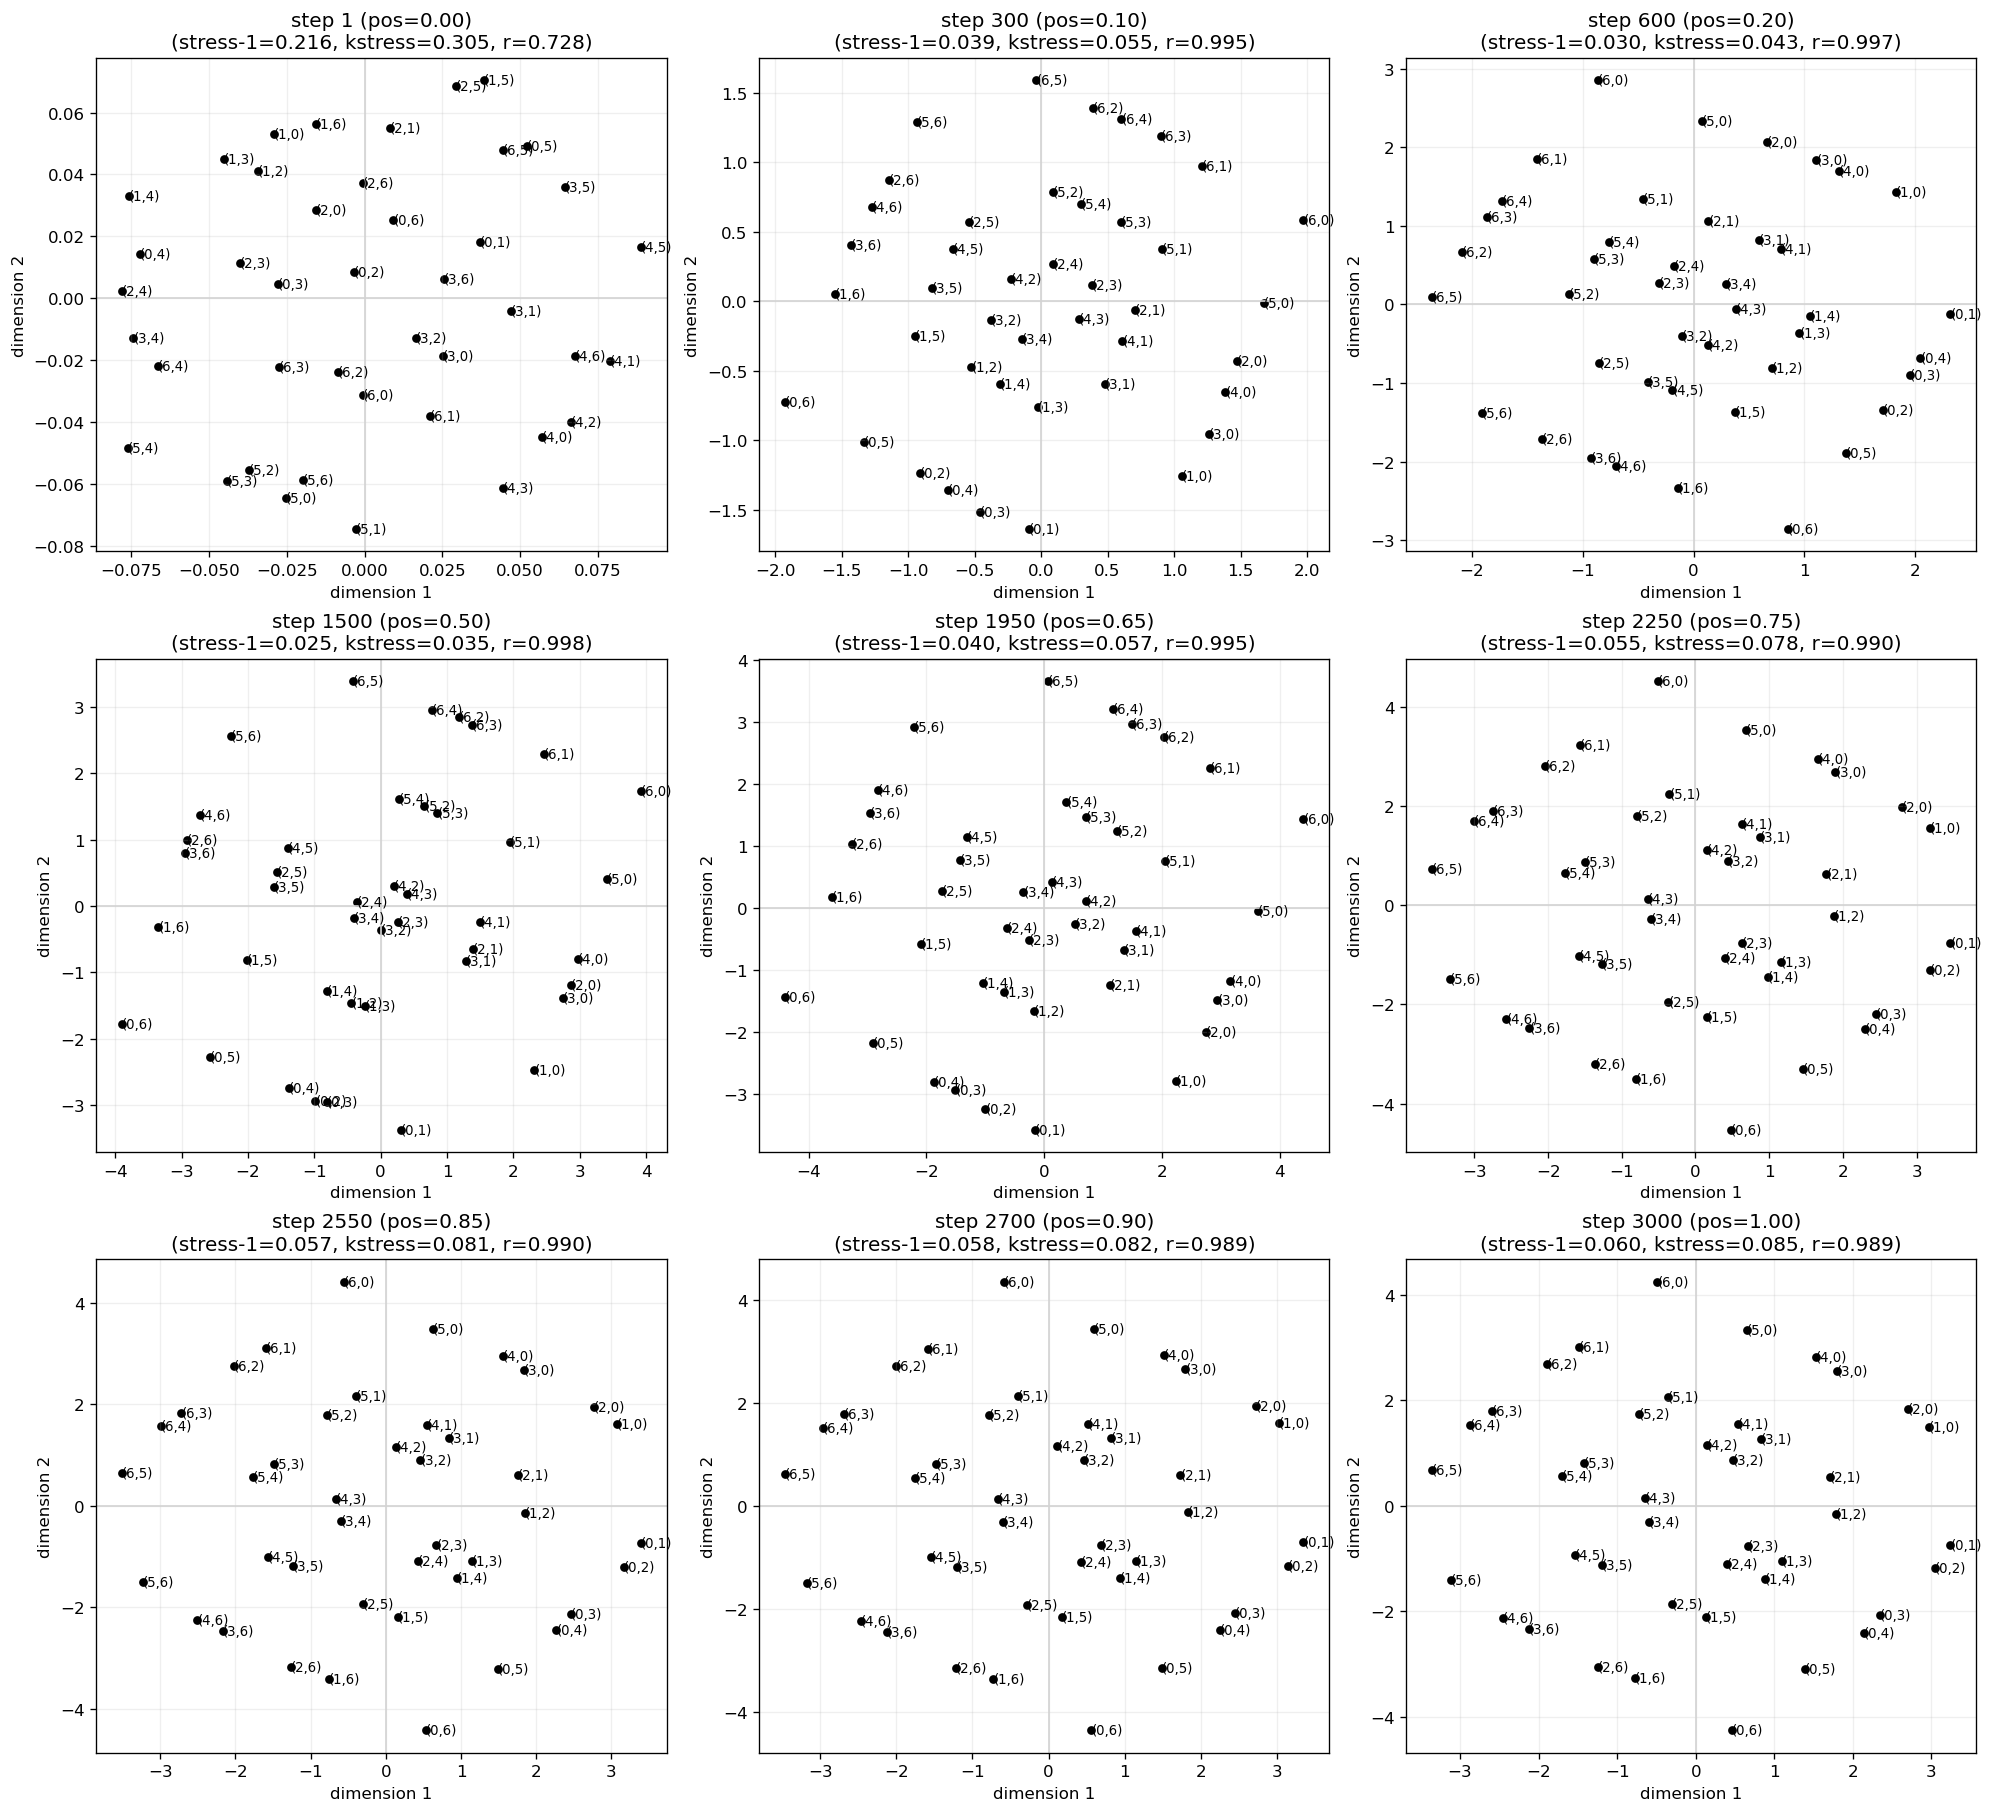

In [ ]:
# MDS of all ordered pairs (h1, from CSV) at all requested steps, with Kruskal stress-1 and (raw) Kruskal stress
import numpy as np
import matplotlib.pyplot as plt
from sklearn import manifold
from sklearn.metrics import euclidean_distances
from scipy.stats import pearsonr
import pandas as pd

# Use CSV-loaded h1 data if available; else load from gz in this folder
if 'all_h1s' in globals():
    H1_avg = all_h1s  # shape: (time_steps, items_n, h1_size) already averaged across seeds
else:
    def load_h1_mean_from_csv_gz(csv_gz_path):
        df = pd.read_csv(csv_gz_path, compression='gzip')
        seed_cols = [c for c in df.columns if c.startswith('seed_')]
        # Mean across seeds per (time_step, item, unit)
        grouped = df.groupby(['time_step', 'item', 'unit'])[seed_cols].mean()
        mean_series = grouped.mean(axis=1)  # average across seed columns
        time_steps = int(df['time_step'].max()) + 1
        items_n_inferred = int(df['item'].max()) + 1
        units = int(df['unit'].max()) + 1
        arr = np.zeros((time_steps, items_n_inferred, units))
        for (t, i, u), val in mean_series.items():
            arr[int(t), int(i), int(u)] = float(val)
        return arr
    # Try local gz produced earlier in this notebook
    H1_avg = load_h1_mean_from_csv_gz('conjunctive_lazy_rich_h1s.csv.gz')

time_steps, items_n_inferred, h1_size = H1_avg.shape

# Positions to display, used previously
positions = [0.00, 0.10, 0.20, 0.50, 0.65, 0.75, 0.85, 0.90, 1.00]
steps_after_training = time_steps - 1
step_idxs = [max(0, int(p * steps_after_training)) for p in positions]

# Utility to build all concatenated ordered pairs (i!=j)
def build_pairs(X_items):
    vecs, labels, pairs = [], [], []
    for i in range(items_n_inferred):
        for j in range(items_n_inferred):
            if i == j:
                continue
            v = np.concatenate([X_items[i], X_items[j]], axis=0)
            vecs.append(v)
            labels.append(f"({i},{j})")
            pairs.append((i, j))
    V = np.asarray(vecs)
    # mean-center features in each matrix for each step, stabilizes MDS
    V = V - V.mean(axis=0, keepdims=True)
    return V, labels, pairs

# Fit 2D metric MDS on each distance matrix; report Kruskal stress-1 and Kruskal stress (raw)
def fit_mds_with_stress(D, seed):
    mds = manifold.MDS(
        n_components=2,
        dissimilarity='precomputed',
        random_state=seed,
        n_init=4,
        normalized_stress='auto',
    )
    fit_result = mds.fit(D)
    coords = fit_result.embedding_
    stress_raw = getattr(mds, 'stress_', None)
    denom = float(np.sum(D ** 2))
    # Kruskal's stress-1 as in sklearn docs: sqrt( sum((d_ij - d̂_ij)^2) / sum(d_ij^2) )
    stress1 = np.sqrt(stress_raw / denom) if (stress_raw is not None and denom > 0) else np.nan

    # Compute the reconstructed distances
    Dr = euclidean_distances(coords)
    # Use only upper triangle (excluding diagonal)
    orig = D[np.triu_indices_from(D, k=1)]
    rec = Dr[np.triu_indices_from(Dr, k=1)]
    # Kruskal's raw stress
    kruskal_stress = np.sqrt(np.sum((orig - rec) ** 2) / np.sum(orig ** 2)) if np.sum(orig ** 2) > 0 else np.nan

    # For reporting: also include Pearson r between dist matrices
    if len(orig) > 1:
        r, _ = pearsonr(orig, rec)
    else:
        r = np.nan

    return coords, stress1, kruskal_stress, r

seed = mds_seed if 'mds_seed' in globals() else 0

nsteps = len(step_idxs)
ncols = 3
nrows = int(np.ceil(nsteps / ncols))
fig, axs = plt.subplots(nrows, ncols, figsize=(5.5*ncols, 5*nrows), constrained_layout=True)

for pidx, (pos, step_idx) in enumerate(zip(positions, step_idxs)):
    V, labels, pairs = build_pairs(H1_avg[step_idx])
    D = euclidean_distances(V)
    coords, stress1, kst, r = fit_mds_with_stress(D, seed)
    r_ax = pidx // ncols
    c_ax = pidx % ncols
    ax = axs[r_ax, c_ax] if nrows > 1 else axs[c_ax]
    ax.scatter(coords[:, 0], coords[:, 1], s=18, color='k')
    # full mds
    for i, lab in enumerate(labels):
        ax.text(coords[i, 0], coords[i, 1], lab, fontsize=8, ha='left', va='center')
    ax.axhline(0, color='lightgray', linewidth=1)
    ax.axvline(0, color='lightgray', linewidth=1)
    ax.grid(True, alpha=0.2)
    ax.set_title(
        f"step {step_idx+1} (pos={pos:.2f})\n"
        f"(stress-1={stress1:.3f}, kstress={kst:.3f}, r={r:.3f})"
    )
    ax.set_xlabel('dimension 1')
    ax.set_ylabel('dimension 2')

# Remove any excess unused subplots
for k in range(nsteps, nrows*ncols):
    fig.delaxes(axs.flatten()[k])

plt.show()


In [ ]:
# Categories you already built (each includes both orders)
categories = {
    "Exception": exception_pair,                         # e.g., [(2,4), (4,2)]
    "Adj. Exception": adjacent_exception_pairs,          # both orders included
    "Adj. Non-exception": adjacent_nonexception_pairs,   # both orders included
    "Generalization": generalization_pairs               # both orders included
}
cat_colors = {
    "Exception": "crimson",
    "Adj. Exception": "darkorange",
    "Adj. Non-exception": "steelblue",
    "Generalization": "seagreen",
}

def _indices_for_pairs(all_pairs, selected_pairs):
    # all_pairs is the list produced by build_pairs(...), contains ordered (i,j)
    idxs = []
    sel = set(selected_pairs)  # ensures O(1) lookups; selected already includes both orders
    for k, pij in enumerate(all_pairs):
        if pij in sel:
            idxs.append(k)
    return np.asarray(idxs, dtype=int)

# Add labels to the filtered MDS grids
def plot_mds_filtered_grids_labeled(M_list, positions, title_prefix):
    time_steps = len(M_list)
    steps_after_training = time_steps - 1
    step_idxs = [max(0, int(p * steps_after_training)) for p in positions]

    for cat_name, sel_pairs in categories.items():
        fig, axs = plt.subplots(3, 3, figsize=(12., 12.), constrained_layout=False)
        fig.patch.set_facecolor('white')

        for pidx, (pos, step_idx) in enumerate(zip(positions, step_idxs)):
            r, c = divmod(pidx, 3)
            ax = axs[r, c]

            # Build all ordered pairs, fit on all for consistent embedding
            V, labels, all_pairs = build_pairs(M_list[step_idx])
            coords = fit_2d(V, seed=0)

            # Optional: context points
            ax.scatter(coords[:, 0], coords[:, 1], s=8, color='lightgray', alpha=0.25, zorder=1)

            # Indices for selected category
            sel_set = set(sel_pairs)
            sel_idxs = [k for k, pij in enumerate(all_pairs) if pij in sel_set]

            # Plot and label only selected pairs
            if sel_idxs:
                sel_coords = coords[sel_idxs]
                sel_labels = [labels[k] for k in sel_idxs]
                ax.scatter(sel_coords[:, 0], sel_coords[:, 1],
                           s=22, color=cat_colors[cat_name], alpha=0.95, zorder=2)

                # Text labels with a tiny offset to reduce overlap
                for (x, y), lab in zip(sel_coords, sel_labels):
                    ax.text(x + 0.01, y + 0.01, lab, fontsize=7,
                            color=cat_colors[cat_name], zorder=3)

            ax.axhline(0, color='lightgray', linewidth=1)
            ax.axvline(0, color='lightgray', linewidth=1)
            ax.grid(True, alpha=0.2)
            ax.set_title(f"{title_prefix} — {cat_name}\nstep {step_idx+1} (pos={pos:.2f})")
            ax.set_xlabel('dimension 1'); ax.set_ylabel('dimension 2')

        plt.show()

plot_mds_filtered_grids_labeled(H1_avg, positions=[0.00,0.10,0.20,0.50,0.65,0.75,0.85,0.90,1.00], title_prefix="h1")


NameError: name 'exception_pair' is not defined

# H1s with ReLU (wrong because the network needs both after the relu)

if
[[[ 9.70296562e-04  5.67313796e-03 -1.09438794e-02 ... -1.02472454e-02
   -5.25645027e-03  2.21462385e-03]
  [-4.56399471e-03  8.27027659e-04  3.37908976e-04 ...  6.81899069e-03
    1.95650216e-02  1.63735356e-03]
  [-2.46428722e-03  6.64884970e-03 -3.49097420e-03 ...  2.95038498e-03
    6.70924224e-03  1.62916351e-02]
  ...
  [ 2.67775040e-02 -1.59718711e-02  2.40994315e-03 ... -1.48219662e-02
   -7.05607794e-03 -1.93366501e-02]
  [-3.86998914e-02  2.29491829e-03  2.58899131e-03 ... -8.95779594e-05
    6.85856212e-03  1.23622799e-02]
  [-5.54951373e-03  5.59911085e-03 -5.30192070e-03 ... -7.85515737e-03
    3.81234381e-03 -2.97349901e-03]]

 [[ 9.70296562e-04  5.67313796e-03 -1.09438794e-02 ... -1.02472454e-02
   -5.25645027e-03  2.21462385e-03]
  [-4.56399471e-03  8.27027659e-04  3.37908976e-04 ...  6.81899069e-03
    1.95650216e-02  1.63735356e-03]
  [-2.46428722e-03  6.64884970e-03 -3.49097420e-03 ...  2.95038498e-03
    6.70924224e-03  1.62916351e-02]
  ...
  [ 2.67775040e-02 -

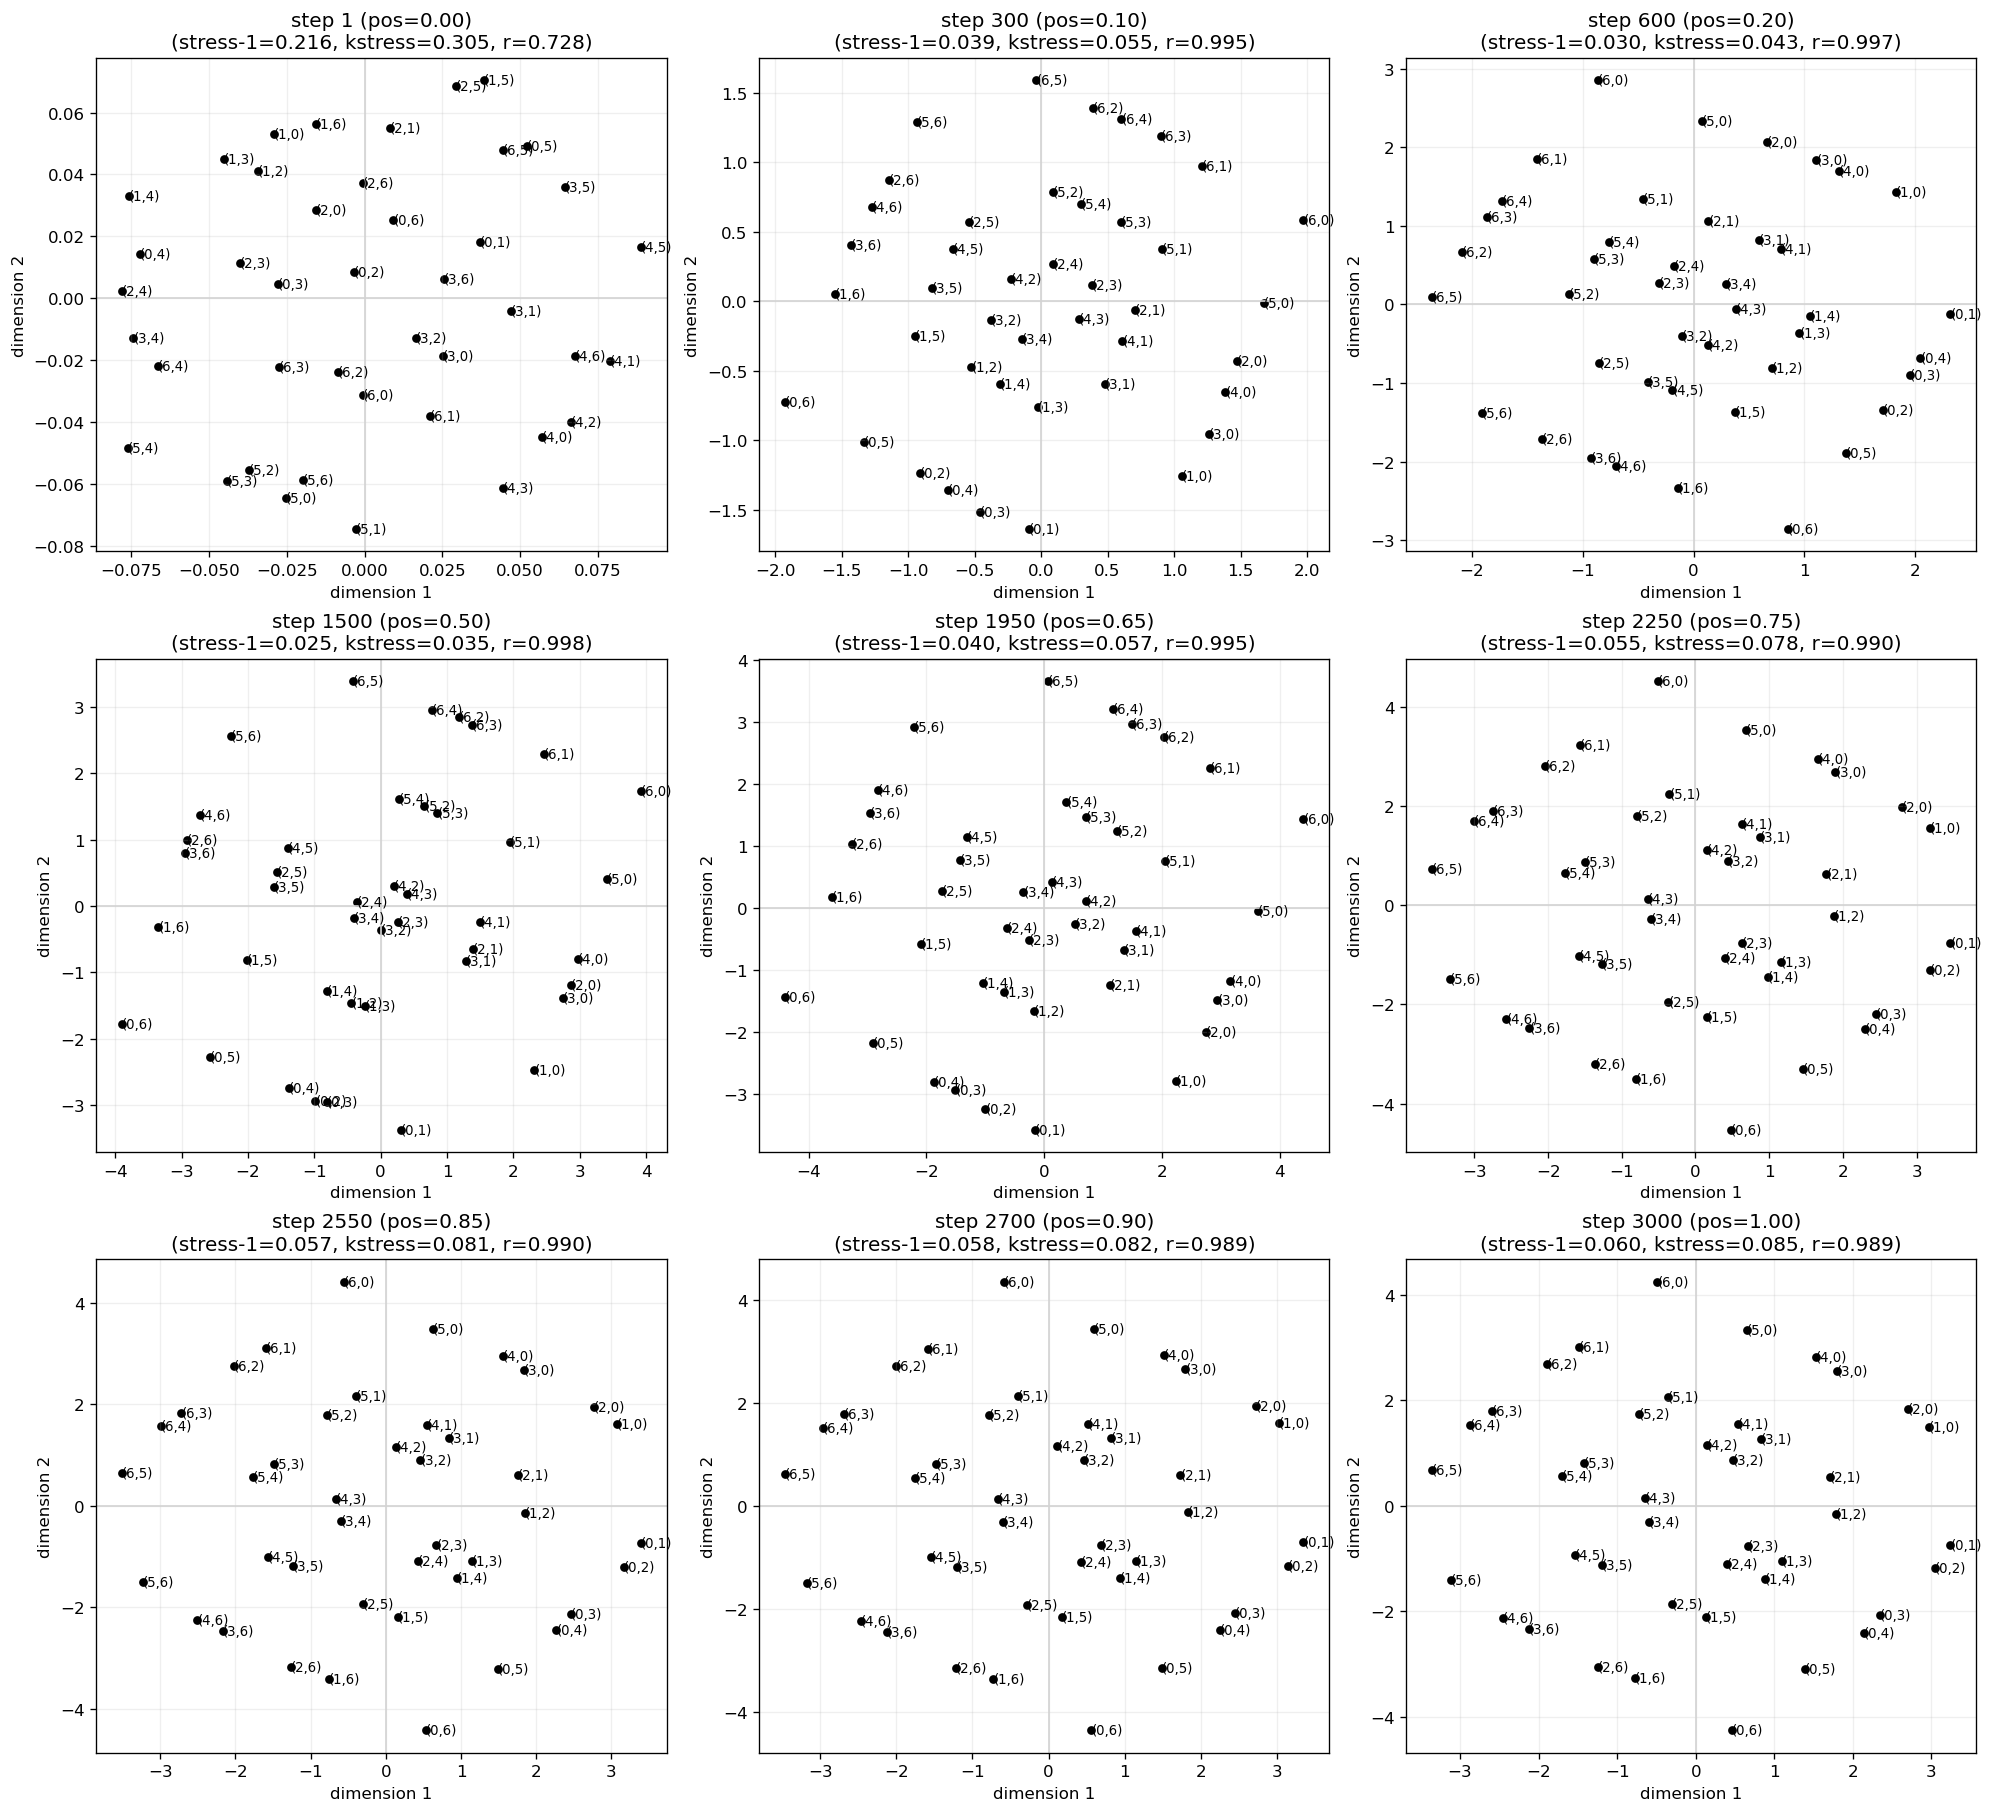

In [123]:
# MDS of all ordered pairs (h1, from CSV) at all requested steps, with Kruskal stress-1 and (raw) Kruskal stress
import numpy as np
import matplotlib.pyplot as plt
from sklearn import manifold
from sklearn.metrics import euclidean_distances
from scipy.stats import pearsonr
import pandas as pd

# Use CSV-loaded h1 data if available; else load from gz in this folder
if 'all_h1s' in globals():
    print("if")
    H1_avg = all_h1s  # shape: (time_steps, items_n, h1_size) already averaged across seeds
    print(all_h1s)
else:
    print("else")
    def load_h1_mean_from_csv_gz(csv_gz_path):
        df = pd.read_csv(csv_gz_path, compression='gzip')
        seed_cols = [c for c in df.columns if c.startswith('seed_')]
        # Mean across seeds per (time_step, item, unit)
        grouped = df.groupby(['time_step', 'item', 'unit'])[seed_cols].mean()
        mean_series = grouped.mean(axis=1)  # average across seed columns
        time_steps = int(df['time_step'].max()) + 1
        items_n_inferred = int(df['item'].max()) + 1
        units = int(df['unit'].max()) + 1
        arr = np.zeros((time_steps, items_n_inferred, units))
        for (t, i, u), val in mean_series.items():
            arr[int(t), int(i), int(u)] = float(val)
        return arr
    # Try local gz produced earlier in this notebook
    H1_avg = load_h1_mean_from_csv_gz('conjunctive_lazy_rich_h1s.csv.gz')
    #relu
    H1_avg = np.maximum(0, H1_avg)

time_steps, items_n_inferred, h1_size = H1_avg.shape

# Positions to display, used previously
positions = [0.00, 0.10, 0.20, 0.50, 0.65, 0.75, 0.85, 0.90, 1.00]
steps_after_training = time_steps - 1
step_idxs = [max(0, int(p * steps_after_training)) for p in positions]

# Utility to build all concatenated ordered pairs (i!=j)
def build_pairs(X_items):
    vecs, labels, pairs = [], [], []
    for i in range(items_n_inferred):
        for j in range(items_n_inferred):
            if i == j:
                continue
            v = np.concatenate([X_items[i], X_items[j]], axis=0)
            vecs.append(v)
            labels.append(f"({i},{j})")
            pairs.append((i, j))
    V = np.asarray(vecs)
    # mean-center features in each matrix for each step, stabilizes MDS
    V = V - V.mean(axis=0, keepdims=True)
    return V, labels, pairs

# Fit 2D metric MDS on each distance matrix; report Kruskal stress-1 and Kruskal stress (raw)
def fit_mds_with_stress(D, seed):
    mds = manifold.MDS(
        n_components=2,
        dissimilarity='precomputed',
        random_state=seed,
        n_init=4,
        normalized_stress='auto',
    )
    fit_result = mds.fit(D)
    coords = fit_result.embedding_
    stress_raw = getattr(mds, 'stress_', None)
    denom = float(np.sum(D ** 2))
    # Kruskal's stress-1 as in sklearn docs: sqrt( sum((d_ij - d̂_ij)^2) / sum(d_ij^2) )
    stress1 = np.sqrt(stress_raw / denom) if (stress_raw is not None and denom > 0) else np.nan

    # Compute the reconstructed distances
    Dr = euclidean_distances(coords)
    # Use only upper triangle (excluding diagonal)
    orig = D[np.triu_indices_from(D, k=1)]
    rec = Dr[np.triu_indices_from(Dr, k=1)]
    # Kruskal's raw stress
    kruskal_stress = np.sqrt(np.sum((orig - rec) ** 2) / np.sum(orig ** 2)) if np.sum(orig ** 2) > 0 else np.nan

    # For reporting: also include Pearson r between dist matrices
    if len(orig) > 1:
        r, _ = pearsonr(orig, rec)
    else:
        r = np.nan

    return coords, stress1, kruskal_stress, r

seed = mds_seed if 'mds_seed' in globals() else 0

nsteps = len(step_idxs)
ncols = 3
nrows = int(np.ceil(nsteps / ncols))
fig, axs = plt.subplots(nrows, ncols, figsize=(5.5*ncols, 5*nrows), constrained_layout=True)

for pidx, (pos, step_idx) in enumerate(zip(positions, step_idxs)):
    V, labels, pairs = build_pairs(H1_avg[step_idx])
    D = euclidean_distances(V)
    coords, stress1, kst, r = fit_mds_with_stress(D, seed)
    r_ax = pidx // ncols
    c_ax = pidx % ncols
    ax = axs[r_ax, c_ax] if nrows > 1 else axs[c_ax]
    ax.scatter(coords[:, 0], coords[:, 1], s=18, color='k')
    for i, lab in enumerate(labels):
        ax.text(coords[i, 0], coords[i, 1], lab, fontsize=8, ha='left', va='center')
    ax.axhline(0, color='lightgray', linewidth=1)
    ax.axvline(0, color='lightgray', linewidth=1)
    ax.grid(True, alpha=0.2)
    ax.set_title(
        f"step {step_idx+1} (pos={pos:.2f})\n"
        f"(stress-1={stress1:.3f}, kstress={kst:.3f}, r={r:.3f})"
    )
    ax.set_xlabel('dimension 1')
    ax.set_ylabel('dimension 2')

# Remove any excess unused subplots
for k in range(nsteps, nrows*ncols):
    fig.delaxes(axs.flatten()[k])

plt.show()


# H2 MDS

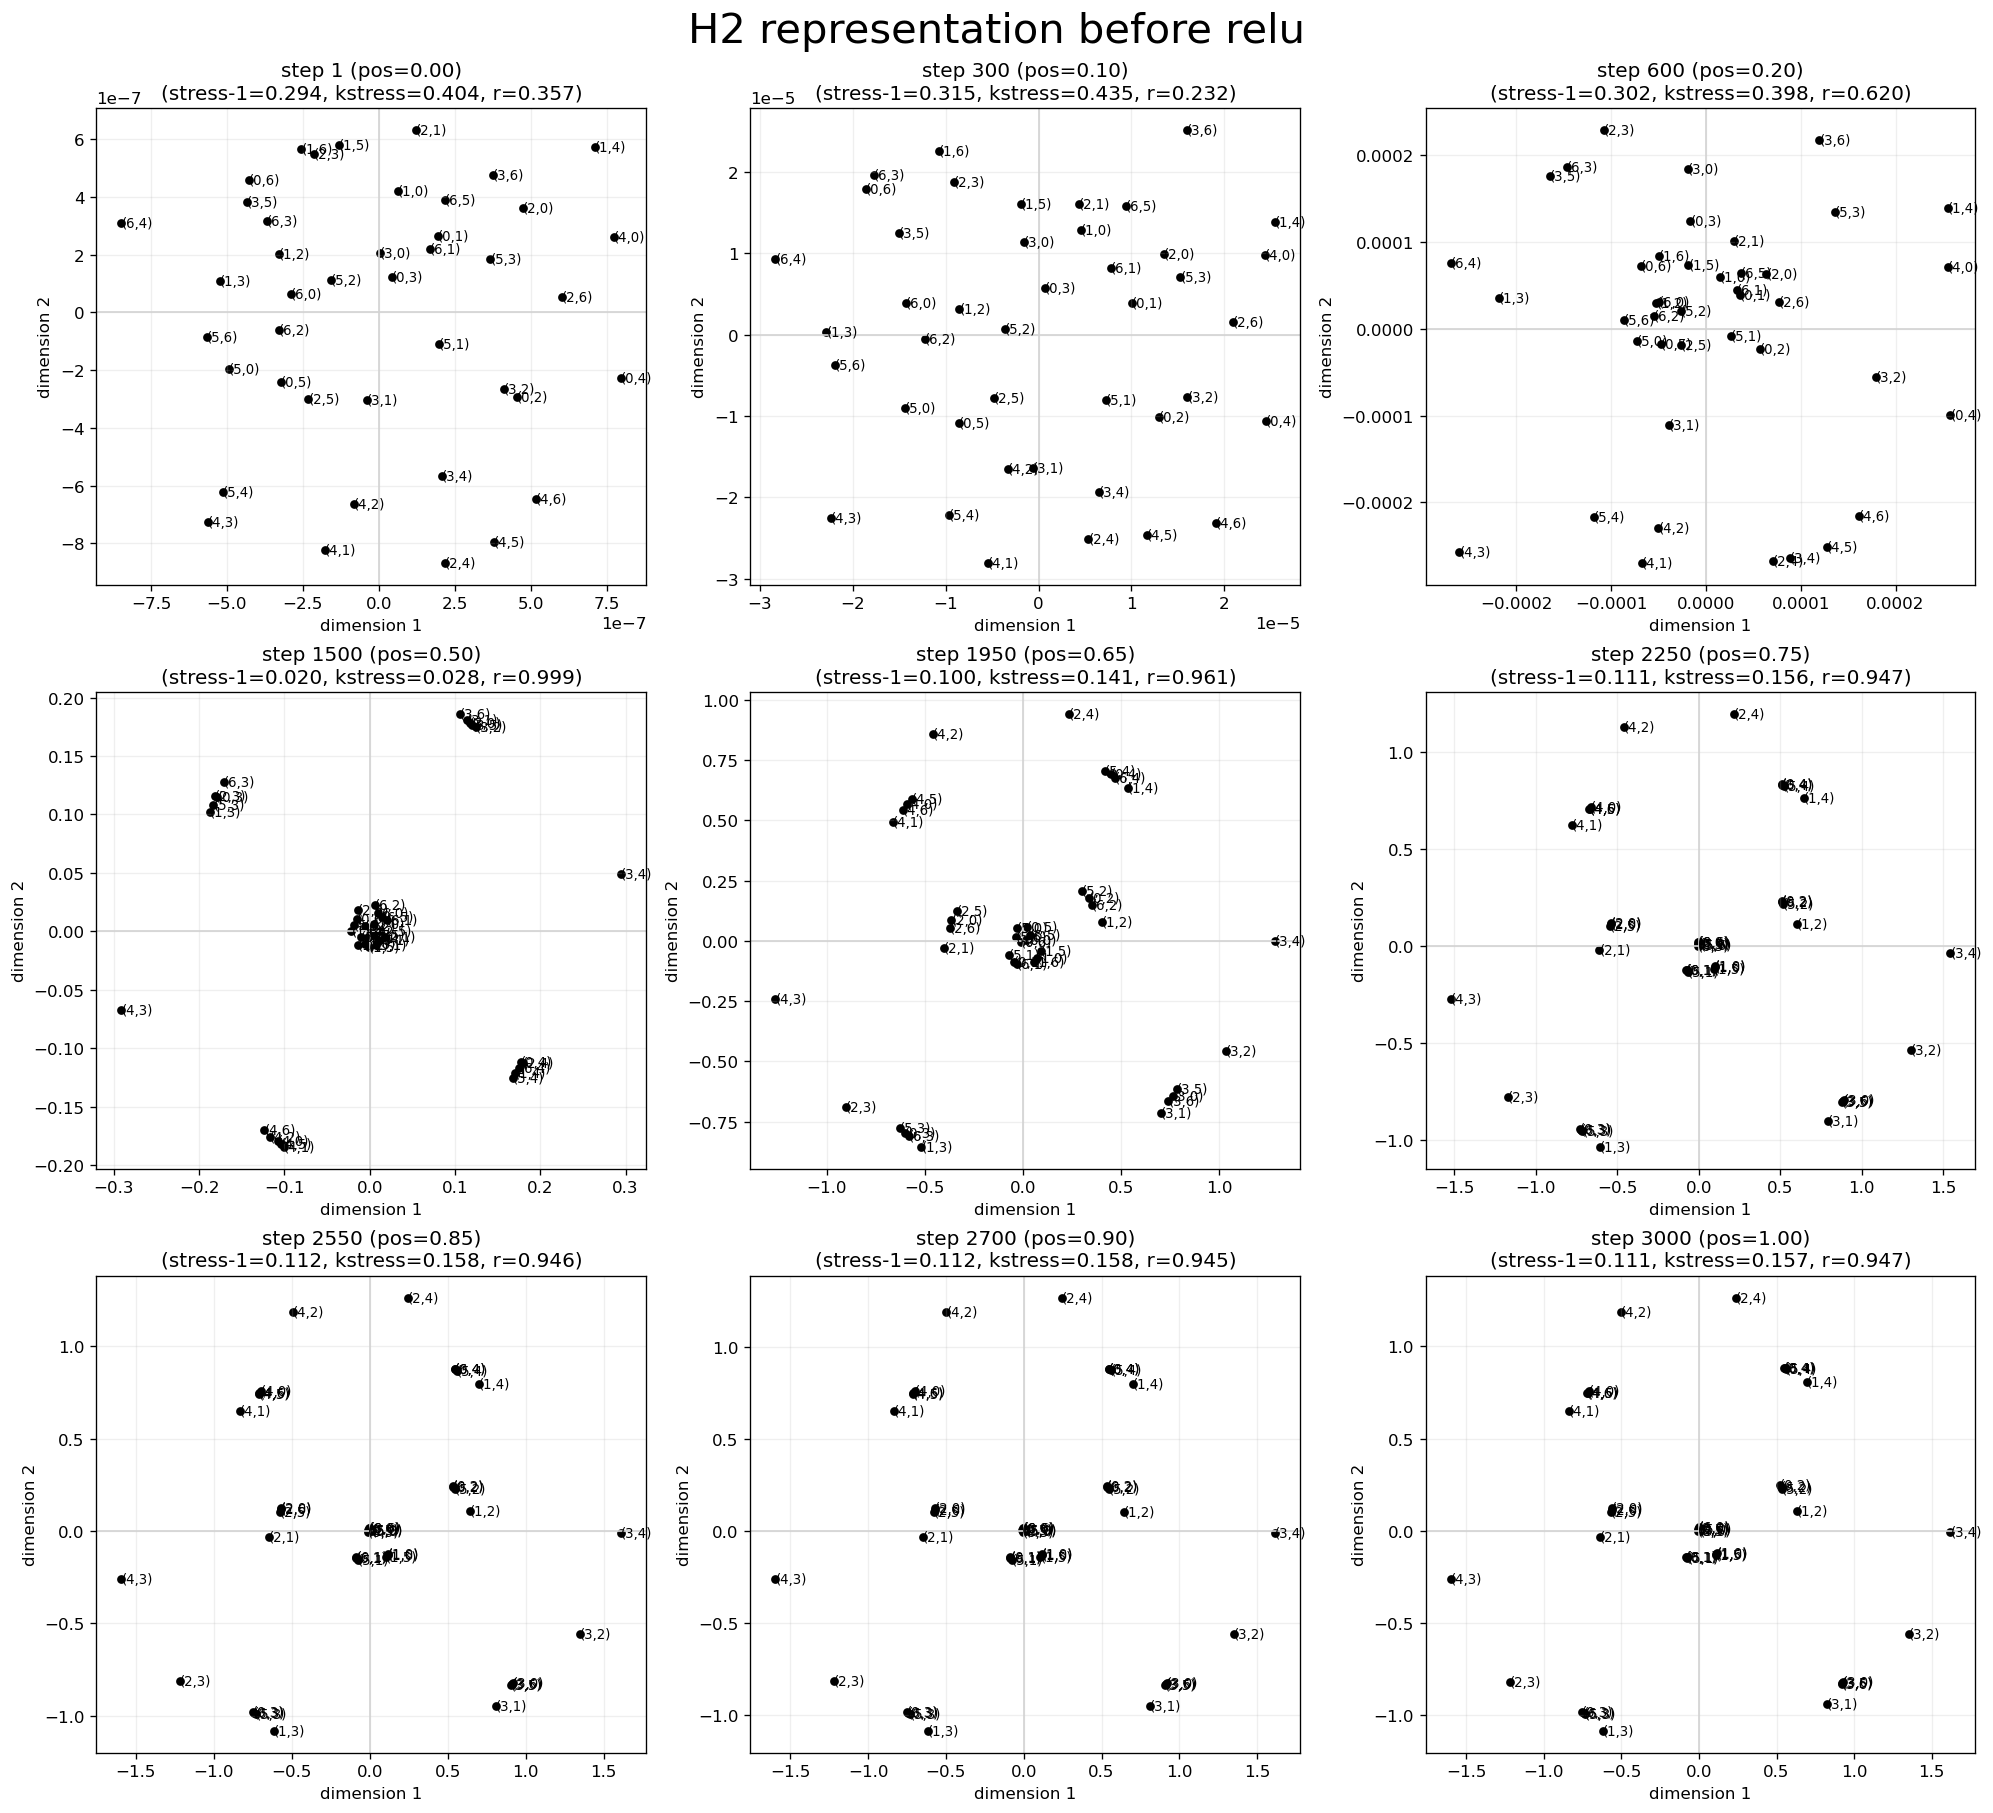

In [124]:
# MDS of all ordered pairs (h2, from CSV) at all requested steps, with Kruskal stress-1 and (raw) Kruskal stress
import numpy as np
import matplotlib.pyplot as plt
from sklearn import manifold
from sklearn.metrics import euclidean_distances
from scipy.stats import pearsonr
import pandas as pd

# Use CSV-loaded h2 data if available; else load from gz in this folder
if 'all_h2s' in globals():
    H2_avg = all_h2s  # shape: (time_steps, items_n, h2_size) already averaged across seeds
else:
    def load_h2_mean_from_csv_gz(csv_gz_path):
        df = pd.read_csv(csv_gz_path, compression='gzip')
        seed_cols = [c for c in df.columns if c.startswith('seed_')]
        # Mean across seeds per (time_step, item, unit)
        grouped = df.groupby(['time_step', 'item', 'unit'])[seed_cols].mean()
        mean_series = grouped.mean(axis=1)  # average across seed columns
        time_steps = int(df['time_step'].max()) + 1
        items_n_inferred = int(df['item'].max()) + 1
        units = int(df['unit'].max()) + 1
        arr = np.zeros((time_steps, items_n_inferred, units))
        for (t, i, u), val in mean_series.items():
            arr[int(t), int(i), int(u)] = float(val)
        return arr
    # Try local gz produced earlier in this notebook
    H2_avg = load_h2_mean_from_csv_gz('conjunctive_lazy_rich_h2s.csv.gz')

time_steps, items_n_inferred, h2_size = H2_avg.shape

# Positions to display, used previously
positions = [0.00, 0.10, 0.20, 0.50, 0.65, 0.75, 0.85, 0.90, 1.00]
steps_after_training = time_steps - 1
step_idxs = [max(0, int(p * steps_after_training)) for p in positions]

# Utility to build all concatenated ordered pairs (i!=j)
def build_pairs(X_items):
    vecs, labels, pairs = [], [], []
    for i in range(items_n_inferred):
        for j in range(items_n_inferred):
            if i == j:
                continue
            v = np.concatenate([X_items[i], X_items[j]], axis=0)
            vecs.append(v)
            labels.append(f"({i},{j})")
            pairs.append((i, j))
    V = np.asarray(vecs)
    # mean-center features in each matrix for each step, stabilizes MDS
    V = V - V.mean(axis=0, keepdims=True)
    return V, labels, pairs

# Fit 2D metric MDS on each distance matrix; report Kruskal stress-1 and Kruskal stress (raw)
def fit_mds_with_stress(D, seed):
    mds = manifold.MDS(
        n_components=2,
        dissimilarity='precomputed',
        random_state=seed,
        n_init=4,
        normalized_stress='auto',
    )
    fit_result = mds.fit(D)
    coords = fit_result.embedding_
    stress_raw = getattr(mds, 'stress_', None)
    denom = float(np.sum(D ** 2))
    # Kruskal's stress-1 as in sklearn docs: sqrt( sum((d_ij - d̂_ij)^2) / sum(d_ij^2) )
    stress1 = np.sqrt(stress_raw / denom) if (stress_raw is not None and denom > 0) else np.nan

    # Compute the reconstructed distances
    Dr = euclidean_distances(coords)
    # Use only upper triangle (excluding diagonal)
    orig = D[np.triu_indices_from(D, k=1)]
    rec = Dr[np.triu_indices_from(Dr, k=1)]
    # Kruskal's raw stress
    kruskal_stress = np.sqrt(np.sum((orig - rec) ** 2) / np.sum(orig ** 2)) if np.sum(orig ** 2) > 0 else np.nan

    # For reporting: also include Pearson r between dist matrices
    if len(orig) > 1:
        r, _ = pearsonr(orig, rec)
    else:
        r = np.nan

    return coords, stress1, kruskal_stress, r

seed = mds_seed if 'mds_seed' in globals() else 0

nsteps = len(step_idxs)
ncols = 3
nrows = int(np.ceil(nsteps / ncols))
fig, axs = plt.subplots(nrows, ncols, figsize=(5.5*ncols, 5*nrows), constrained_layout=True)

for pidx, (pos, step_idx) in enumerate(zip(positions, step_idxs)):
    V, labels, pairs = build_pairs(H2_avg[step_idx])
    D = euclidean_distances(V)
    coords, stress1, kst, r = fit_mds_with_stress(D, seed)
    r_ax = pidx // ncols
    c_ax = pidx % ncols
    ax = axs[r_ax, c_ax] if nrows > 1 else axs[c_ax]
    ax.scatter(coords[:, 0], coords[:, 1], s=18, color='k')
    for i, lab in enumerate(labels):
        ax.text(coords[i, 0], coords[i, 1], lab, fontsize=8, ha='left', va='center')
    ax.axhline(0, color='lightgray', linewidth=1)
    ax.axvline(0, color='lightgray', linewidth=1)
    ax.grid(True, alpha=0.2)
    ax.set_title(
        f"step {step_idx+1} (pos={pos:.2f})\n"
        f"(stress-1={stress1:.3f}, kstress={kst:.3f}, r={r:.3f})"
    )
    ax.set_xlabel('dimension 1')
    ax.set_ylabel('dimension 2')

# Remove any excess unused subplots
for k in range(nsteps, nrows*ncols):
    fig.delaxes(axs.flatten()[k])

fig.suptitle("H2 representation before relu", size = 25)
plt.show()


# H2 MDS with ReLU

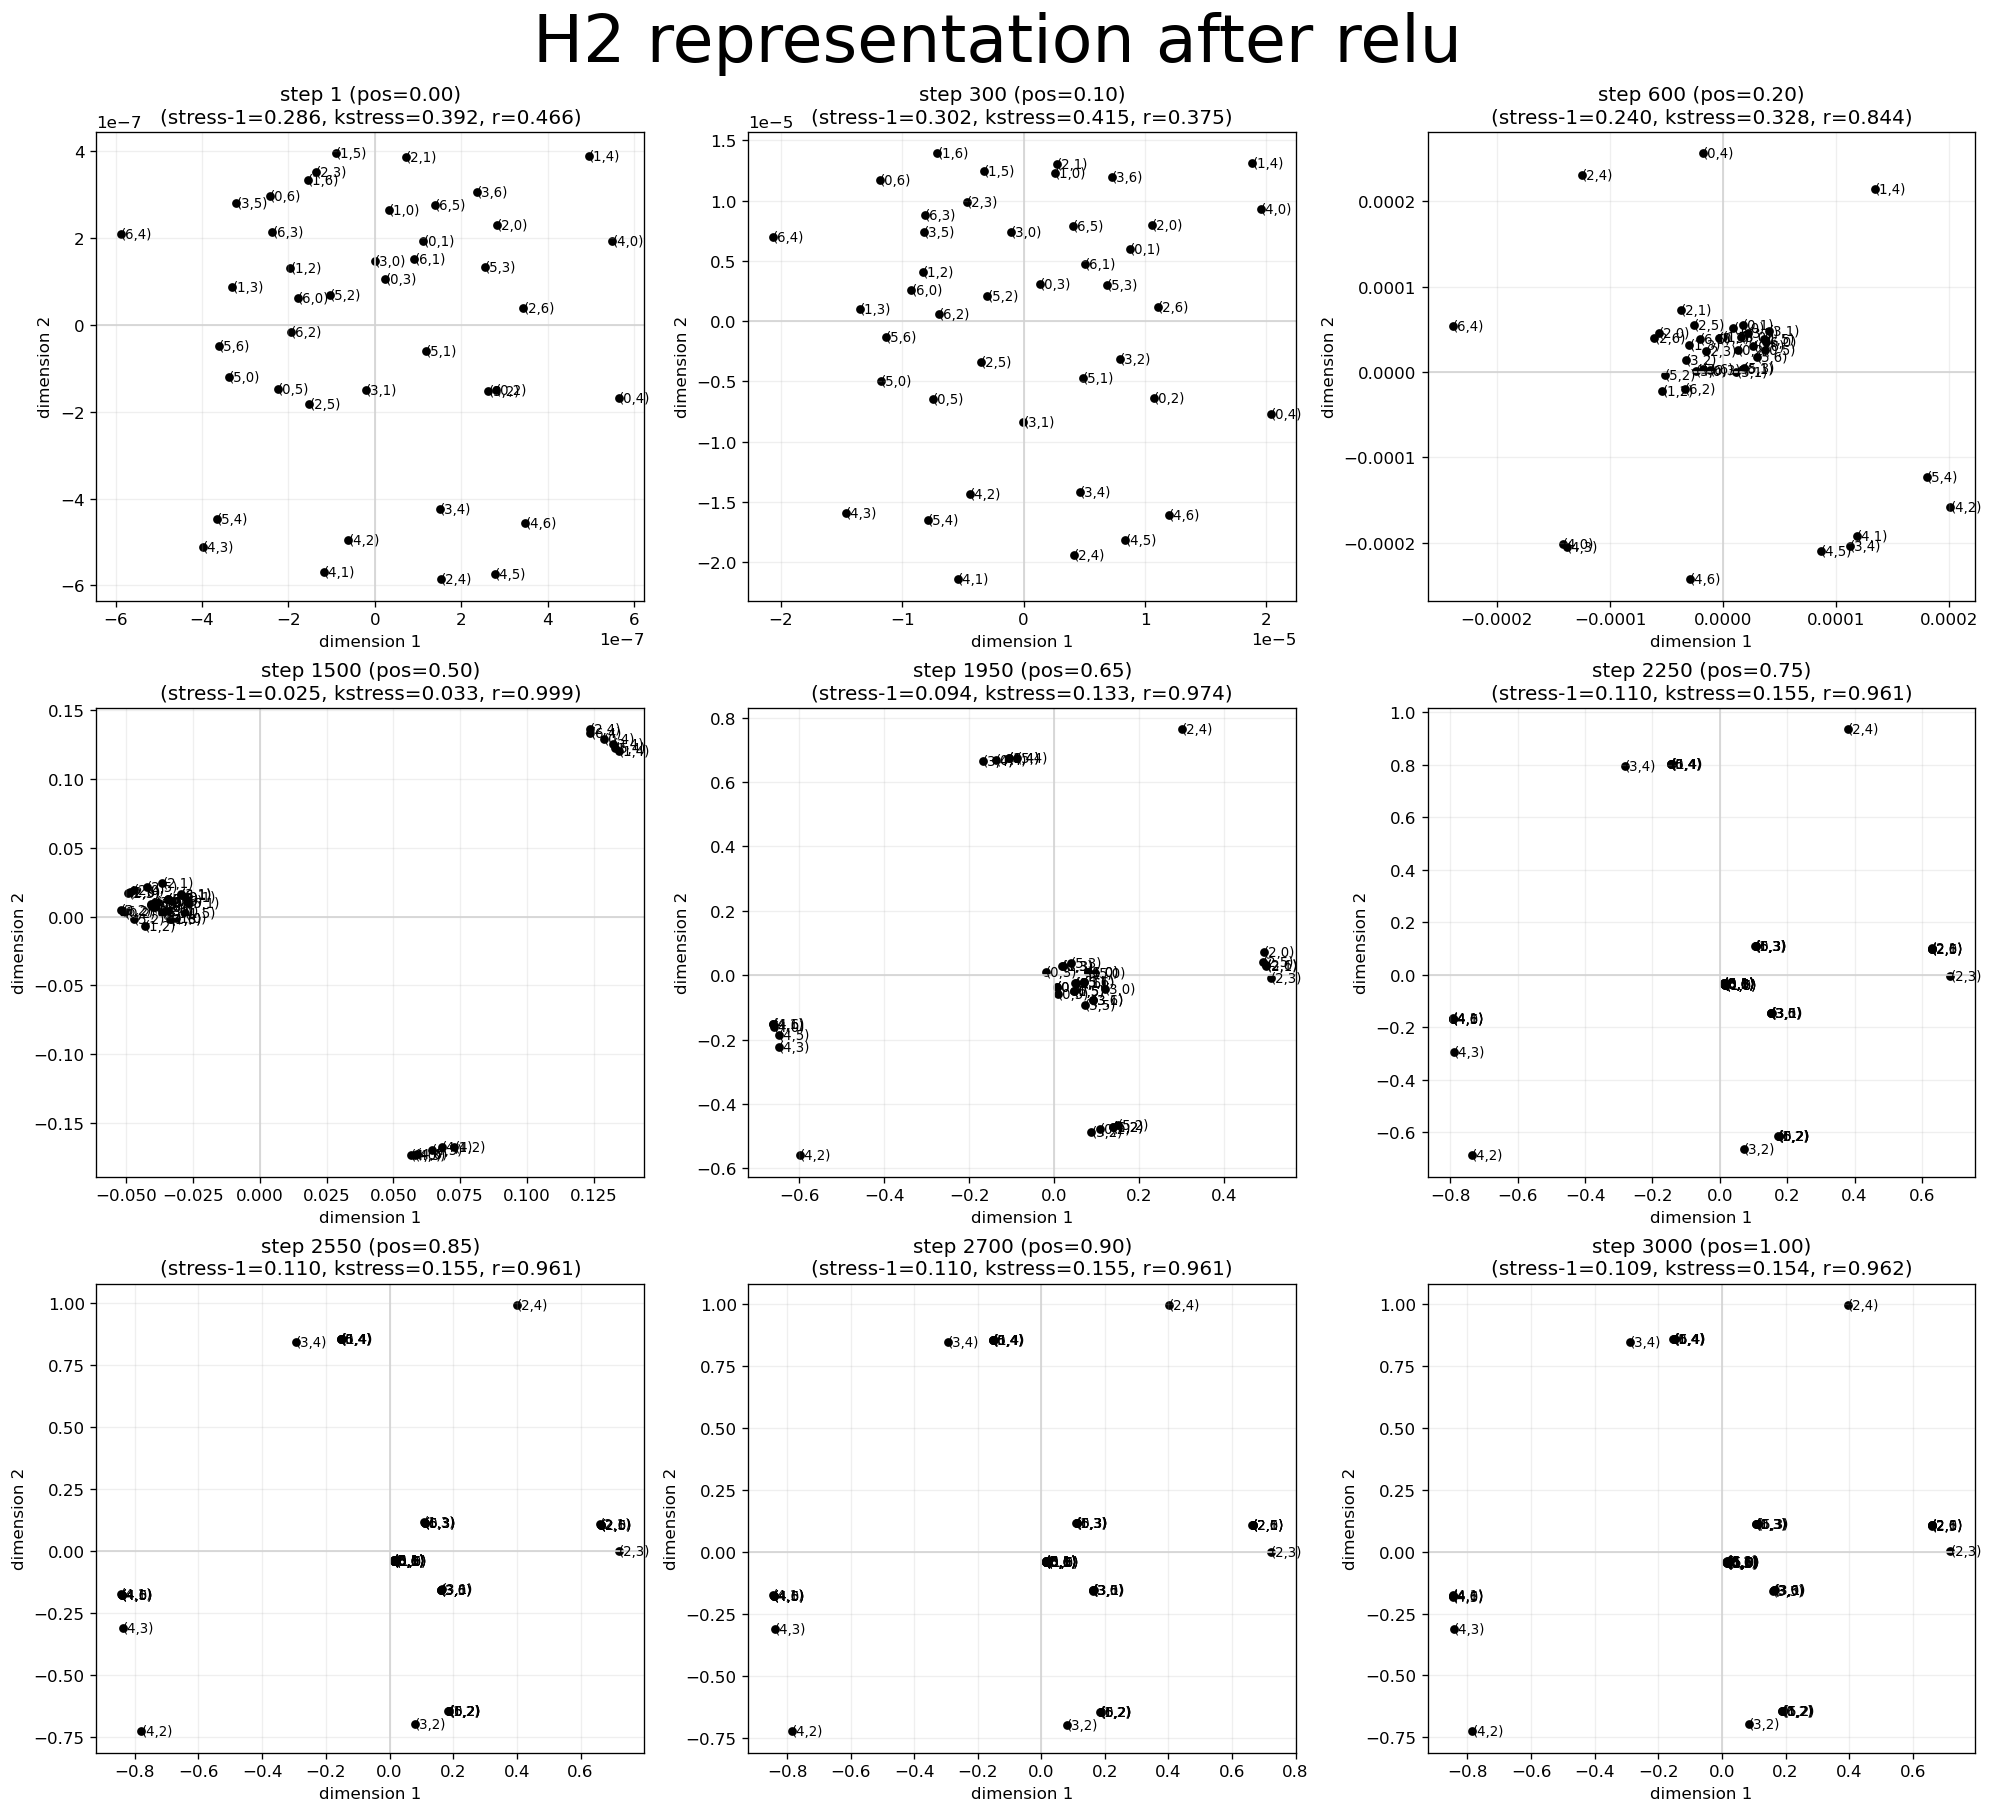

In [125]:
# MDS of all ordered pairs (h2, from CSV) at all requested steps, with Kruskal stress-1 and (raw) Kruskal stress
import numpy as np
import matplotlib.pyplot as plt
from sklearn import manifold
from sklearn.metrics import euclidean_distances
from scipy.stats import pearsonr
import pandas as pd

# Use CSV-loaded h2 data if available; else load from gz in this folder
if 'all_h2s' in globals():
    #with relu
    H2_avg_relu = np.maximum(0, all_h2s)  # shape: (time_steps, items_n, h2_size) already averaged across seeds
else:
    def load_h2_mean_from_csv_gz(csv_gz_path):
        df = pd.read_csv(csv_gz_path, compression='gzip')
        seed_cols = [c for c in df.columns if c.startswith('seed_')]
        # Mean across seeds per (time_step, item, unit)
        grouped = df.groupby(['time_step', 'item', 'unit'])[seed_cols].mean()
        mean_series = grouped.mean(axis=1)  # average across seed columns
        time_steps = int(df['time_step'].max()) + 1
        items_n_inferred = int(df['item'].max()) + 1
        units = int(df['unit'].max()) + 1
        arr = np.zeros((time_steps, items_n_inferred, units))
        for (t, i, u), val in mean_series.items():
            arr[int(t), int(i), int(u)] = float(val)
        return arr
    # Try local gz produced earlier in this notebook
    H2_avg_relu = np.maximum(0, load_h2_mean_from_csv_gz('conjunctive_lazy_rich_h2s.csv.gz'))

time_steps, items_n_inferred, h2_size = H2_avg.shape

# Positions to display, used previously
positions = [0.00, 0.10, 0.20, 0.50, 0.65, 0.75, 0.85, 0.90, 1.00]
steps_after_training = time_steps - 1
step_idxs = [max(0, int(p * steps_after_training)) for p in positions]

# Utility to build all concatenated ordered pairs (i!=j)
def build_pairs(X_items):
    vecs, labels, pairs = [], [], []
    for i in range(items_n_inferred):
        for j in range(items_n_inferred):
            if i == j:
                continue
            v = np.concatenate([X_items[i], X_items[j]], axis=0)
            vecs.append(v)
            labels.append(f"({i},{j})")
            pairs.append((i, j))
    V = np.asarray(vecs)
    # mean-center features in each matrix for each step, stabilizes MDS
    V = V - V.mean(axis=0, keepdims=True)
    return V, labels, pairs

# Fit 2D metric MDS on each distance matrix; report Kruskal stress-1 and Kruskal stress (raw)
def fit_mds_with_stress(D, seed):
    mds = manifold.MDS(
        n_components=2,
        dissimilarity='precomputed',
        random_state=seed,
        n_init=4,
        normalized_stress='auto',
    )
    fit_result = mds.fit(D)
    coords = fit_result.embedding_
    stress_raw = getattr(mds, 'stress_', None)
    denom = float(np.sum(D ** 2))
    # Kruskal's stress-1 as in sklearn docs: sqrt( sum((d_ij - d̂_ij)^2) / sum(d_ij^2) )
    stress1 = np.sqrt(stress_raw / denom) if (stress_raw is not None and denom > 0) else np.nan

    # Compute the reconstructed distances
    Dr = euclidean_distances(coords)
    # Use only upper triangle (excluding diagonal)
    orig = D[np.triu_indices_from(D, k=1)]
    rec = Dr[np.triu_indices_from(Dr, k=1)]
    # Kruskal's raw stress
    kruskal_stress = np.sqrt(np.sum((orig - rec) ** 2) / np.sum(orig ** 2)) if np.sum(orig ** 2) > 0 else np.nan

    # For reporting: also include Pearson r between dist matrices
    if len(orig) > 1:
        r, _ = pearsonr(orig, rec)
    else:
        r = np.nan

    return coords, stress1, kruskal_stress, r

seed = mds_seed if 'mds_seed' in globals() else 0

nsteps = len(step_idxs)
ncols = 3
nrows = int(np.ceil(nsteps / ncols))
fig, axs = plt.subplots(nrows, ncols, figsize=(5.5*ncols, 5*nrows), constrained_layout=True)

for pidx, (pos, step_idx) in enumerate(zip(positions, step_idxs)):
    V, labels, pairs = build_pairs(H2_avg_relu[step_idx])
    D = euclidean_distances(V)
    coords, stress1, kst, r = fit_mds_with_stress(D, seed)
    r_ax = pidx // ncols
    c_ax = pidx % ncols
    ax = axs[r_ax, c_ax] if nrows > 1 else axs[c_ax]
    ax.scatter(coords[:, 0], coords[:, 1], s=18, color='k')
    for i, lab in enumerate(labels):
        ax.text(coords[i, 0], coords[i, 1], lab, fontsize=8, ha='left', va='center')
    ax.axhline(0, color='lightgray', linewidth=1)
    ax.axvline(0, color='lightgray', linewidth=1)
    ax.grid(True, alpha=0.2)
    ax.set_title(
        f"step {step_idx+1} (pos={pos:.2f})\n"
        f"(stress-1={stress1:.3f}, kstress={kst:.3f}, r={r:.3f})"
    )
    ax.set_xlabel('dimension 1')
    ax.set_ylabel('dimension 2')

# Remove any excess unused subplots
for k in range(nsteps, nrows*ncols):
    fig.delaxes(axs.flatten()[k])

fig.suptitle("H2 representation after relu", size = 40)
plt.show()


In [127]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import manifold
from sklearn.metrics import euclidean_distances

def plot_h2_mds_filtered_grids_labeled(
    H2_avg,
    positions,
    categories,
    cat_colors,
    include_context=True,
    dpi=120,
    max_labels_per_panel=150,
    seed=0,
):
    """
    H2_avg: array (time_steps, items_n, h2_units)
    positions: list of fractions in [0,1] (len=9 for a 3x3 grid)
    categories: dict name -> list of ordered pairs [(i,j), ...] (both orders included)
    cat_colors: dict name -> color
    include_context: plot all pairs in gray behind the selection
    dpi: figure dpi cap to prevent huge canvases
    max_labels_per_panel: cap labels to avoid layout blow-ups
    """
    time_steps, items_n, _ = H2_avg.shape
    step_idxs = [max(0, int(p * (time_steps - 1))) for p in positions]

    def build_pairs_h2(X_items):
        vecs, labels, pairs = [], [], []
        n = X_items.shape[0]
        for i in range(n):
            for j in range(n):
                if i == j:
                    continue
                vecs.append(np.concatenate([X_items[i], X_items[j]], axis=0))
                labels.append(f"({i},{j})")
                pairs.append((i, j))
        V = np.asarray(vecs, dtype=float)
        V = np.nan_to_num(V, nan=0.0, posinf=0.0, neginf=0.0)
        V = V - V.mean(axis=0, keepdims=True)
        return V, labels, pairs

    def fit_2d_from_hd_dist(V, seed=0):
        D = euclidean_distances(V)
        mds = manifold.MDS(
            n_components=2,
            dissimilarity='precomputed',
            random_state=seed,
            n_init=4,
            normalized_stress='auto',
        )
        return mds.fit(D).embedding_

    for cat_name, sel_pairs in categories.items():
        fig, axs = plt.subplots(3, 3, figsize=(11, 10), dpi=dpi, constrained_layout=False)
        fig.patch.set_facecolor('white')

        for pidx, (pos, step_idx) in enumerate(zip(positions, step_idxs)):
            r, c = divmod(pidx, 3)
            ax = axs[r, c]

            X_items = np.nan_to_num(H2_avg[step_idx], nan=0.0, posinf=0.0, neginf=0.0)
            V, labels, all_pairs = build_pairs_h2(X_items)
            coords = fit_2d_from_hd_dist(V, seed=seed)

            if include_context:
                ax.scatter(coords[:, 0], coords[:, 1], s=8, color='lightgray', alpha=0.25, zorder=1)

            sel_set = set(sel_pairs)
            sel_idxs = [k for k, pij in enumerate(all_pairs) if pij in sel_set]

            if sel_idxs:
                # Limit labels to avoid massive layout expansion
                if len(sel_idxs) > max_labels_per_panel:
                    # deterministic sub-sample
                    sel_idxs = np.unique(np.linspace(0, len(sel_idxs) - 1, max_labels_per_panel, dtype=int)).tolist()

                xy = coords[sel_idxs]
                ax.scatter(xy[:, 0], xy[:, 1], s=22, color=cat_colors.get(cat_name, 'C0'), alpha=0.95, zorder=2)

                # Small offset relative to axis span to reduce overlap
                xspan = (xy[:, 0].max() - xy[:, 0].min()) if xy.size else 1.0
                yspan = (xy[:, 1].max() - xy[:, 1].min()) if xy.size else 1.0
                dx, dy = 0.01 * xspan, 0.01 * yspan

                for idx in sel_idxs:
                    x, y = coords[idx]
                    lab = labels[idx]
                    ax.text(
                        x + dx, y + dy, lab, fontsize=7,
                        color=cat_colors.get(cat_name, 'C0'),
                        bbox=dict(facecolor='white', alpha=0.6, edgecolor='none', pad=0.2),
                        clip_on=True, zorder=3
                    )

            ax.axhline(0, color='lightgray', linewidth=1)
            ax.axvline(0, color='lightgray', linewidth=1)
            ax.grid(True, alpha=0.2)
            ax.set_title(f"h2 — {cat_name}\nstep {step_idx+1} (pos={pos:.2f})", fontsize=10)
            ax.set_xlabel('dimension 1'); ax.set_ylabel('dimension 2')

        # Use a compact layout (avoid constrained_layout to prevent huge canvas)
        fig.tight_layout()
        plt.show()

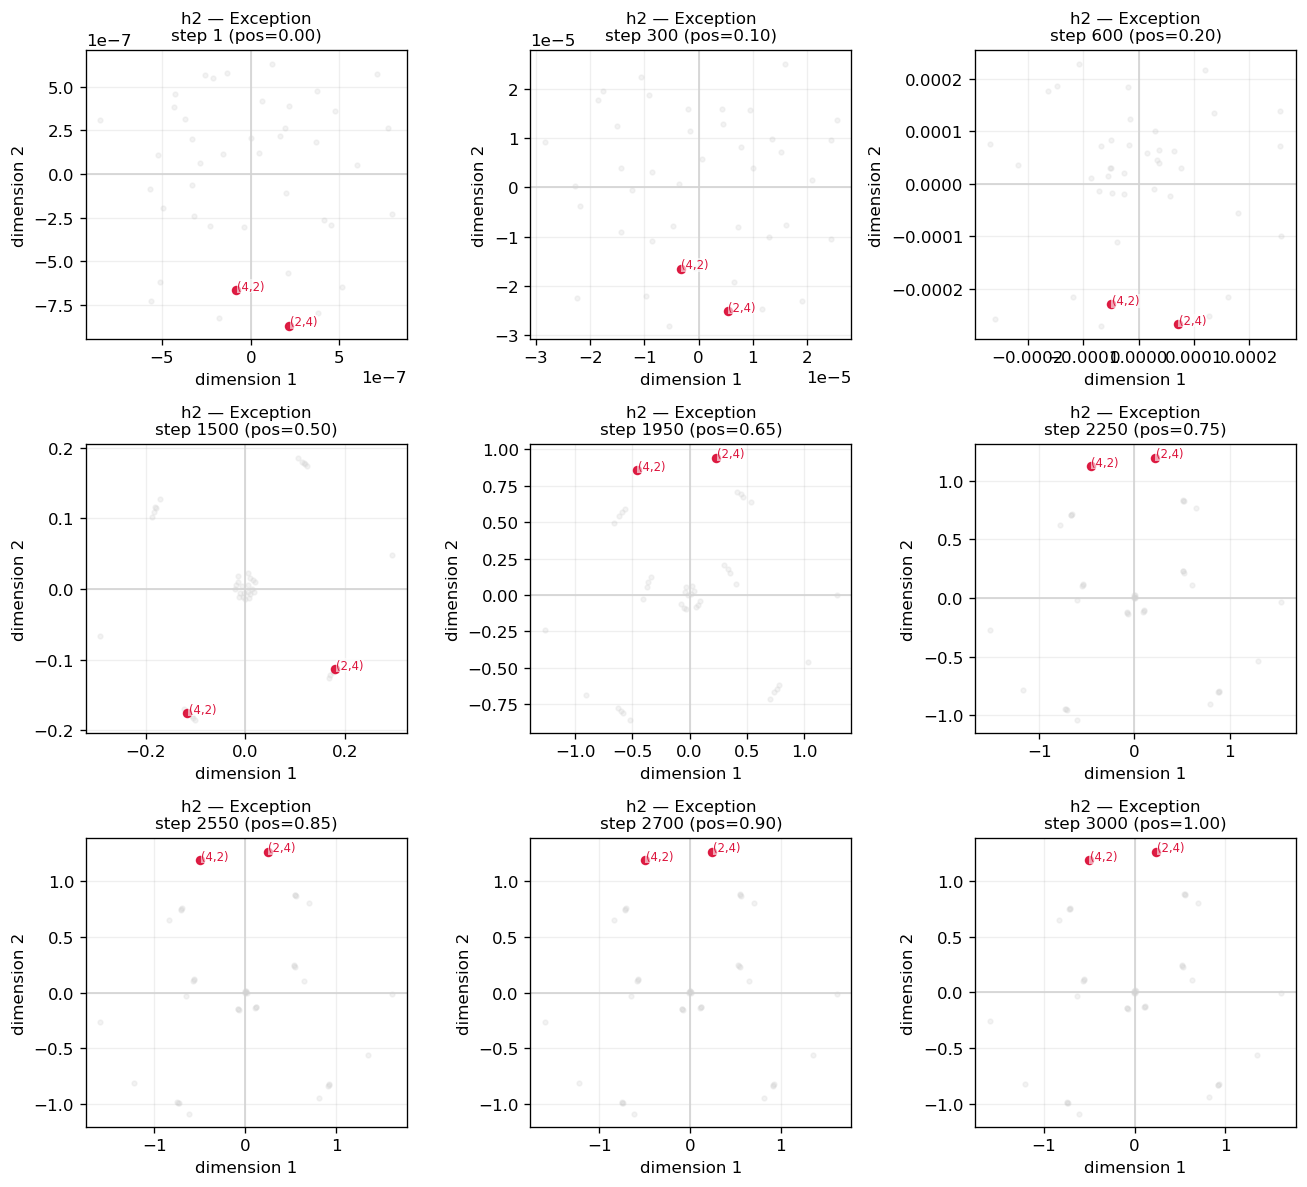

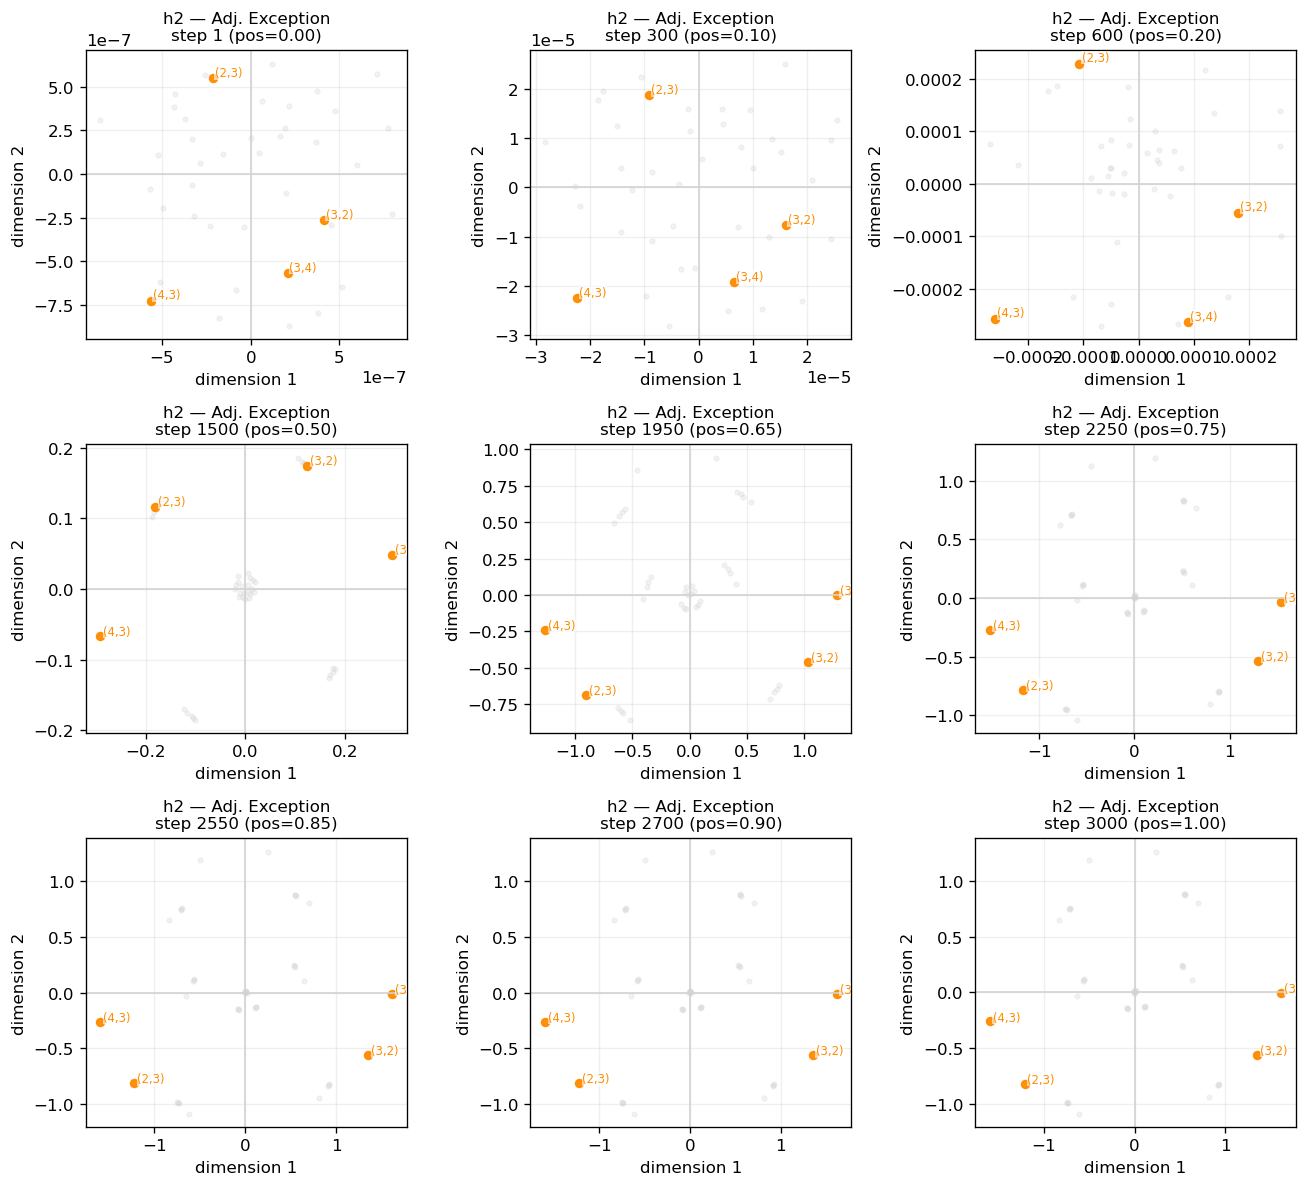

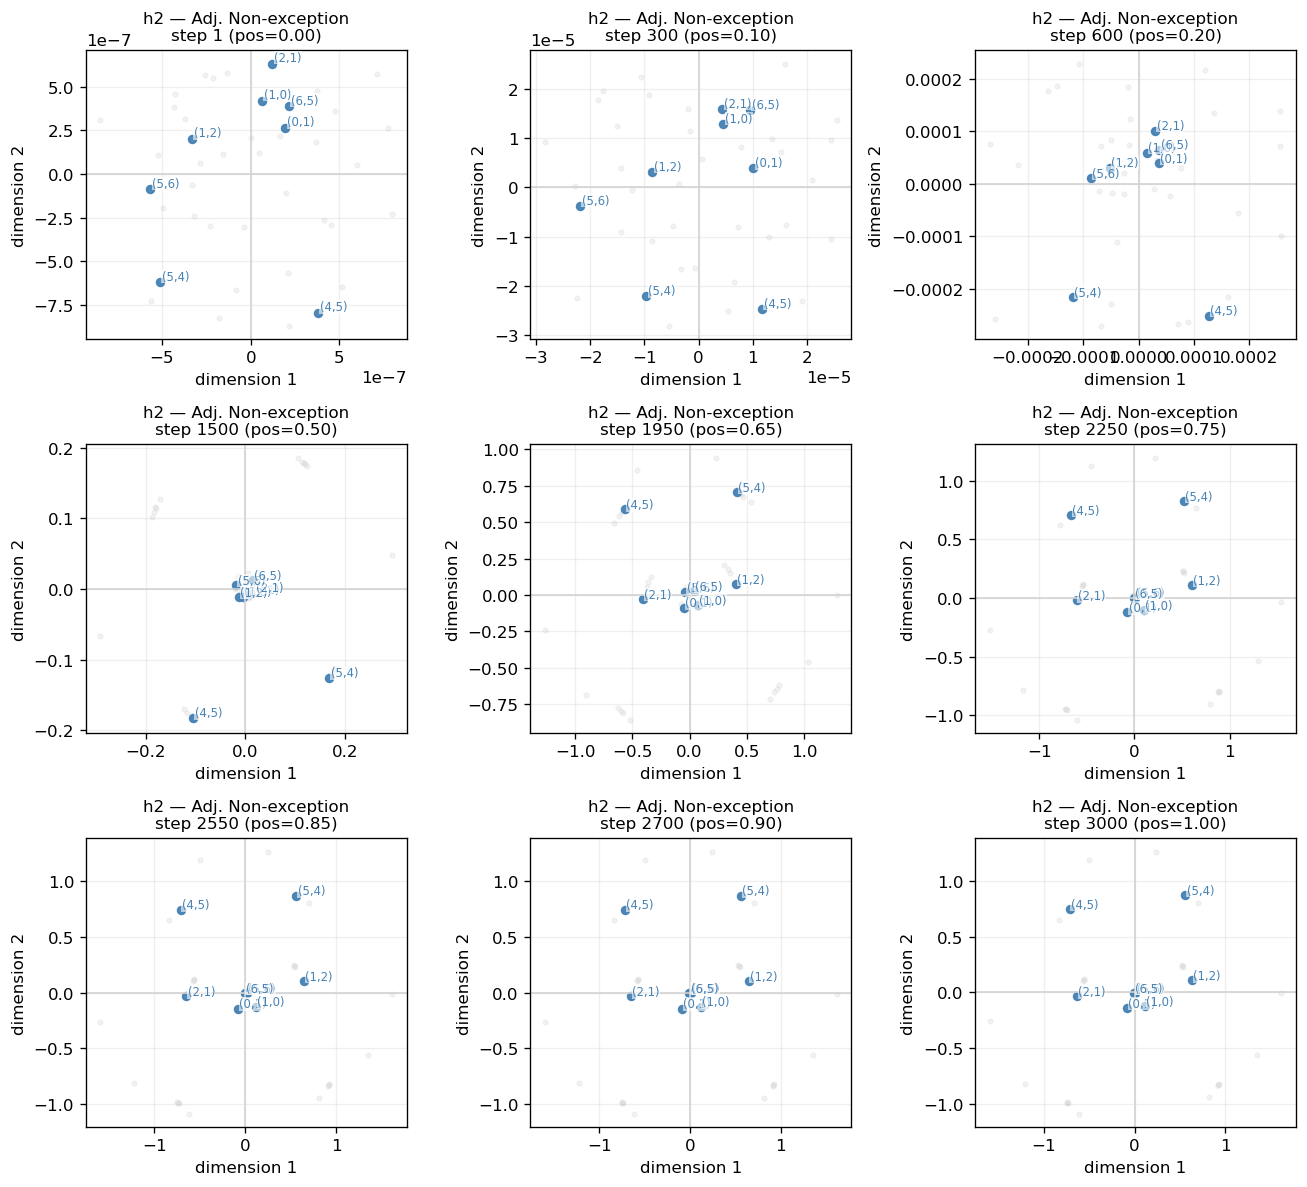

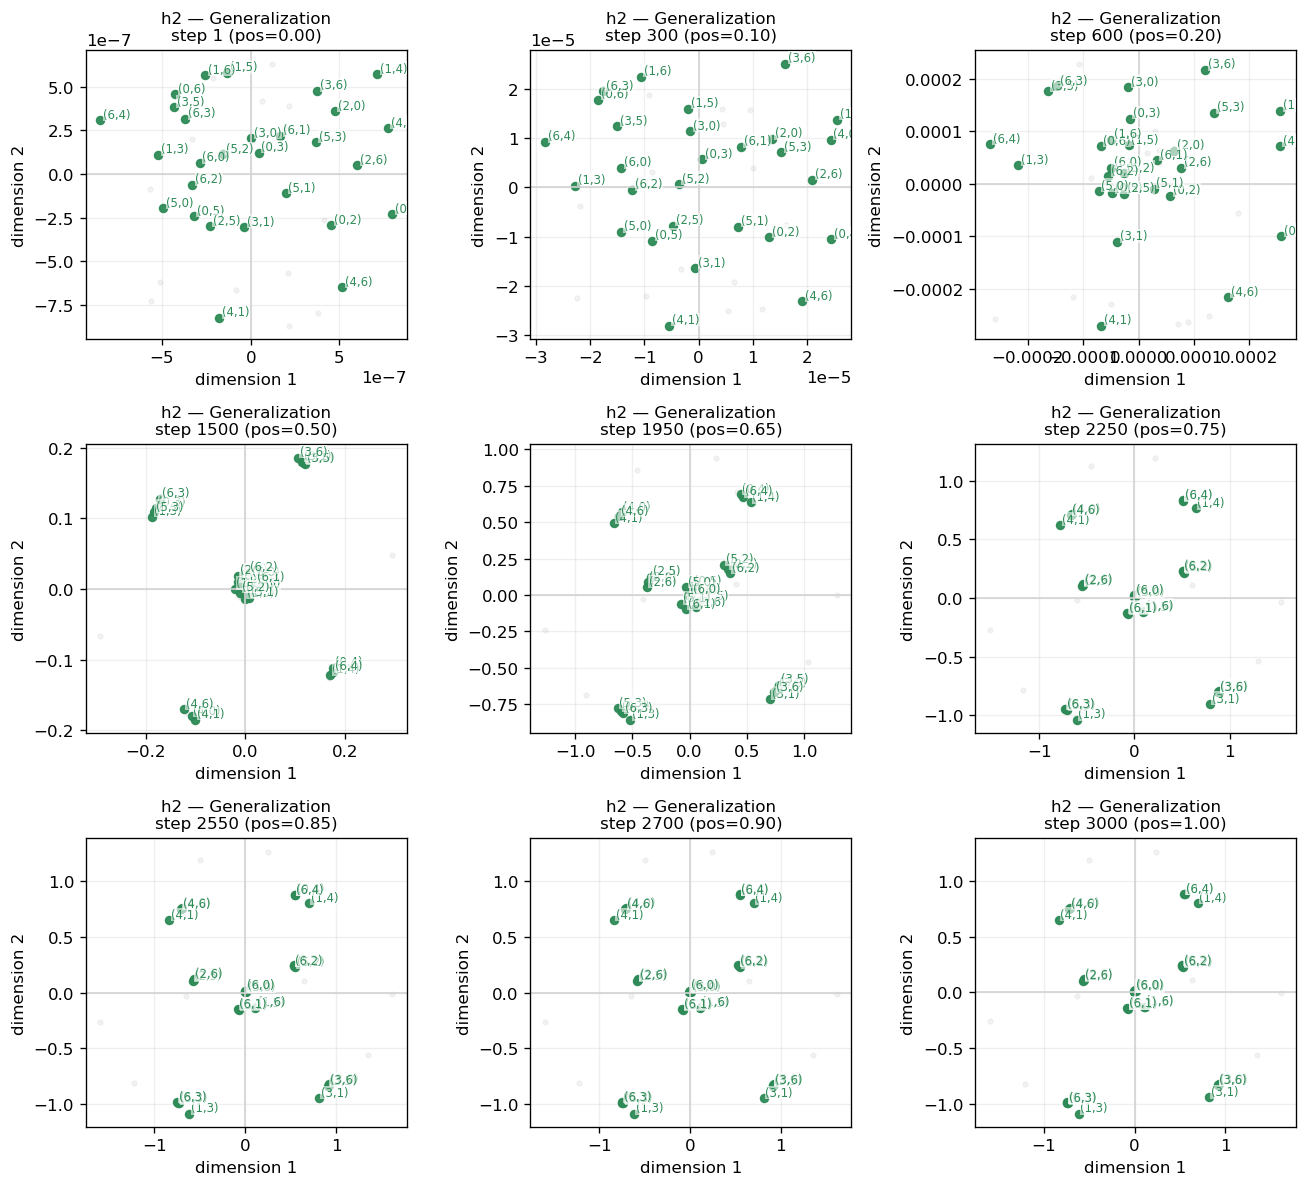

In [128]:
positions = [0.00, 0.10, 0.20, 0.50, 0.65, 0.75, 0.85, 0.90, 1.00]
plot_h2_mds_filtered_grids_labeled(
    H2_avg,
    positions=positions,
    categories={
        "Exception": exception_pair,
        "Adj. Exception": adjacent_exception_pairs,
        "Adj. Non-exception": adjacent_nonexception_pairs,
        "Generalization": generalization_pairs,
    },
    cat_colors={
        "Exception": "crimson",
        "Adj. Exception": "darkorange",
        "Adj. Non-exception": "steelblue",
        "Generalization": "seagreen",
    },
    include_context=True,
    dpi=120,
    max_labels_per_panel=120,  # lower this if labels still overflow
    seed=0,
)

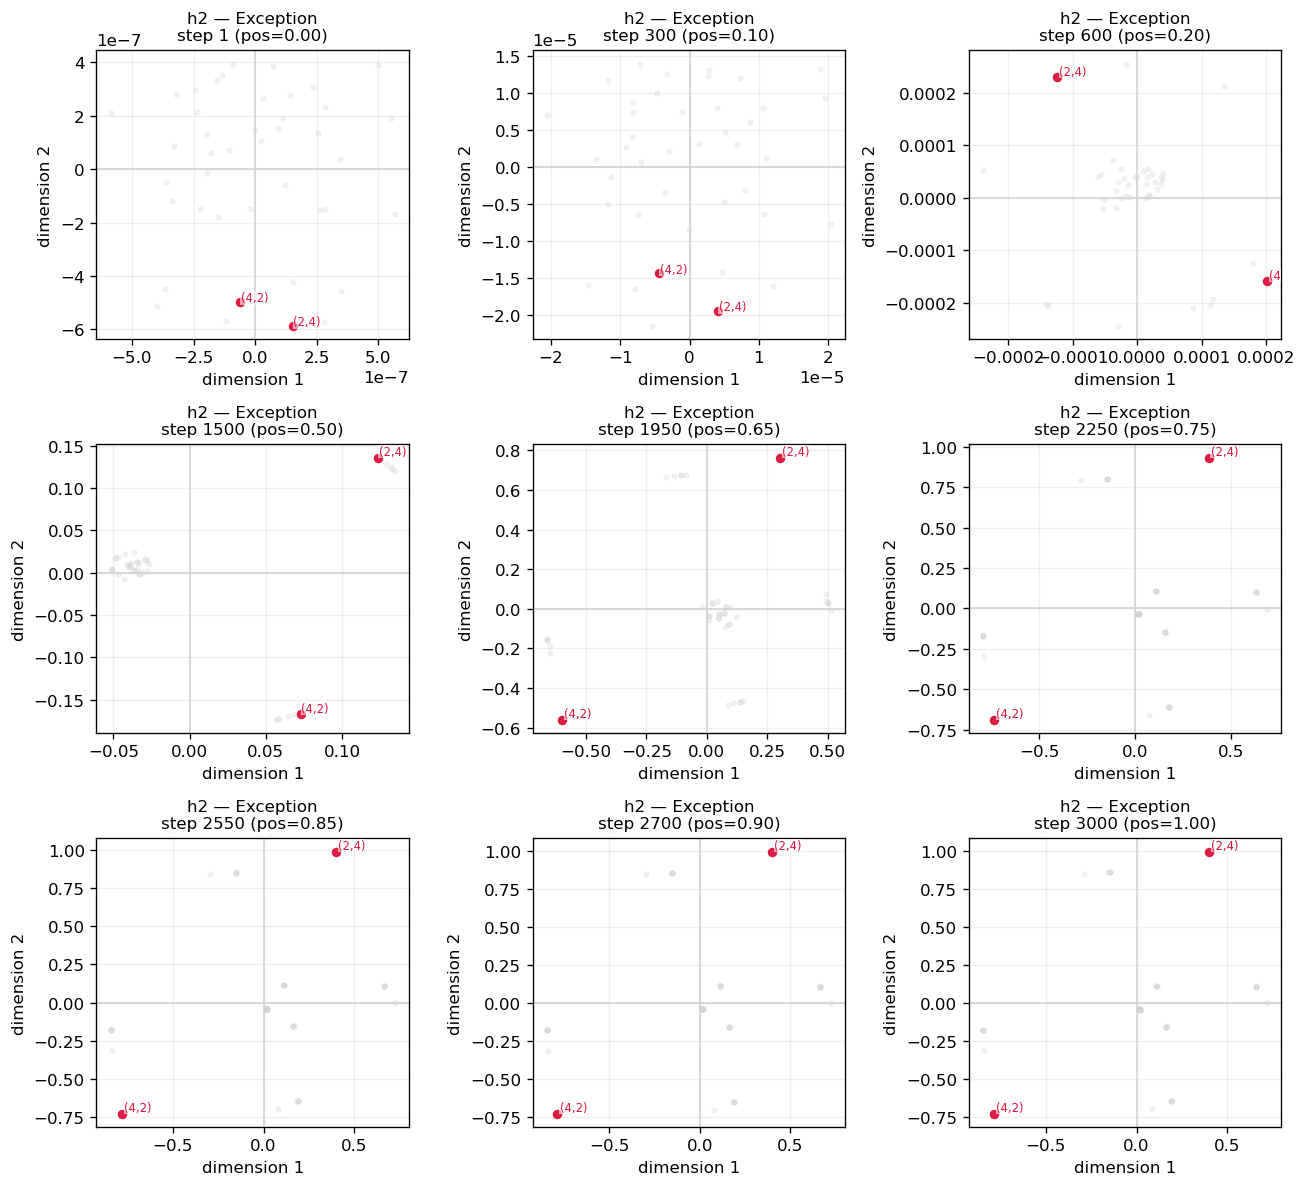

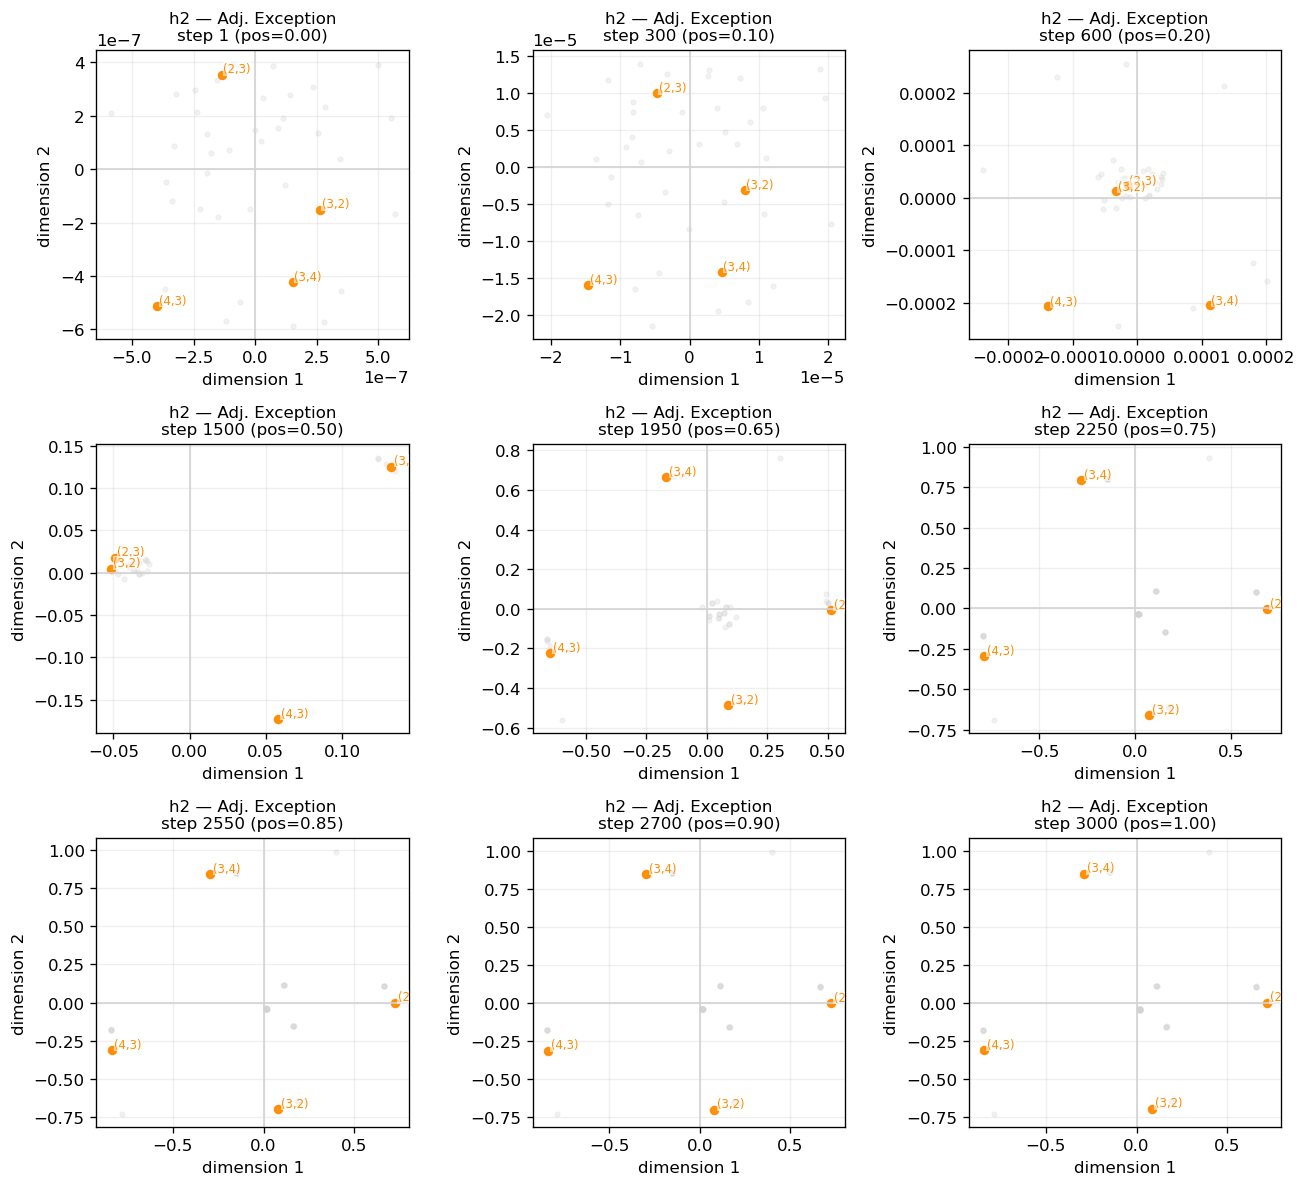

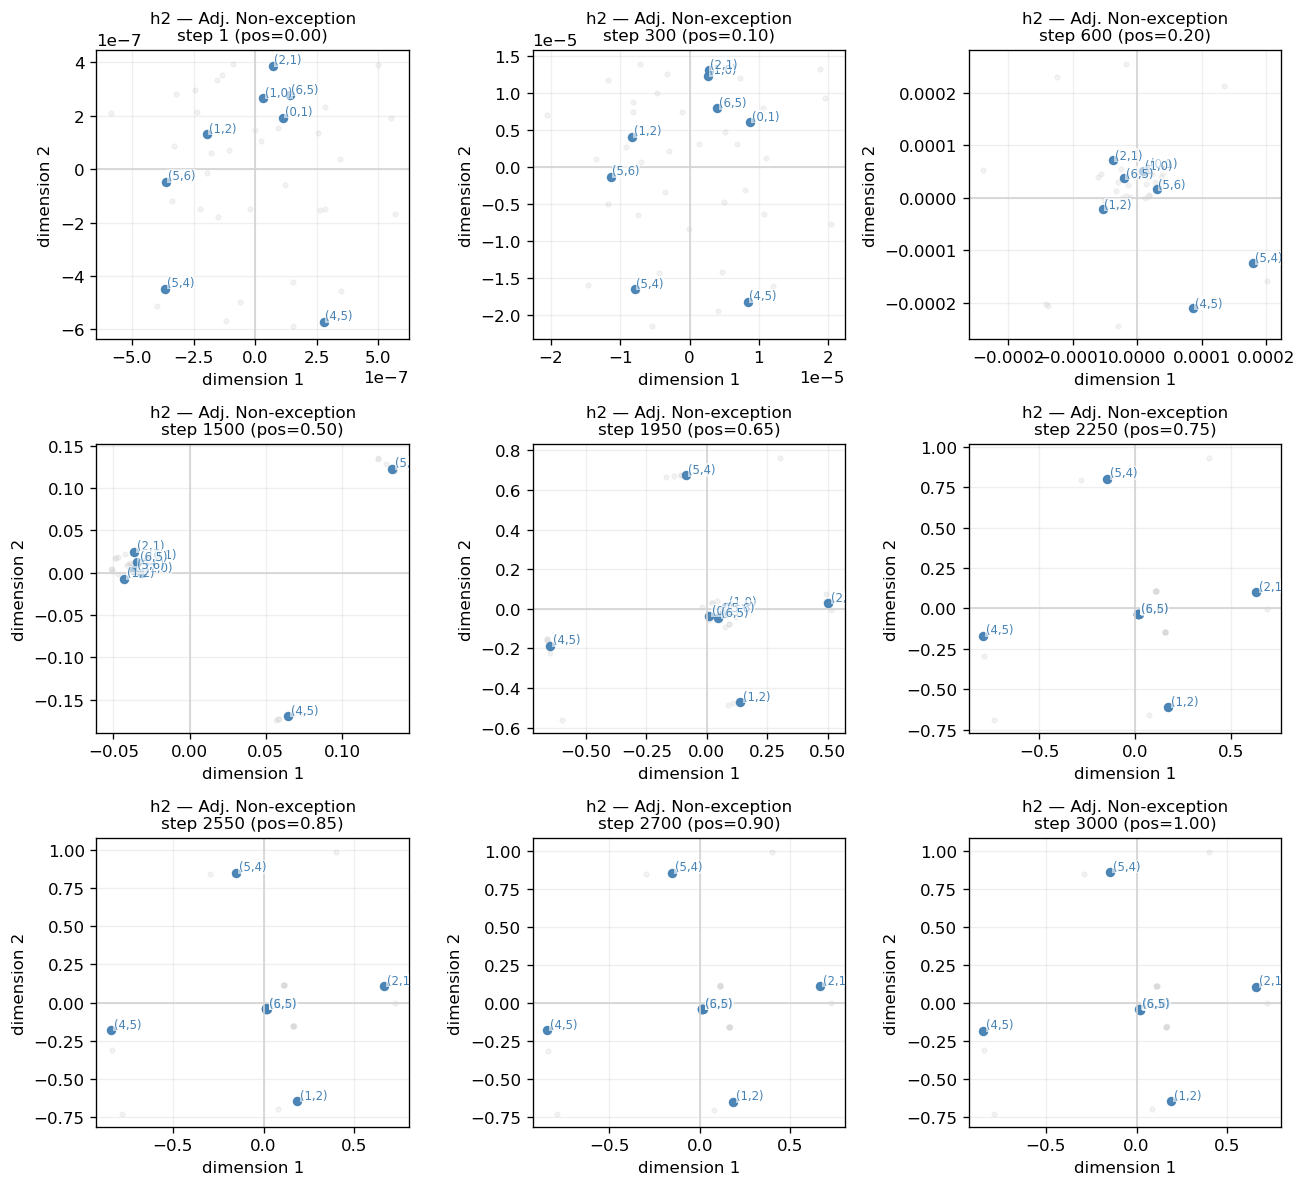

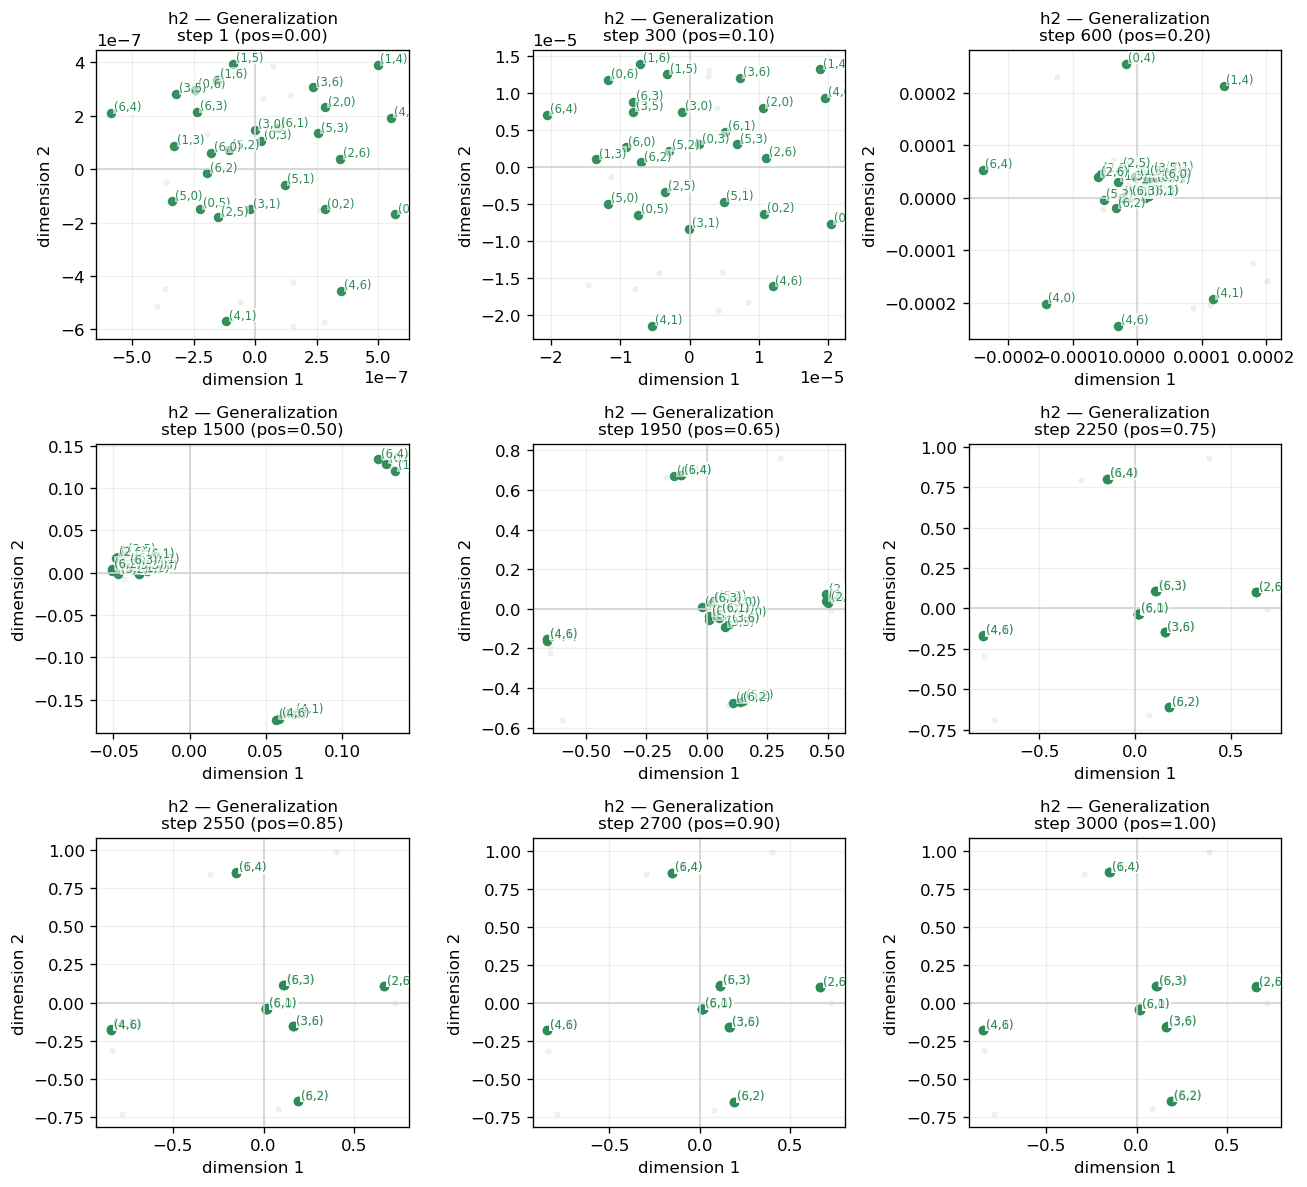

In [137]:
positions = [0.00, 0.10, 0.20, 0.50, 0.65, 0.75, 0.85, 0.90, 1.00]
plot_h2_mds_filtered_grids_labeled(
    H2_avg_relu,
    positions=positions,
    categories={
        "Exception": exception_pair,
        "Adj. Exception": adjacent_exception_pairs,
        "Adj. Non-exception": adjacent_nonexception_pairs,
        "Generalization": generalization_pairs,
    },
    cat_colors={
        "Exception": "crimson",
        "Adj. Exception": "darkorange",
        "Adj. Non-exception": "steelblue",
        "Generalization": "seagreen",
    },
    include_context=True,
    dpi=120,
    max_labels_per_panel=120,  # lower this if labels still overflow
    seed=0,
)

# Select a pair that you'd like

In [132]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import manifold
from sklearn.metrics import euclidean_distances

def plot_pair_mds_grid(
    layer_avg,                # shape: (time_steps, items_n, feat_dim) e.g., H2_avg or H1_avg
    pair,                     # tuple (i, j)
    positions=None,           # list of 9 fractions in [0,1]
    include_reverse=True,     # also highlight (j, i)
    include_context=True,     # show all pairs in light gray
    color="crimson",          # highlight color
    seed=0,
    dpi=120
):
    if positions is None:
        positions = [0.00, 0.10, 0.20, 0.50, 0.65, 0.75, 0.85, 0.90, 1.00]

    T, items_n, _ = layer_avg.shape
    i_sel, j_sel = pair
    if not (0 <= i_sel < items_n and 0 <= j_sel < items_n and i_sel != j_sel):
        raise ValueError(f"pair {(i_sel, j_sel)} invalid for items_n={items_n}")

    step_idxs = [max(0, int(p * (T - 1))) for p in positions]

    def build_pairs(X_items):
        vecs, labels, pairs = [], [], []
        n = X_items.shape[0]
        for i in range(n):
            for j in range(n):
                if i == j: 
                    continue
                vecs.append(np.concatenate([X_items[i], X_items[j]], axis=0))
                labels.append(f"({i},{j})")
                pairs.append((i, j))
        V = np.asarray(vecs, dtype=float)
        V = np.nan_to_num(V, nan=0.0, posinf=0.0, neginf=0.0)
        V = V - V.mean(axis=0, keepdims=True)
        return V, labels, pairs

    def mds_coords_from_V(V):
        D = euclidean_distances(V)
        mds = manifold.MDS(
            n_components=2, dissimilarity='precomputed',
            random_state=seed, n_init=4, normalized_stress='auto'
        )
        return mds.fit(D).embedding_

    fig, axs = plt.subplots(3, 3, figsize=(11, 10), dpi=dpi, constrained_layout=False)
    fig.patch.set_facecolor('white')

    target_set = {(i_sel, j_sel)}
    if include_reverse:
        target_set.add((j_sel, i_sel))

    for pidx, (pos, t_idx) in enumerate(zip(positions, step_idxs)):
        r, c = divmod(pidx, 3)
        ax = axs[r, c]

        X_items = np.nan_to_num(layer_avg[t_idx], nan=0.0, posinf=0.0, neginf=0.0)
        V, labels, all_pairs = build_pairs(X_items)
        coords = mds_coords_from_V(V)

        if include_context:
            ax.scatter(coords[:, 0], coords[:, 1], s=8, color='lightgray', alpha=0.25, zorder=1)

        sel_idxs = [k for k, pij in enumerate(all_pairs) if pij in target_set]
        if sel_idxs:
            xy = coords[sel_idxs]
            ax.scatter(xy[:, 0], xy[:, 1], s=28, color=color, alpha=0.95, zorder=2)

            # Label each selected point
            xspan = max(xy[:,0].ptp(), 1e-6)
            yspan = max(xy[:,1].ptp(), 1e-6)
            dx, dy = 0.01 * xspan, 0.01 * yspan
            for idx in sel_idxs:
                x, y = coords[idx]
                ax.text(
                    x + dx, y + dy, labels[idx], fontsize=8, color=color,
                    bbox=dict(facecolor='white', alpha=0.6, edgecolor='none', pad=0.2),
                    clip_on=True, zorder=3
                )

        ax.axhline(0, color='lightgray', linewidth=1)
        ax.axvline(0, color='lightgray', linewidth=1)
        ax.grid(True, alpha=0.2)
        ax.set_title(f"step {t_idx+1} (pos={pos:.2f}) — pair {pair}" + (" & reverse" if include_reverse else ""), fontsize=10)
        ax.set_xlabel('dimension 1'); ax.set_ylabel('dimension 2')

    fig.suptitle("MDS of ordered pairs — selected pair across training", fontsize=14)
    fig.tight_layout()
    plt.show()

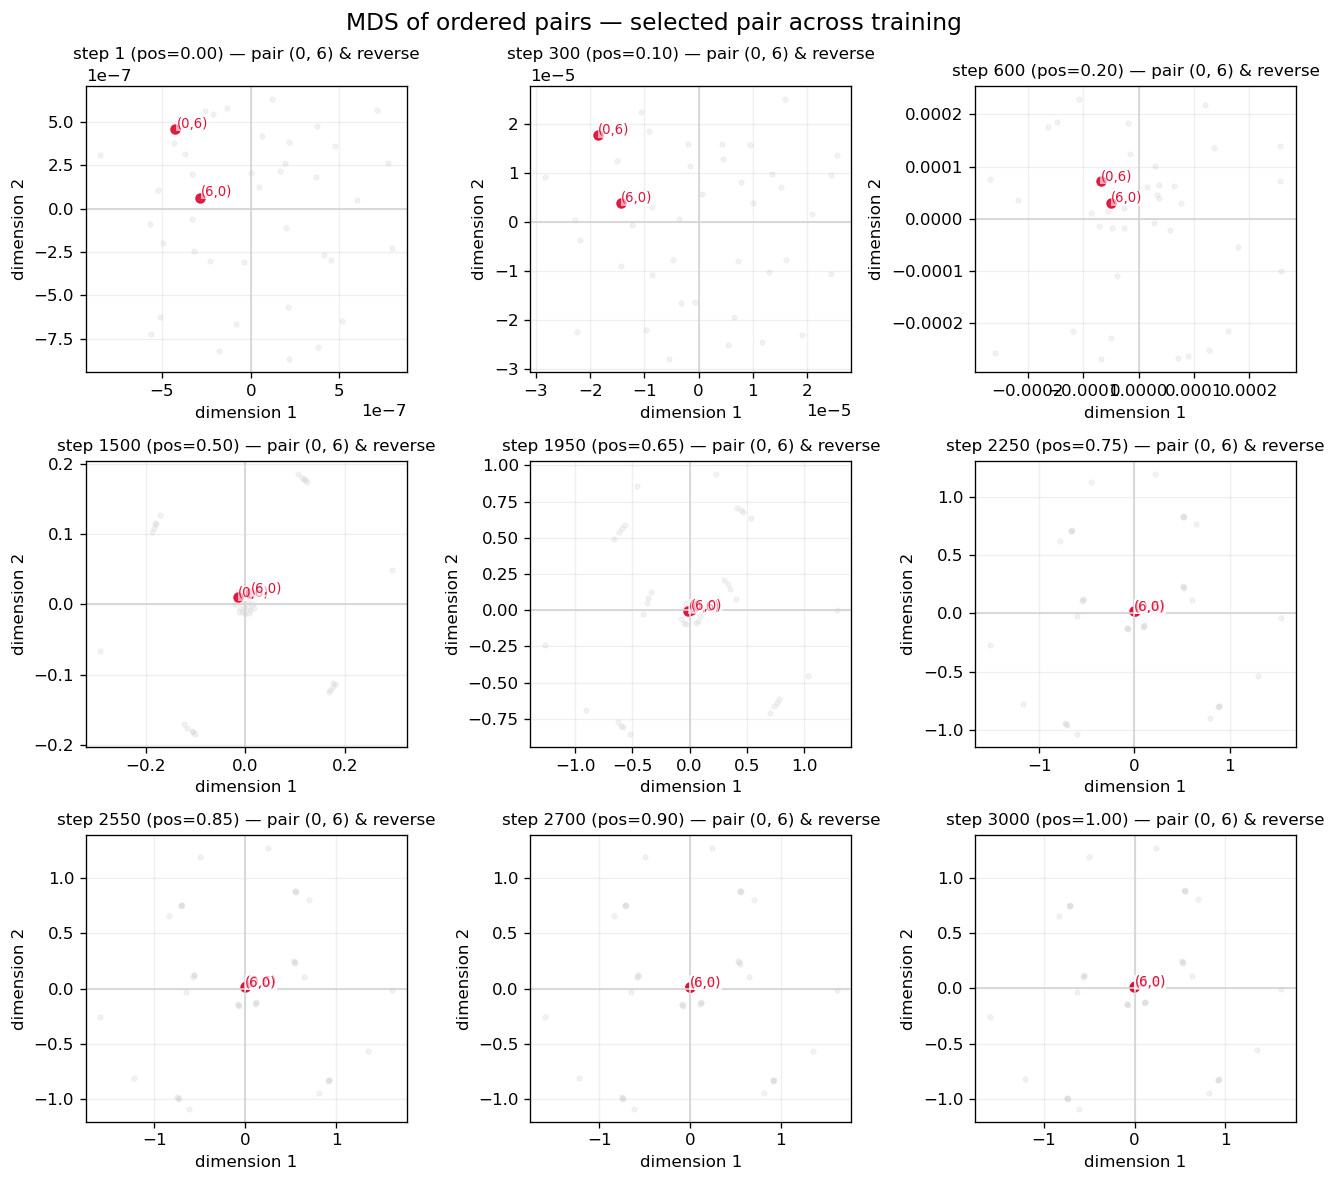

In [ ]:
# H2 (recommended)
plot_pair_mds_grid(H2_avg, pair=(0, 6), color="crimson", include_reverse=True)

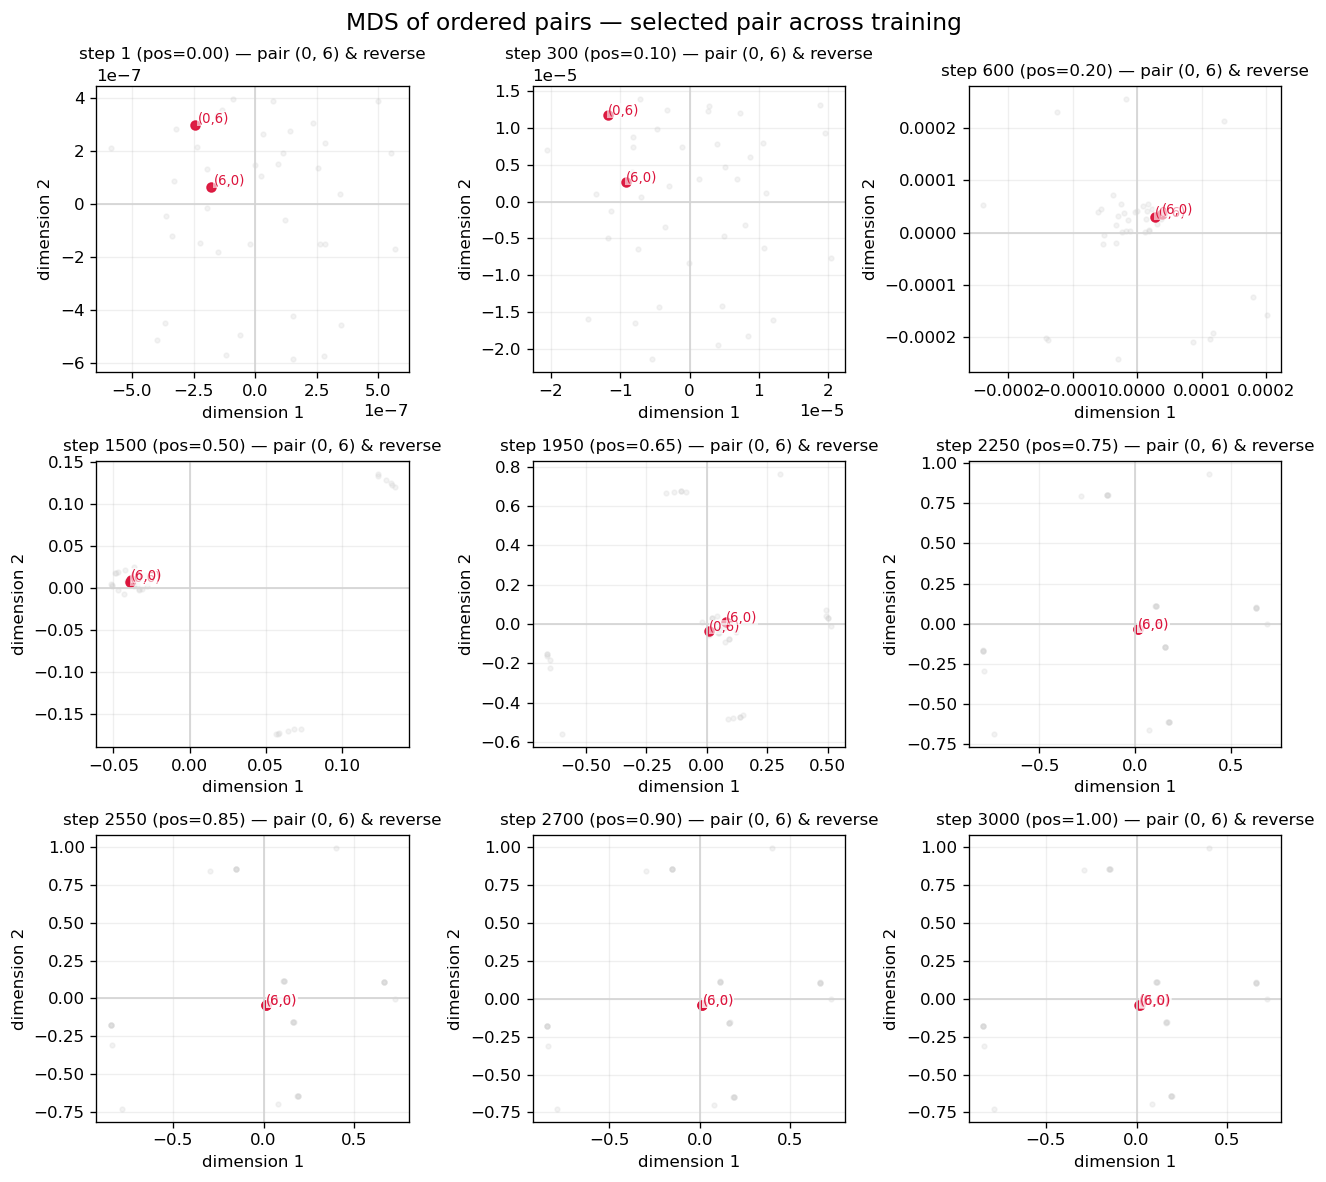

In [138]:
# H2 
plot_pair_mds_grid(H2_avg_relu, pair=(0, 6), color="crimson", include_reverse=True)

# Next: Fix the below, then can run this file for many seeds

# Plot H1s

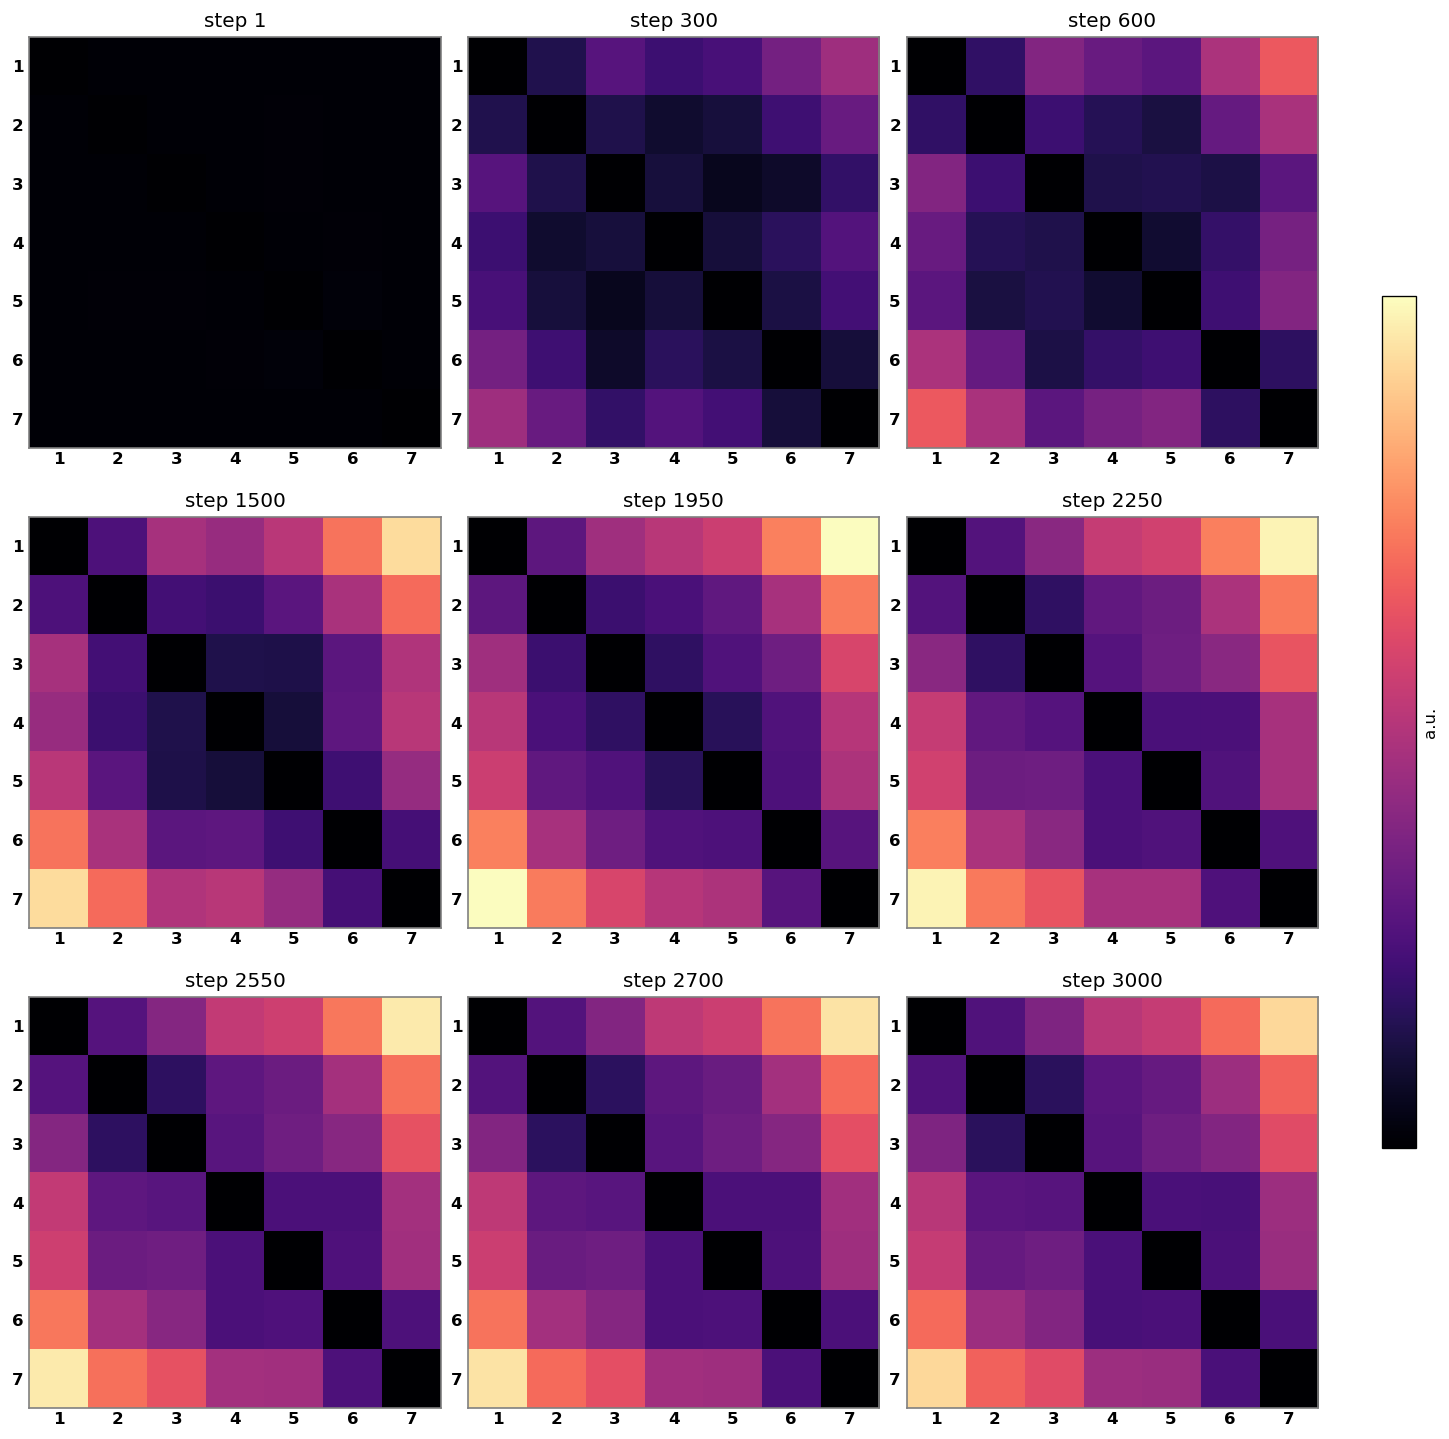

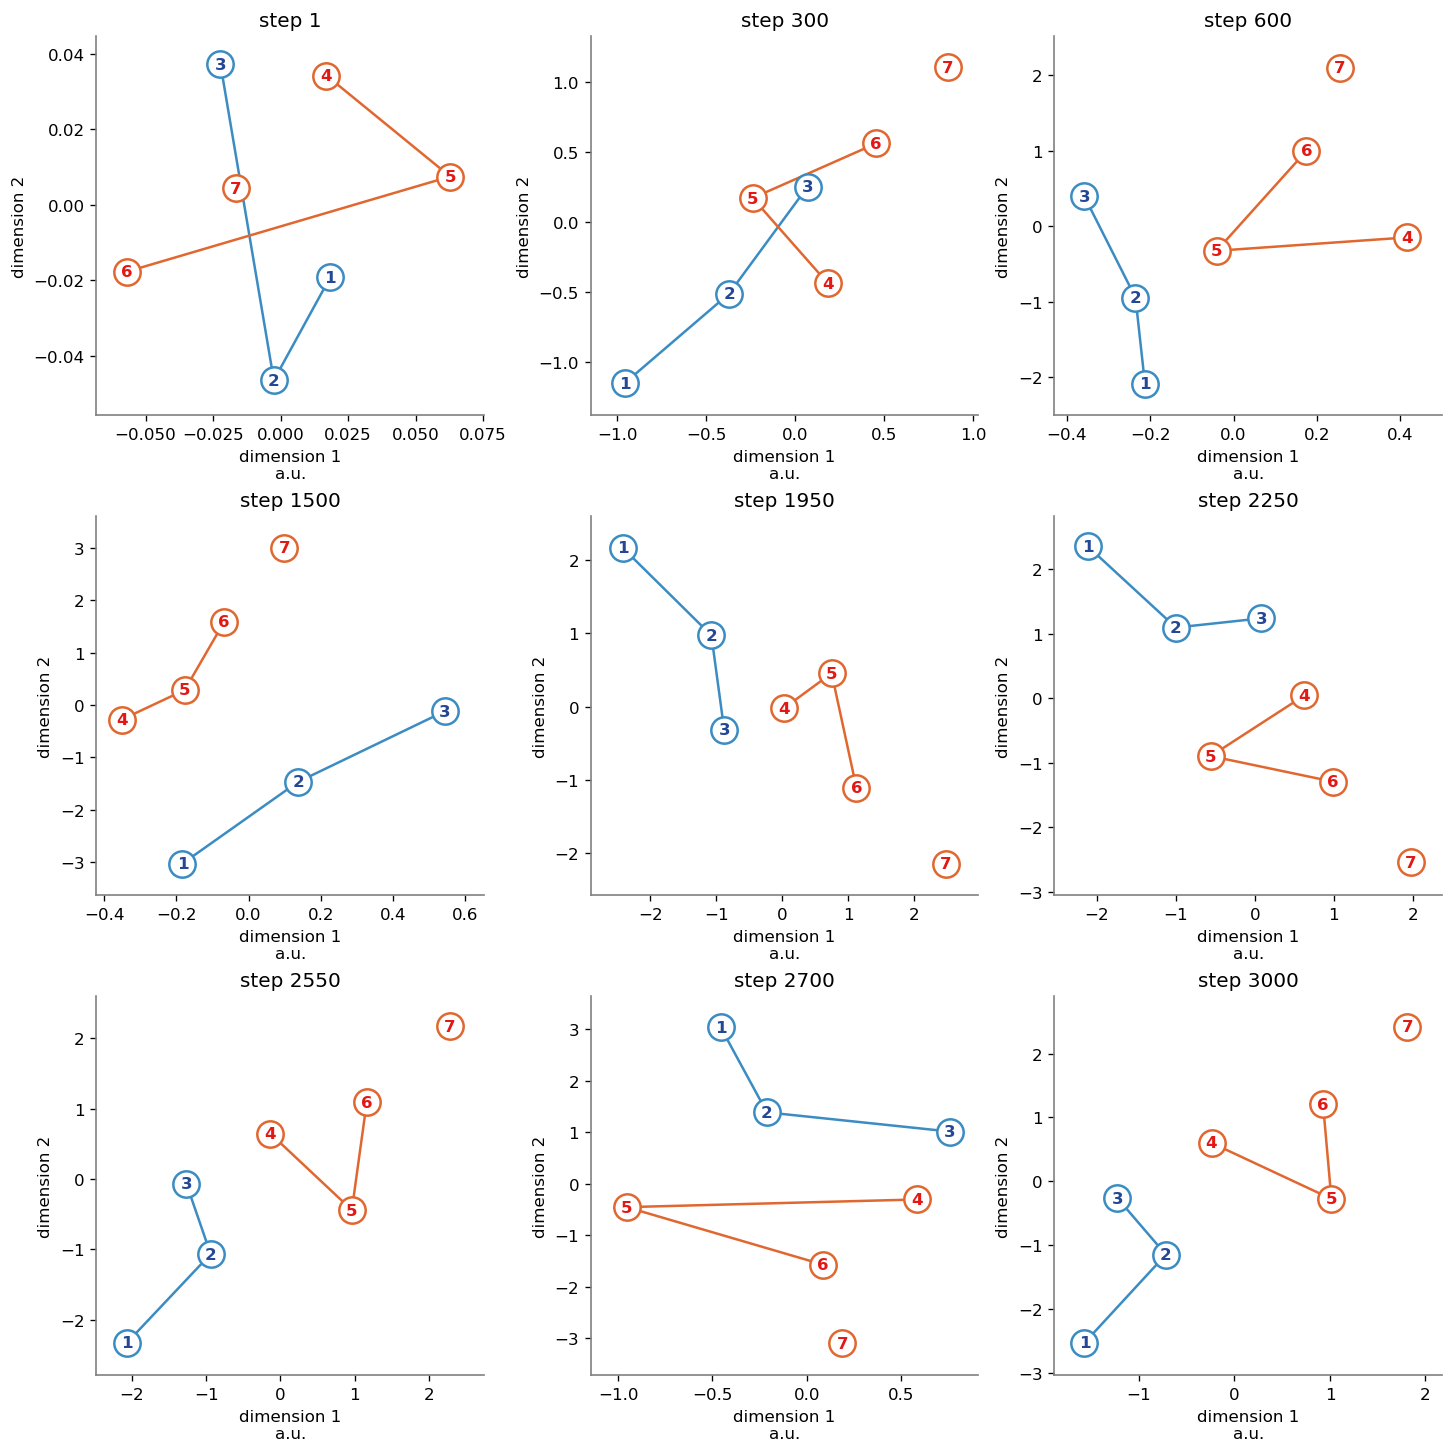

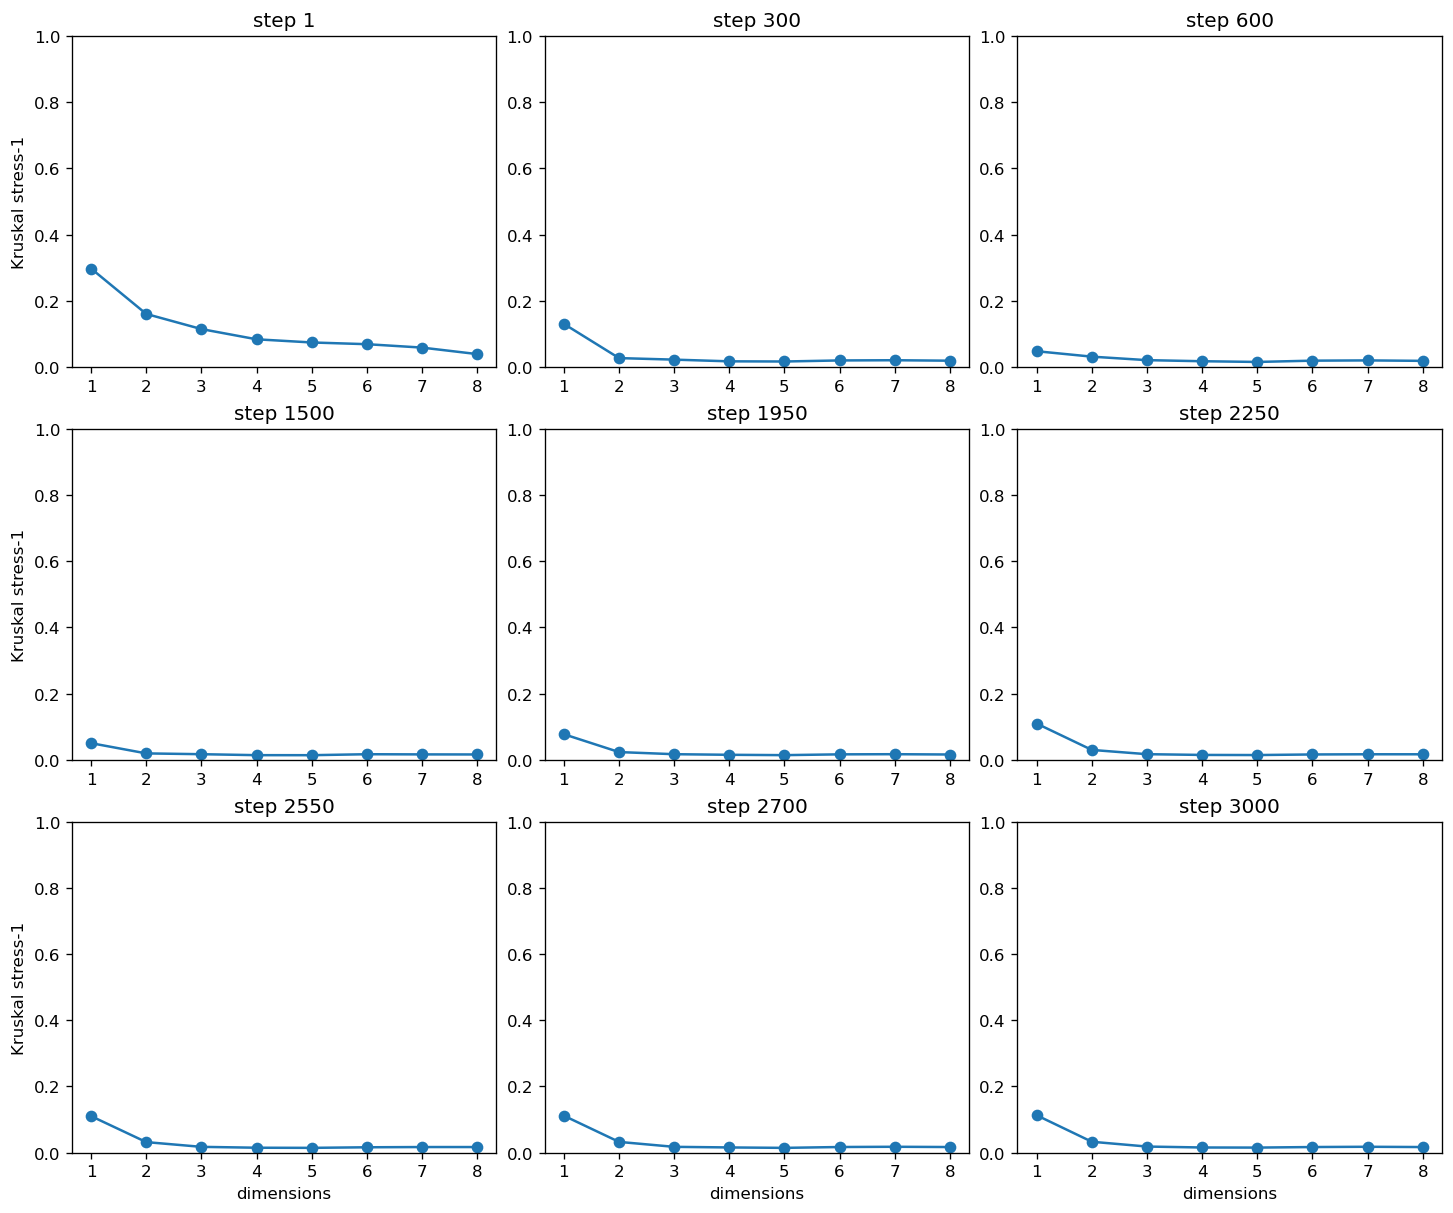

In [139]:
# Choose nine positions across training
positions = [0.00, 0.10, 0.20, 0.50, 0.65, 0.75, 0.85, 0.90, 1.00]

fig1, axs1 = plt.subplots(3, 3, figsize=(12., 12.), constrained_layout=True)
fig1.patch.set_facecolor('white')

fig2, axs2 = plt.subplots(3, 3, figsize=(12., 12.), constrained_layout=True)
fig2.patch.set_facecolor('white')

# Determine vmax across selected time slices
vmax = 0.0
for i in range(len(positions)):
    t_idx = max(0, int(positions[i] * steps_after_training))
    h1s = all_h1s[t_idx]
    vmax_ = float(np.round(np.max(euclidean_distances(h1s)), 1))
    if vmax_ > vmax:
        vmax = vmax_

# Distance matrices → 3x3 grid (fig1)
for idx, p in enumerate(positions):
    r, c = divmod(idx, 3)
    t_idx = max(0, int(p * steps_after_training))
    dists = euclidean_distances(all_h1s[t_idx])
    im = matrix_plot_safe(dists, axs1[r, c], items_n, 0., vmax)
    axs1[r, c].set_title(f"step {t_idx+1}")

cbar = fig1.colorbar(im, ax=axs1, shrink=.6, aspect=25)
cbar.set_ticks([])
cbar.ax.set_ylabel("a.u.")

# MDS embeddings → 3x3 grid (fig2)
for idx, p in enumerate(positions):
    r, c = divmod(idx, 3)
    t_idx = max(0, int(p * steps_after_training))
    dists = euclidean_distances(all_h1s[t_idx])
    mds = manifold.MDS(
        n_components=2,
        eps=1e-9,
        dissimilarity="precomputed",
        random_state=mds_seed,
        n_init=4,                     # keep behavior stable; silences FutureWarning
        normalized_stress="auto",
    )
    d1, d2 = mds.fit(dists).embedding_.T

    if idx % 3 == 0:
        rotate(d1, d2, 250.)
    elif idx % 3 == 1:
        rotate(d1, d2, 230.)
    else:
        rotate(d1, d2, 260.)

    mds_plot((d1, d2), axs2[r, c], items_n)
    axs2[r, c].set_title(f"step {t_idx+1}")

    for pos in ["left", "bottom"]:
        axs2[r, c].spines[pos].set_linewidth(1)
        axs2[r, c].spines[pos].set_color([0.5]*3)

    axs2[r, c].set_xlabel("dimension 1\na.u.")
    axs2[r, c].set_ylabel("dimension 2")

plt.show()

# Kruskal stress vs dimensions for the same positions (h1)
max_dims = 8
fig_stress, axs_stress = plt.subplots(3, 3, figsize=(12., 10.), constrained_layout=True)
fig_stress.patch.set_facecolor('white')
for idx, p in enumerate(positions):
    r, c = divmod(idx, 3)
    t_idx = max(0, int(p * steps_after_training))
    D = euclidean_distances(all_h1s[t_idx])
    denom = np.sum(D**2)
    stresses = []
    for k in range(1, max_dims + 1):
        m = manifold.MDS(n_components=k, dissimilarity="precomputed", random_state=mds_seed, n_init=4, normalized_stress="auto")
        m.fit(D)
        stress_raw = getattr(m, "stress_", None)
        if stress_raw is None or denom == 0:
            stresses.append(np.nan)
        else:
            stresses.append(np.sqrt(stress_raw / denom))  # Kruskal stress-1
    axs_stress[r, c].plot(range(1, max_dims + 1), stresses, marker='o')
    axs_stress[r, c].set_title(f"step {t_idx+1}")
    if r == 2:
        axs_stress[r, c].set_xlabel("dimensions")
    if c == 0:
        axs_stress[r, c].set_ylabel("Kruskal stress-1")
    axs_stress[r, c].set_ylim(0.0, 1.0)
plt.show()

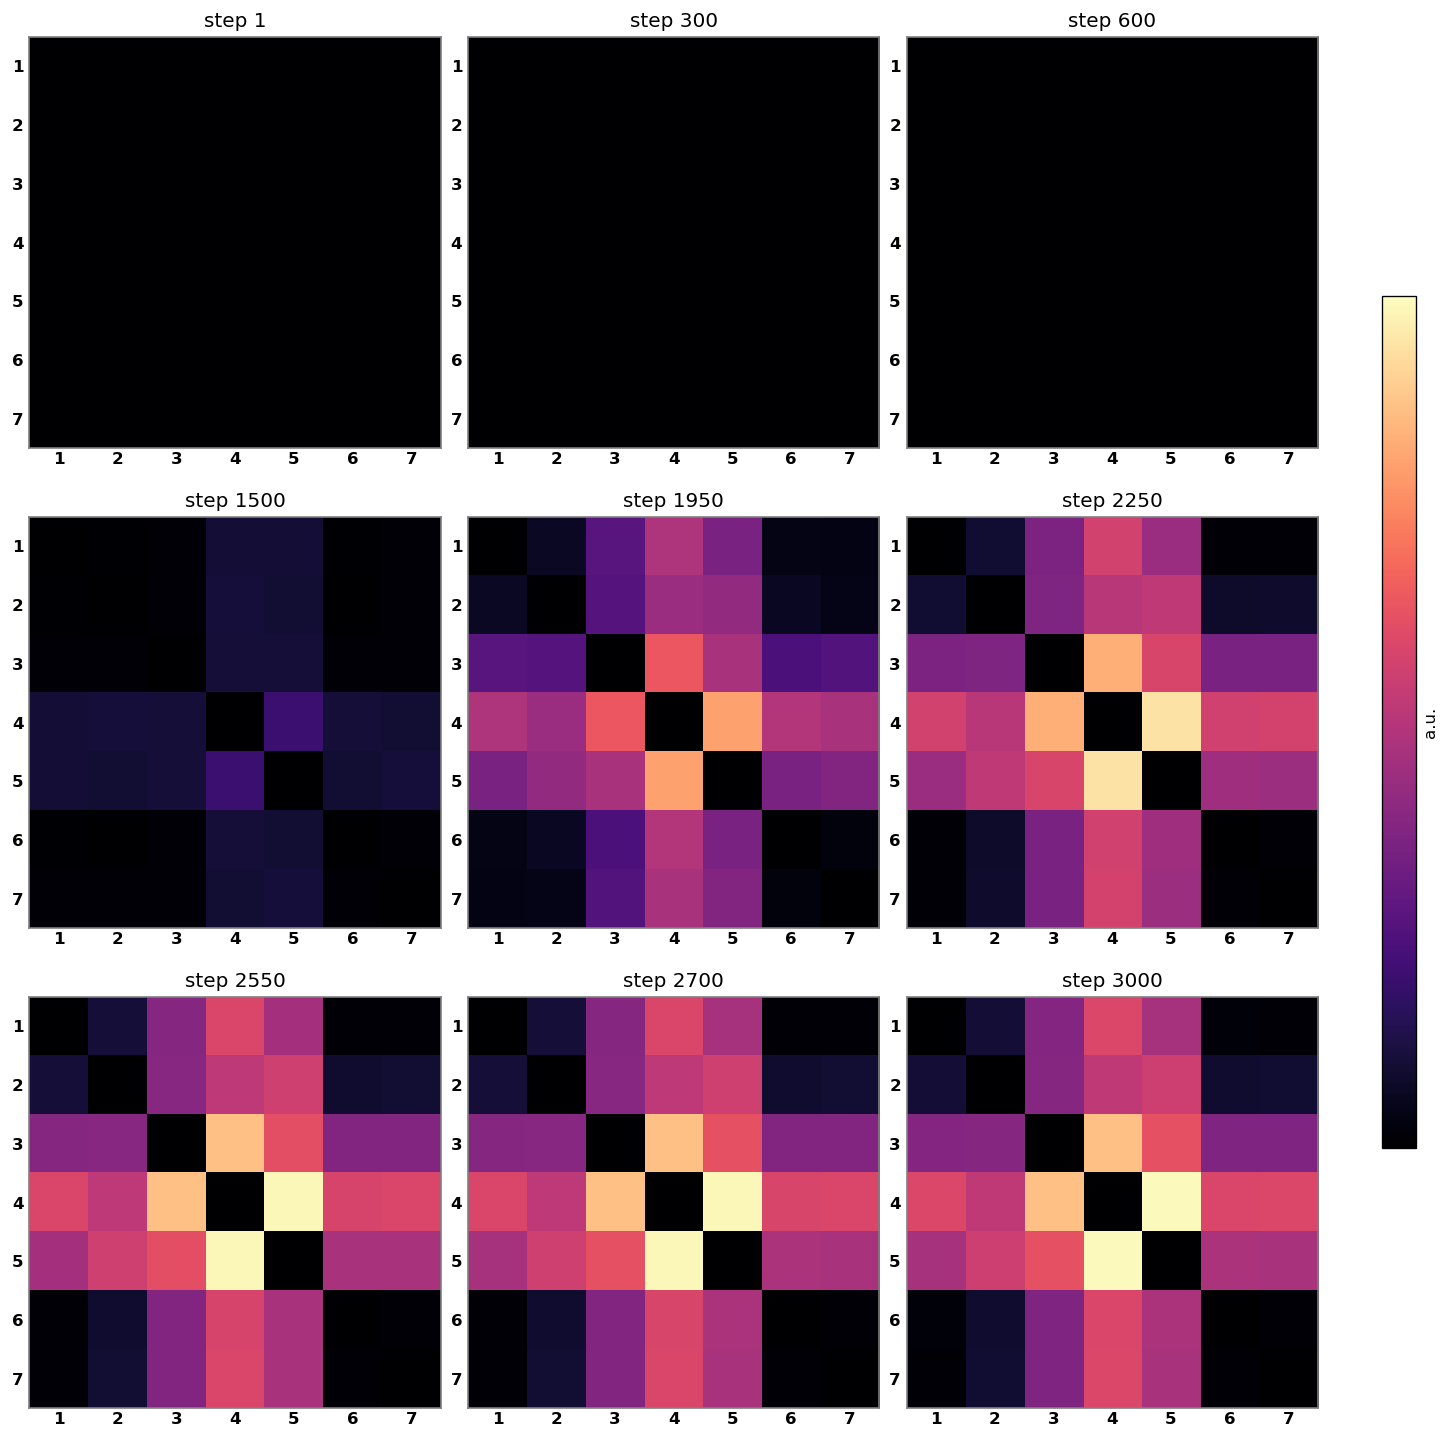

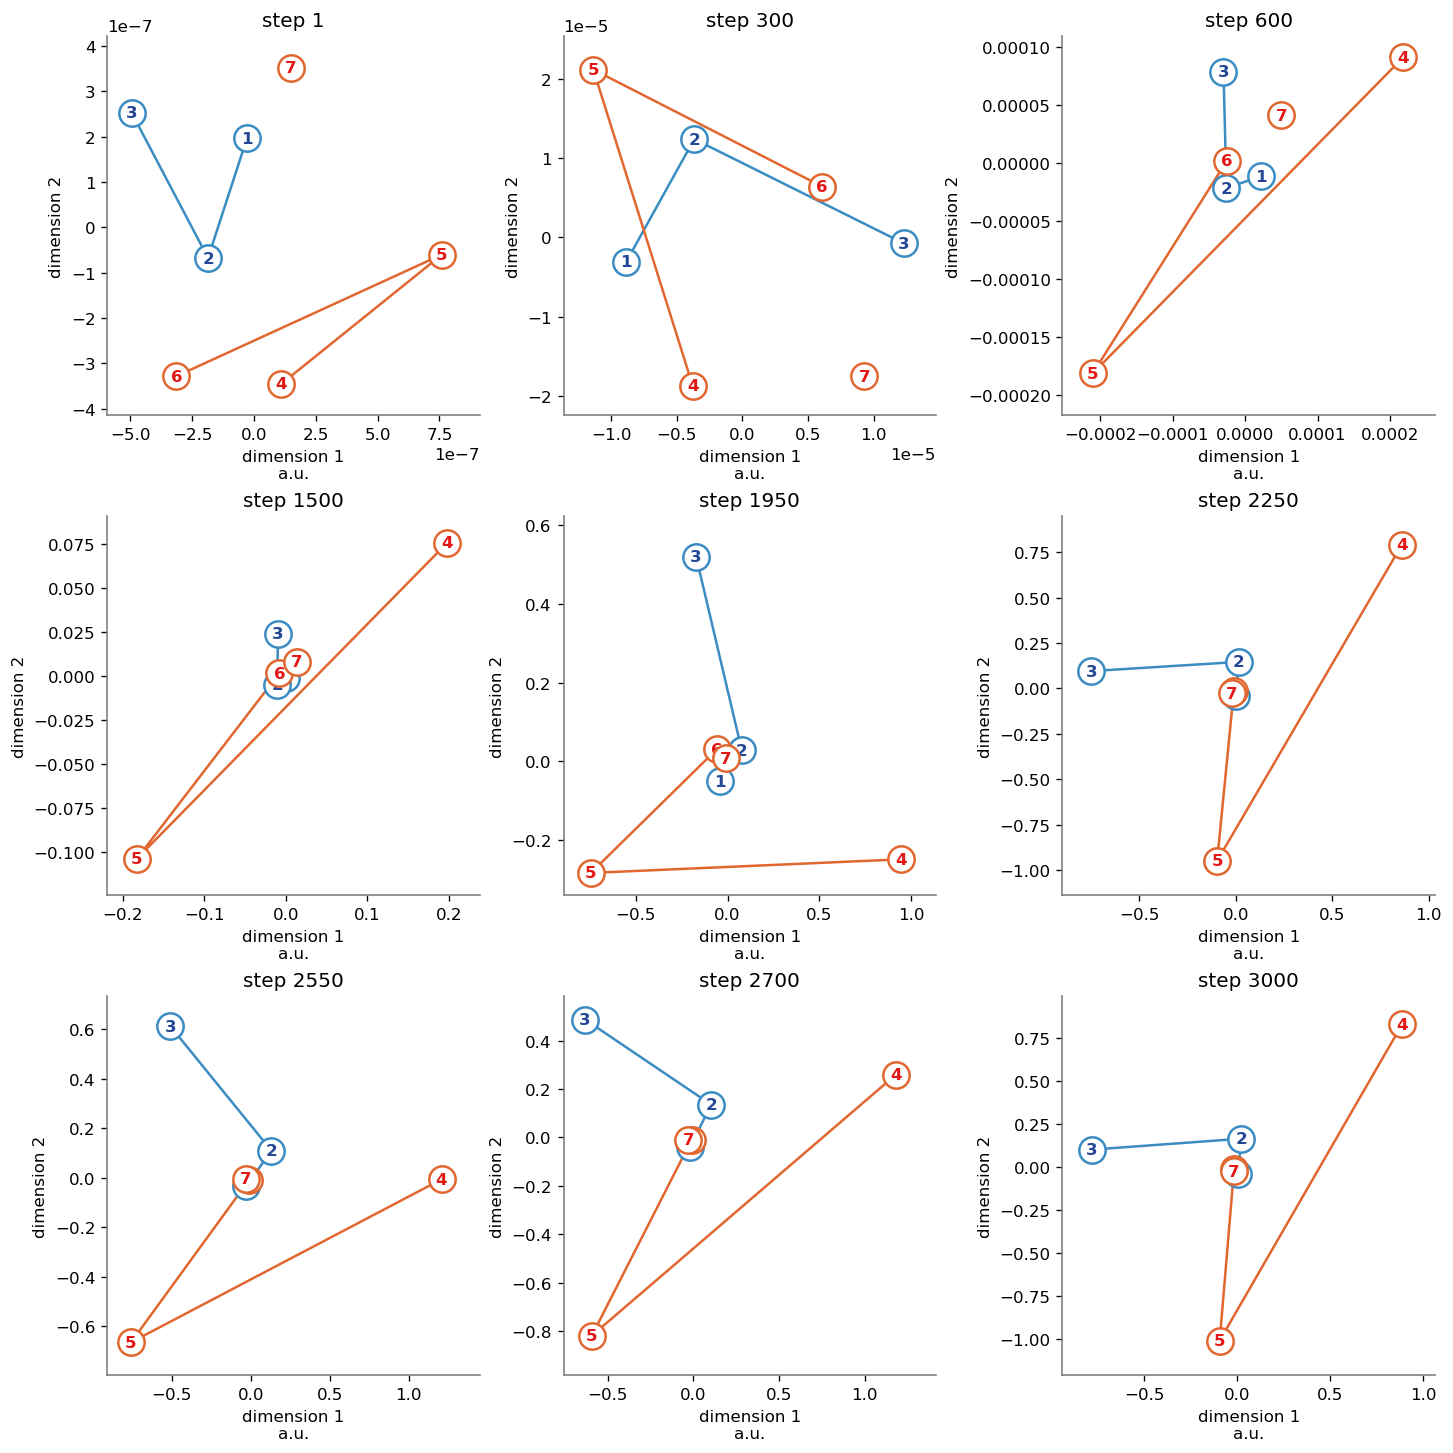

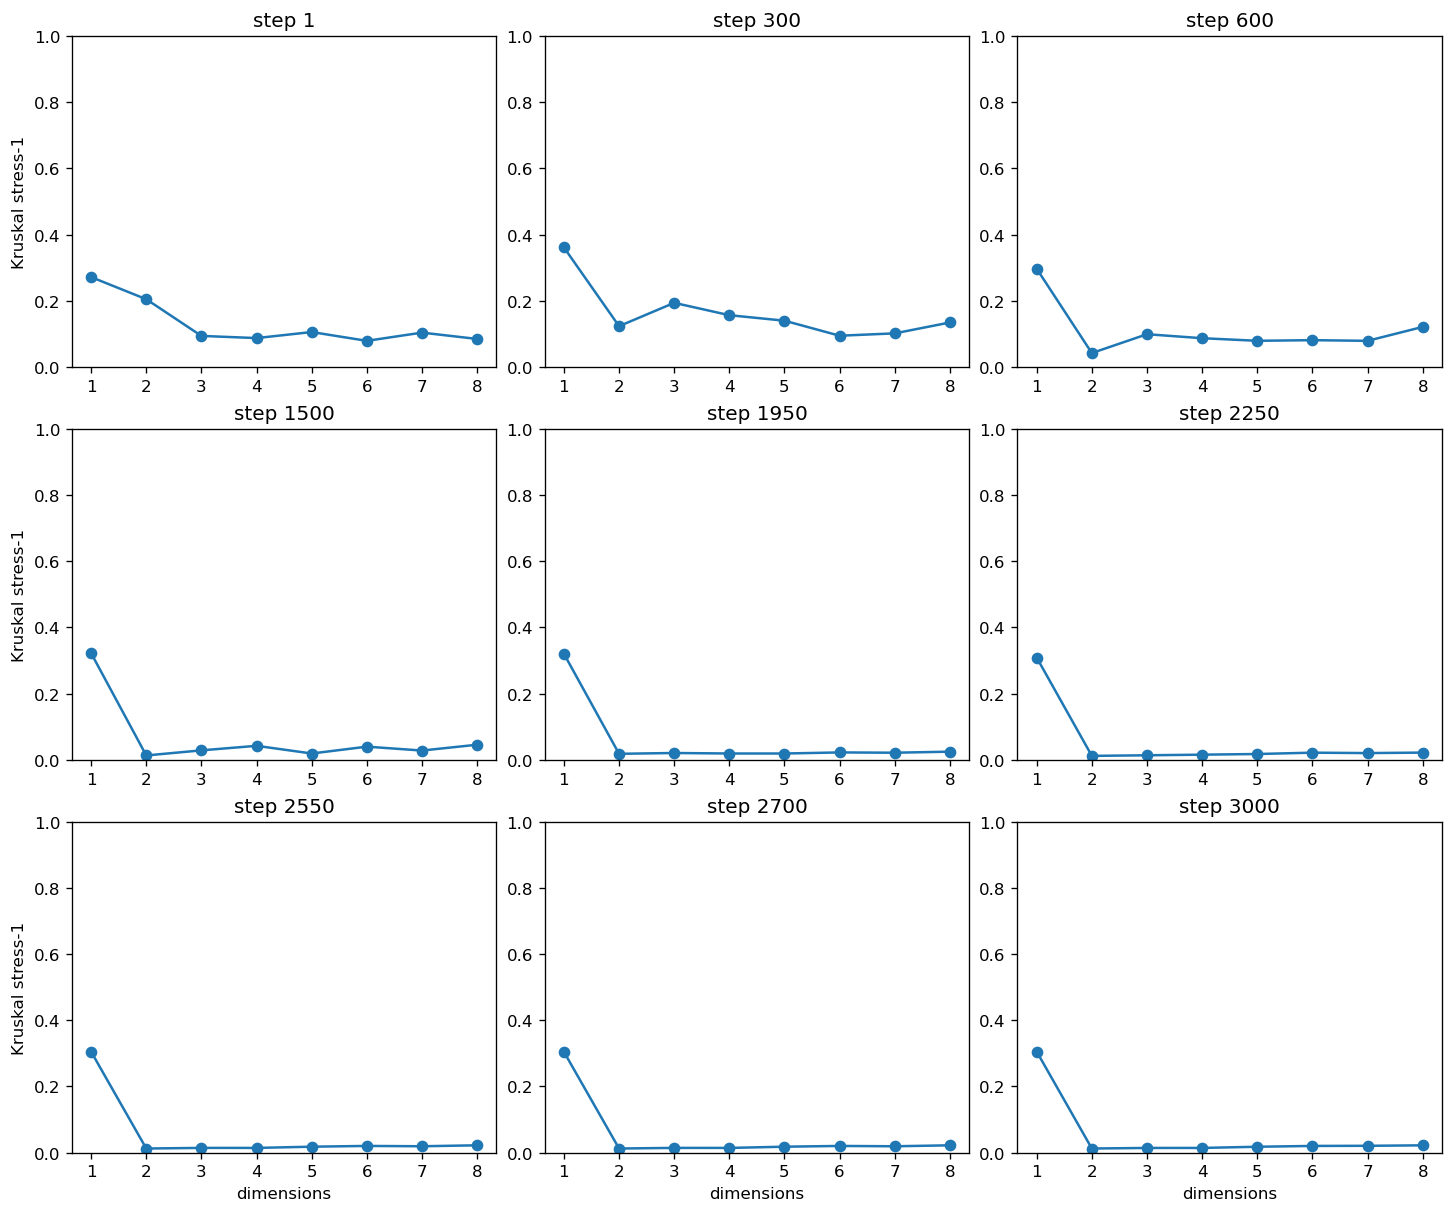

In [130]:
#### Plot H2

# Choose nine positions across training
positions = [0.00, 0.10, 0.20, 0.50, 0.65, 0.75, 0.85, 0.90, 1.00]

fig1, axs1 = plt.subplots(3, 3, figsize=(12., 12.), constrained_layout=True)
fig1.patch.set_facecolor('white')

fig2, axs2 = plt.subplots(3, 3, figsize=(12., 12.), constrained_layout=True)
fig2.patch.set_facecolor('white')

# Determine vmax across selected time slices
vmax = 0.0
for i in range(len(positions)):
    t_idx = max(0, int(positions[i] * steps_after_training))
    h2s = all_h2s[t_idx]
    vmax_ = float(np.round(np.max(euclidean_distances(h2s)), 1))
    if vmax_ > vmax:
        vmax = vmax_

# Distance matrices → 3x3 grid (fig1)
for idx, p in enumerate(positions):
    r, c = divmod(idx, 3)
    t_idx = max(0, int(p * steps_after_training))
    dists = euclidean_distances(all_h2s[t_idx])
    im = matrix_plot_safe(dists, axs1[r, c], items_n, 0., vmax)
    axs1[r, c].set_title(f"step {t_idx+1}")

cbar = fig1.colorbar(im, ax=axs1, shrink=.6, aspect=25)
cbar.set_ticks([])
cbar.ax.set_ylabel("a.u.")

# MDS embeddings → 3x3 grid (fig2)
for idx, p in enumerate(positions):
    r, c = divmod(idx, 3)
    t_idx = max(0, int(p * steps_after_training))
    dists = euclidean_distances(all_h2s[t_idx])
    mds = manifold.MDS(
        n_components=2,
        eps=1e-9,
        dissimilarity="precomputed",
        random_state=mds_seed,
        n_init=4,                     # keep behavior stable; silences FutureWarning
        normalized_stress="auto",
    )
    d1, d2 = mds.fit(dists).embedding_.T

    if idx % 3 == 0:
        rotate(d1, d2, 250.)
    elif idx % 3 == 1:
        rotate(d1, d2, 230.)
    else:
        rotate(d1, d2, 260.)

    mds_plot((d1, d2), axs2[r, c], items_n)
    axs2[r, c].set_title(f"step {t_idx+1}")

    for pos in ["left", "bottom"]:
        axs2[r, c].spines[pos].set_linewidth(1)
        axs2[r, c].spines[pos].set_color([0.5]*3)

    axs2[r, c].set_xlabel("dimension 1\na.u.")
    axs2[r, c].set_ylabel("dimension 2")

plt.show()

# Kruskal stress vs dimensions for the same positions (h2)
max_dims = 8
fig_stress_h2, axs_stress_h2 = plt.subplots(3, 3, figsize=(12., 10.), constrained_layout=True)
fig_stress_h2.patch.set_facecolor('white')
for idx, p in enumerate(positions):
    r, c = divmod(idx, 3)
    t_idx = max(0, int(p * steps_after_training))
    D = euclidean_distances(all_h2s[t_idx])
    denom = np.sum(D**2)
    stresses = []
    for k in range(1, max_dims + 1):
        m = manifold.MDS(n_components=k, dissimilarity="precomputed", random_state=mds_seed, n_init=4, normalized_stress="auto")
        m.fit(D)
        stress_raw = getattr(m, "stress_", None)
        if stress_raw is None or denom == 0:
            stresses.append(np.nan)
        else:
            stresses.append(np.sqrt(stress_raw / denom))  # Kruskal stress-1
    axs_stress_h2[r, c].plot(range(1, max_dims + 1), stresses, marker='o')
    axs_stress_h2[r, c].set_title(f"step {t_idx+1}")
    if r == 2:
        axs_stress_h2[r, c].set_xlabel("dimensions")
    if c == 0:
        axs_stress_h2[r, c].set_ylabel("Kruskal stress-1")
    axs_stress_h2[r, c].set_ylim(0.0, 1.0)
plt.show()


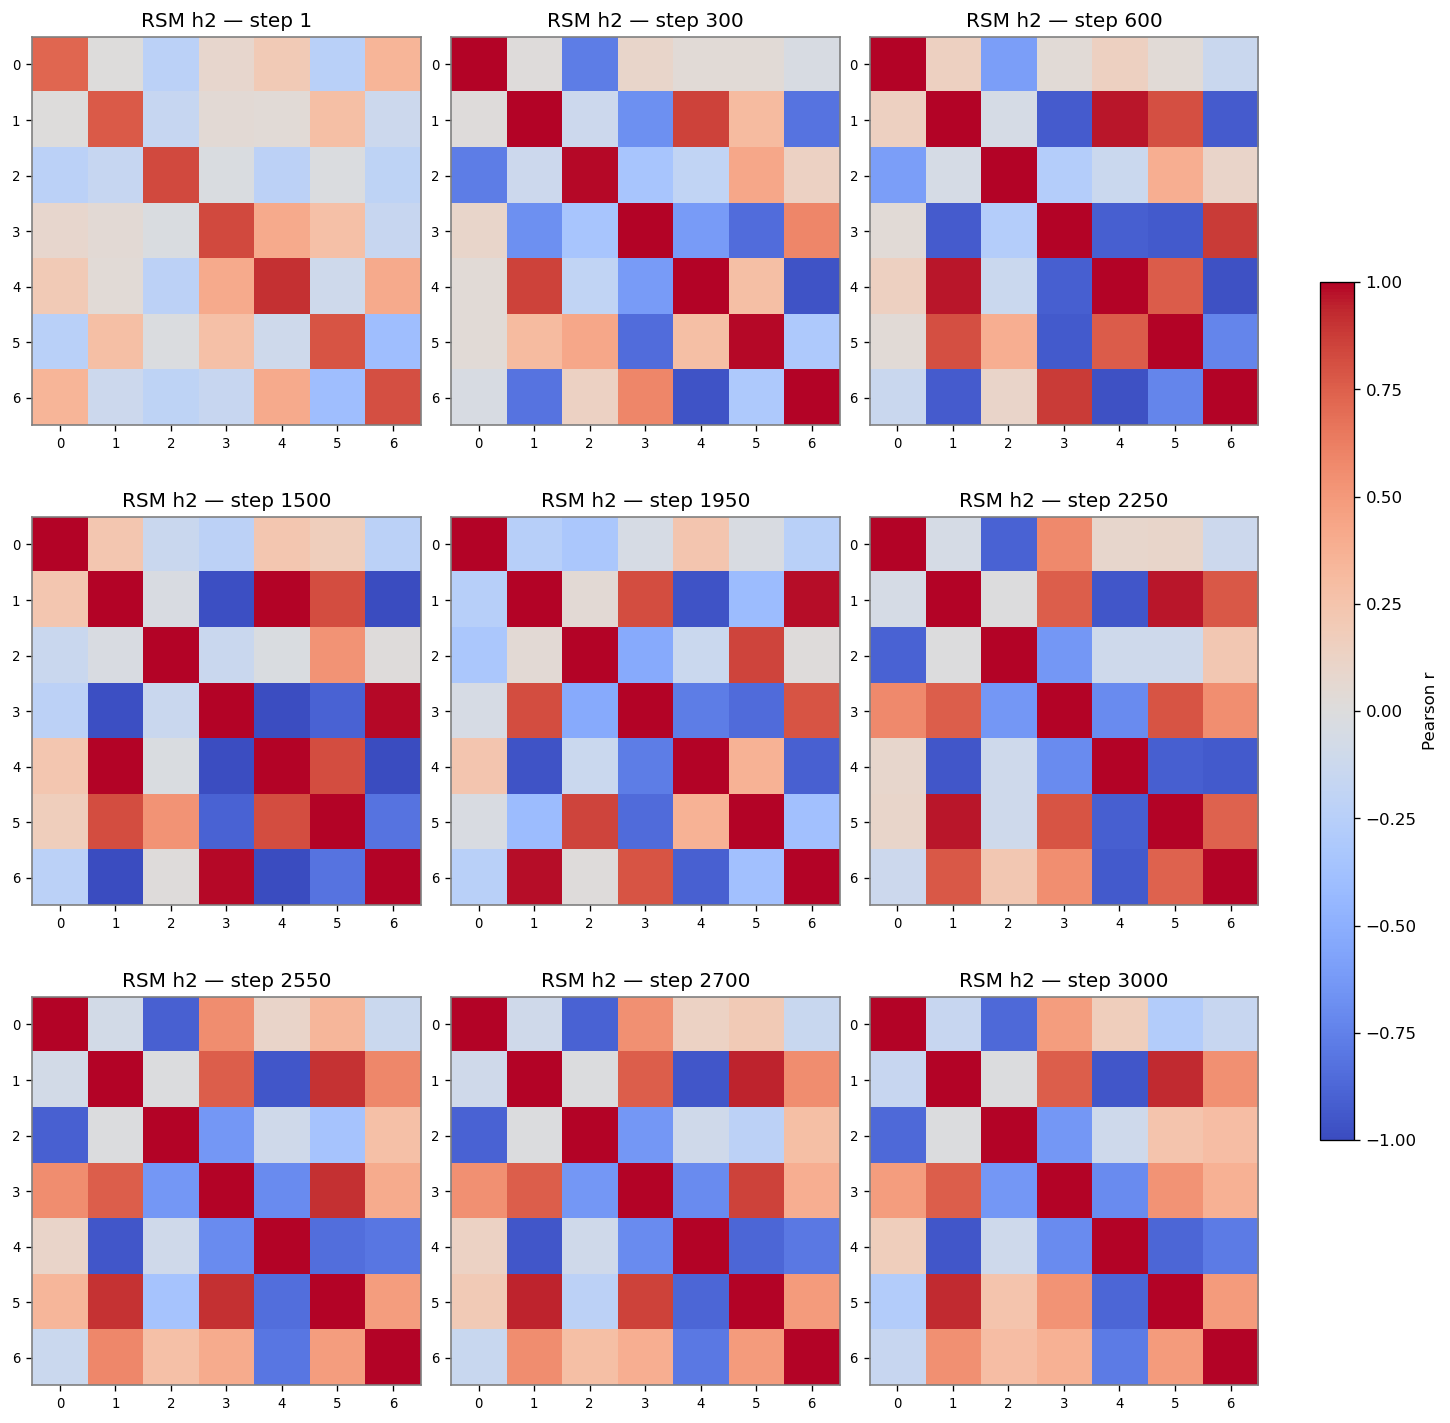

In [140]:
# Representational Similarity Matrices (RSM) for h2 with normalization (Pearson correlation)
import numpy as np
import matplotlib.pyplot as plt

# H2_avg = np.nan_to_num(H2.mean(axis=0), nan=0.0, posinf=0.0, neginf=0.0)  # (time_steps, items_n, h2_size)
time_steps, items_n_inferred, h2_size = H2_avg.shape

# Positions to display
positions = [0.00, 0.10, 0.20, 0.50, 0.65, 0.75, 0.85, 0.90, 1.00]
steps_after_training = time_steps - 1

fig, axs = plt.subplots(3, 3, figsize=(12., 12.), constrained_layout=True)
fig.patch.set_facecolor('white')

im = None
for idx, p in enumerate(positions):
    r, c = divmod(idx, 3)
    t_idx = max(0, int(p * steps_after_training))
    X = H2_avg[t_idx]  # (items_n, h2_size)
    # Normalize each item's vector (z-score across features) for Pearson correlation
    X = X - X.mean(axis=1, keepdims=True)
    denom = X.std(axis=1, keepdims=True) + 1e-8
    Xn = X / denom
    # Pearson similarity between items (i by j)
    sim = (Xn @ Xn.T) / Xn.shape[1]
    sim = np.clip(sim, -1.0, 1.0)
    # Handle any numerical NaNs
    sim = np.nan_to_num(sim, nan=0.0, posinf=0.0, neginf=0.0)

    ax = axs[r, c]
    im = ax.imshow(sim, vmin=-1, vmax=1, cmap='coolwarm')
    ax.set_title(f"RSM h2 — step {t_idx+1}")
    ax.set_xticks(range(items_n_inferred))
    ax.set_yticks(range(items_n_inferred))
    ax.set_xticklabels([str(i) for i in range(items_n_inferred)])
    ax.set_yticklabels([str(i) for i in range(items_n_inferred)])
    ax.tick_params(axis='both', labelsize=8)
    for pos in ["top", "right", "bottom", "left"]:
        ax.spines[pos].set_linewidth(1)
        ax.spines[pos].set_color([0.5] * 3)

cbar = fig.colorbar(im, ax=axs, shrink=.6, aspect=25)
cbar.set_label('Pearson r')
plt.show()


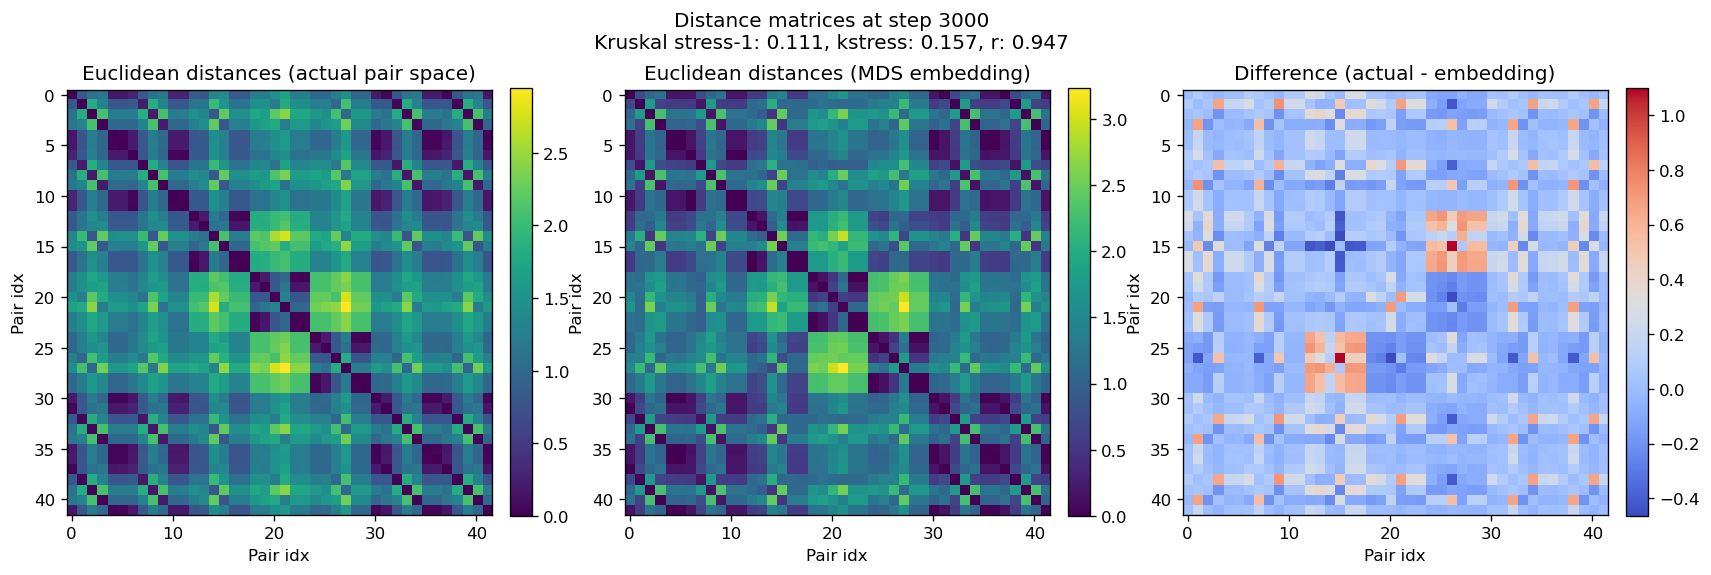

In [141]:
# For the most recent MDS step, compute and display the distance matrices in the actual space and the embedding (MDS) space,
# and also plot the difference between the two.

# We'll use the latest position in the previous loop, i.e., last pos and last step_idx
step_idx = step_idxs[-1]
V, labels, pairs = build_pairs(H2_avg[step_idx])
D_actual = euclidean_distances(V)

# Fit MDS to get embedding
coords, stress1, kst, r = fit_mds_with_stress(D_actual, seed)
D_embedded = euclidean_distances(coords)

# Compute the difference matrix (actual - embedded)
D_diff = D_actual - D_embedded

# Show as heatmaps side by side for visual comparison, with a third panel for the difference
fig, axs = plt.subplots(1, 3, figsize=(17, 5))

# Actual distances
im0 = axs[0].imshow(D_actual, cmap="viridis")
axs[0].set_title("Euclidean distances (actual pair space)")
axs[0].set_xlabel("Pair idx")
axs[0].set_ylabel("Pair idx")
plt.colorbar(im0, ax=axs[0], fraction=0.046, pad=0.04)

# Embedded distances
im1 = axs[1].imshow(D_embedded, cmap="viridis")
axs[1].set_title("Euclidean distances (MDS embedding)")
axs[1].set_xlabel("Pair idx")
axs[1].set_ylabel("Pair idx")
plt.colorbar(im1, ax=axs[1], fraction=0.046, pad=0.04)

# Difference
im2 = axs[2].imshow(D_diff, cmap="coolwarm")
axs[2].set_title("Difference (actual - embedding)")
axs[2].set_xlabel("Pair idx")
axs[2].set_ylabel("Pair idx")
plt.colorbar(im2, ax=axs[2], fraction=0.046, pad=0.04)

plt.suptitle(
    f"Distance matrices at step {step_idx+1}\n"
    f"Kruskal stress-1: {stress1:.3f}, kstress: {kst:.3f}, r: {r:.3f}"
)
plt.show()

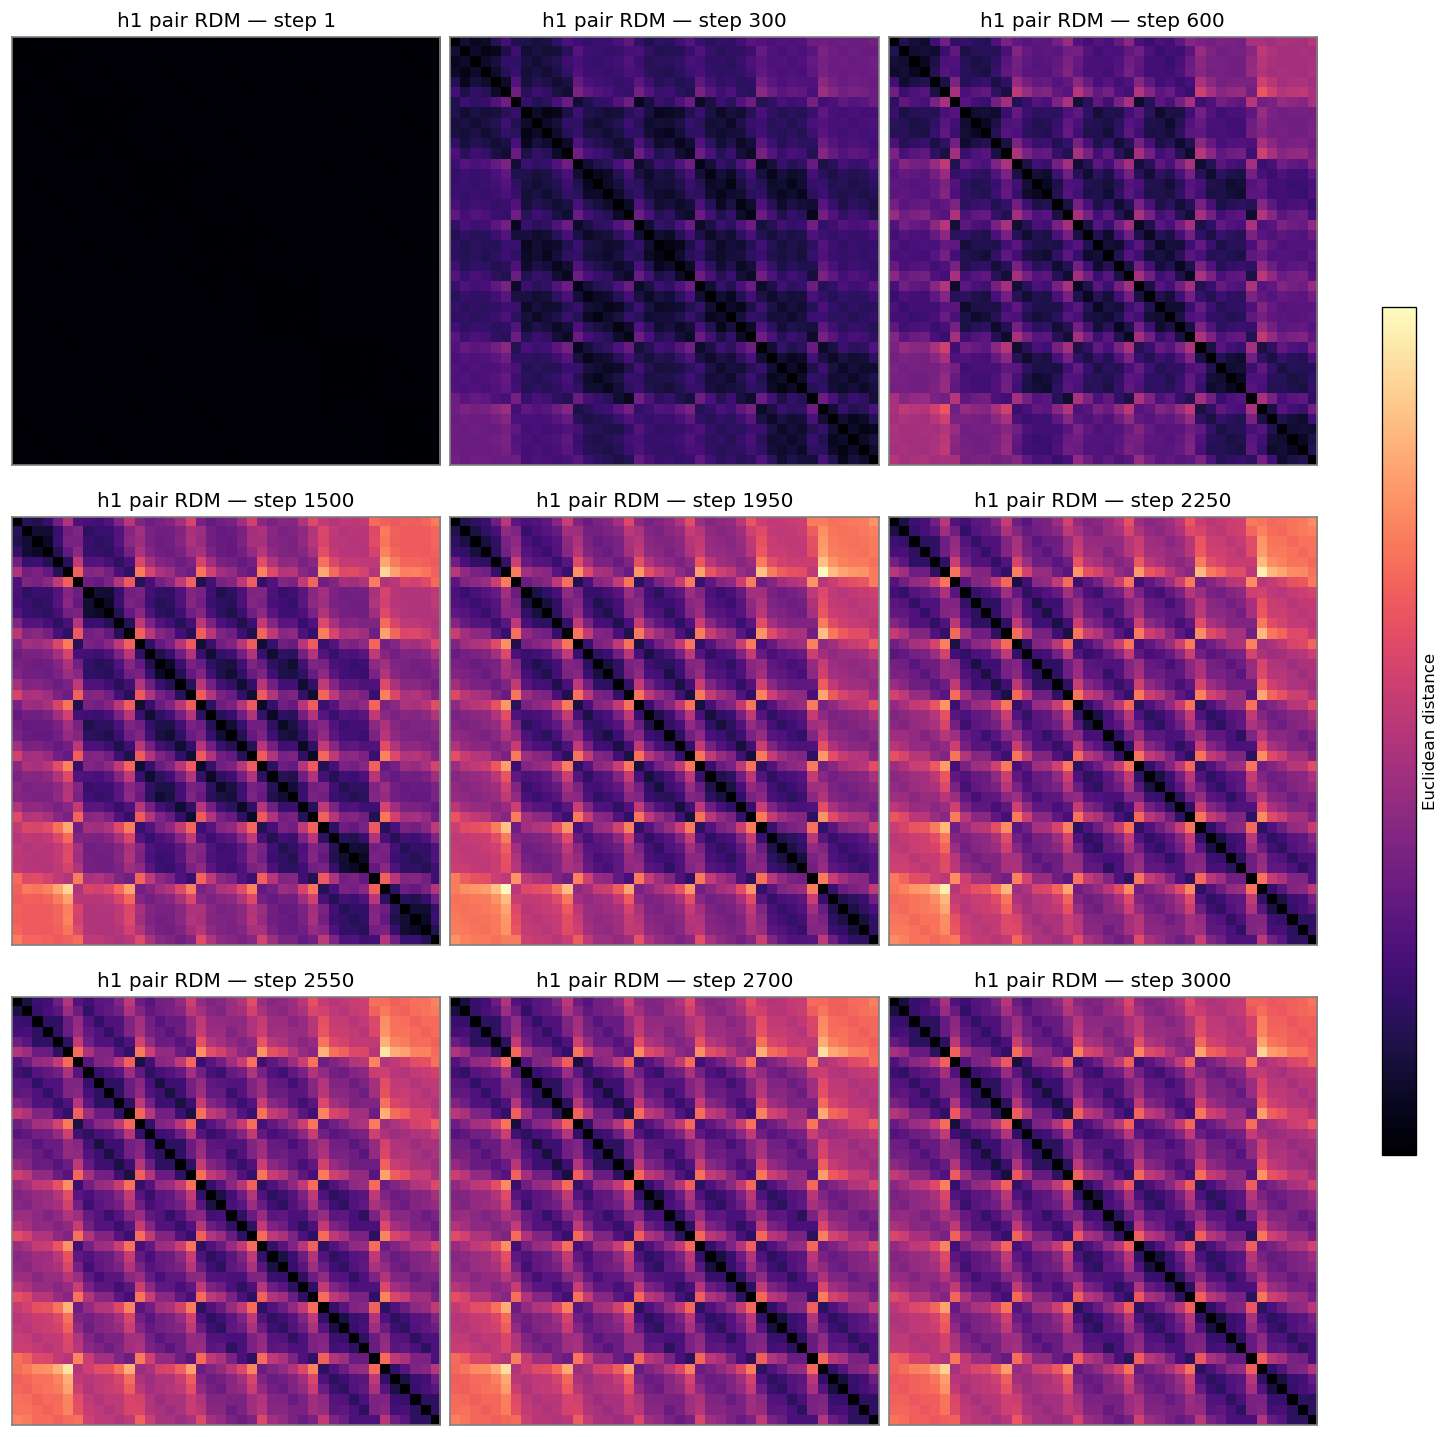

x-axis pairings for the h1 pair RDMs (plot order):

0: (0,1)
1: (0,2)
2: (0,3)
3: (0,4)
4: (0,5)
5: (0,6)
6: (1,0)
7: (1,2)
8: (1,3)
9: (1,4)
10: (1,5)
11: (1,6)
12: (2,0)
13: (2,1)
14: (2,3)
15: (2,4)
16: (2,5)
17: (2,6)
18: (3,0)
19: (3,1)
20: (3,2)
21: (3,4)
22: (3,5)
23: (3,6)
24: (4,0)
25: (4,1)
26: (4,2)
27: (4,3)
28: (4,5)
29: (4,6)
30: (5,0)
31: (5,1)
32: (5,2)
33: (5,3)
34: (5,4)
35: (5,6)
36: (6,0)
37: (6,1)
38: (6,2)
39: (6,3)
40: (6,4)
41: (6,5)


In [142]:
# Pair RDMs (Euclidean) for h1 pair embeddings across nine positions

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import euclidean_distances

def load_layer_from_csv_gz(csv_gz_path):
    df = pd.read_csv(csv_gz_path, compression='gzip')
    seed_cols = [c for c in df.columns if c.startswith('seed_')]
    time_steps = int(df['time_step'].max()) + 1
    items_n = int(df['item'].max()) + 1
    units = int(df['unit'].max()) + 1
    seeds_n = len(seed_cols)
    arr = np.zeros((seeds_n, time_steps, items_n, units))
    for _, row in df.iterrows():
        t = int(row['time_step']); i = int(row['item']); u = int(row['unit'])
        for s_idx, sc in enumerate(seed_cols):
            arr[s_idx, t, i, u] = row[sc]
    return arr  # (seeds, time, items, units)

def build_pair_vectors(X_items):
    # Ordered pairs (i != j), feature = concat(X[i], X[j])
    vecs, labels = [], []
    n = X_items.shape[0]
    for i in range(n):
        for j in range(n):
            if i == j:
                continue
            v = np.concatenate([X_items[i], X_items[j]], axis=0)
            vecs.append(v)
            labels.append(f"({i},{j})")
    V = np.asarray(vecs)
    V = np.nan_to_num(V, nan=0.0, posinf=0.0, neginf=0.0)
    V = V - V.mean(axis=0, keepdims=True)
    return V, labels

# Load h1s from gzipped CSV and average across seeds
csv_gz_h1_path = "conjunctive_lazy_rich_h1s.csv.gz"
H1 = load_layer_from_csv_gz(csv_gz_h1_path).mean(axis=0)  # (time, items, h1)
items_n = H1.shape[1]
steps_after = H1.shape[0] - 1

# Same nine positions as above
positions = [0.00, 0.10, 0.20, 0.50, 0.65, 0.75, 0.85, 0.90, 1.00]

# Find shared vmax across selected steps for consistent color scale
vmax = 0.0
for p in positions:
    t_idx = max(0, int(p * steps_after))
    X_items = np.nan_to_num(H1[t_idx], nan=0.0, posinf=0.0, neginf=0.0)
    V, _ = build_pair_vectors(X_items)
    D = euclidean_distances(V)
    vmax = max(vmax, float(np.ceil(np.max(D) * 10) / 10.0))
if vmax == 0.0:
    vmax = 1.0

fig, axs = plt.subplots(3, 3, figsize=(12., 12.), constrained_layout=True)
fig.patch.set_facecolor('white')

for idx, p in enumerate(positions):
    r, c = divmod(idx, 3)
    t_idx = max(0, int(p * steps_after))
    X_items = np.nan_to_num(H1[t_idx], nan=0.0, posinf=0.0, neginf=0.0)
    V, labels = build_pair_vectors(X_items)
    D = euclidean_distances(V)  # RDM of pairs

    ax = axs[r, c]
    im = ax.imshow(D, cmap=plt.cm.magma, vmin=0.0, vmax=vmax, interpolation='nearest')
    ax.set_title(f"h1 pair RDM — step {t_idx+1}")
    # Too many pairs to label ticks cleanly; hide ticks for readability
    ax.set_xticks([])
    ax.set_yticks([])
    for pos in ["top", "right", "bottom", "left"]:
        ax.spines[pos].set_linewidth(1)
        ax.spines[pos].set_color([0.5]*3)

cbar = fig.colorbar(im, ax=axs, shrink=.6, aspect=25)
cbar.set_ticks([])
cbar.ax.set_ylabel("Euclidean distance")
plt.show()

# Write out the x axes pairings (labels) used in the RDM plots above.
print("x-axis pairings for the h1 pair RDMs (plot order):\n")
for idx, label in enumerate(labels):
    print(f"{idx}: {label}")


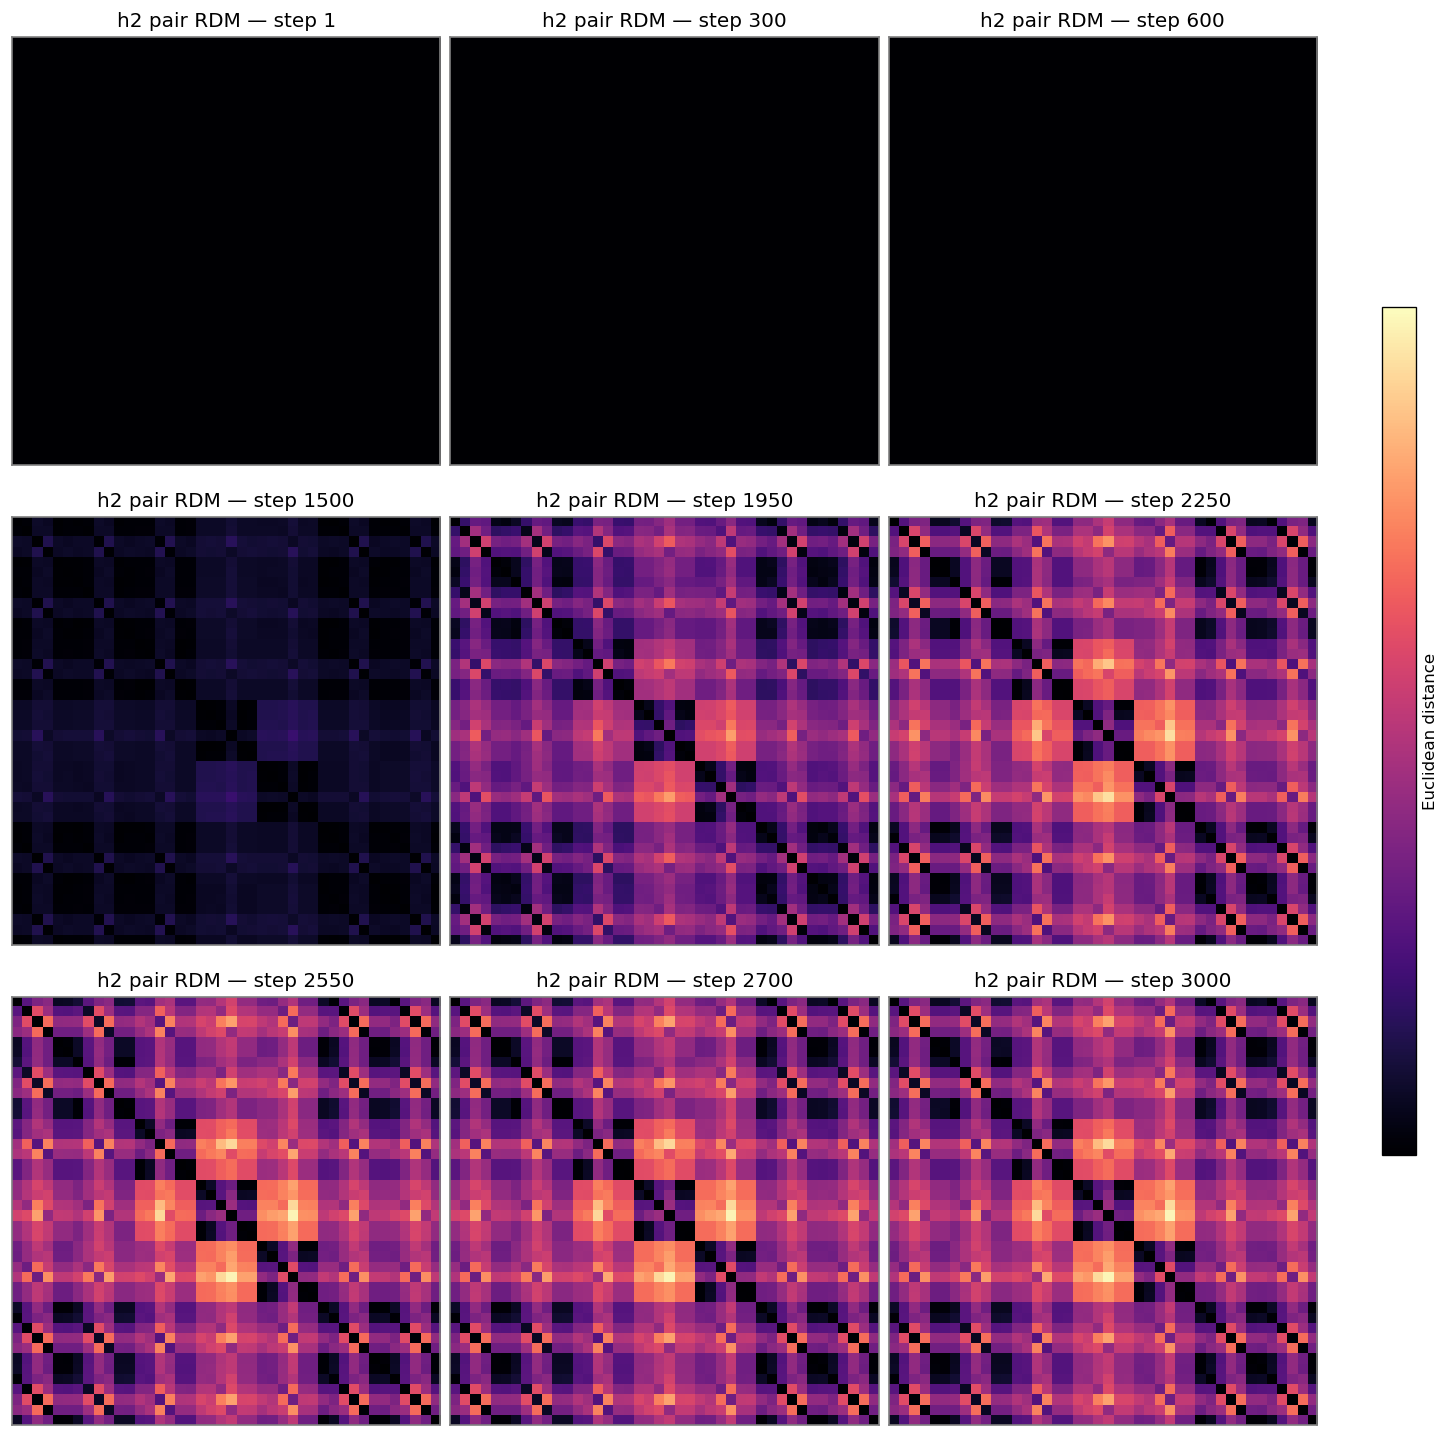

x-axis pairings for the h2 pair RDMs (plot order):

0: (0,1)
1: (0,2)
2: (0,3)
3: (0,4)
4: (0,5)
5: (0,6)
6: (1,0)
7: (1,2)
8: (1,3)
9: (1,4)
10: (1,5)
11: (1,6)
12: (2,0)
13: (2,1)
14: (2,3)
15: (2,4)
16: (2,5)
17: (2,6)
18: (3,0)
19: (3,1)
20: (3,2)
21: (3,4)
22: (3,5)
23: (3,6)
24: (4,0)
25: (4,1)
26: (4,2)
27: (4,3)
28: (4,5)
29: (4,6)
30: (5,0)
31: (5,1)
32: (5,2)
33: (5,3)
34: (5,4)
35: (5,6)
36: (6,0)
37: (6,1)
38: (6,2)
39: (6,3)
40: (6,4)
41: (6,5)


In [143]:
# Pair RDMs (Euclidean) for h2 pair embeddings across nine positions

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import euclidean_distances

def load_layer_from_csv_gz(csv_gz_path):
    df = pd.read_csv(csv_gz_path, compression='gzip')
    seed_cols = [c for c in df.columns if c.startswith('seed_')]
    time_steps = int(df['time_step'].max()) + 1
    items_n = int(df['item'].max()) + 1
    units = int(df['unit'].max()) + 1
    seeds_n = len(seed_cols)
    arr = np.zeros((seeds_n, time_steps, items_n, units))
    for _, row in df.iterrows():
        t = int(row['time_step']); i = int(row['item']); u = int(row['unit'])
        for s_idx, sc in enumerate(seed_cols):
            arr[s_idx, t, i, u] = row[sc]
    return arr  # (seeds, time, items, units)

def build_pair_vectors(X_items):
    # Ordered pairs (i != j), feature = concat(X[i], X[j])
    vecs, labels = [], []
    n = X_items.shape[0]
    for i in range(n):
        for j in range(n):
            if i == j:
                continue
            v = np.concatenate([X_items[i], X_items[j]], axis=0)
            vecs.append(v)
            labels.append(f"({i},{j})")
    V = np.asarray(vecs)
    V = np.nan_to_num(V, nan=0.0, posinf=0.0, neginf=0.0)
    V = V - V.mean(axis=0, keepdims=True)
    return V, labels

# Load h2s from gzipped CSV and average across seeds
csv_gz_h2_path = "conjunctive_lazy_rich_h2s.csv.gz"
H2 = load_layer_from_csv_gz(csv_gz_h2_path).mean(axis=0)  # (time, items, h2)
items_n = H2.shape[1]
steps_after = H2.shape[0] - 1

# Same nine positions as above
positions = [0.00, 0.10, 0.20, 0.50, 0.65, 0.75, 0.85, 0.90, 1.00]

# Find shared vmax across selected steps for consistent color scale
vmax = 0.0
for p in positions:
    t_idx = max(0, int(p * steps_after))
    X_items = np.nan_to_num(H2[t_idx], nan=0.0, posinf=0.0, neginf=0.0)
    V, _ = build_pair_vectors(X_items)
    D = euclidean_distances(V)
    vmax = max(vmax, float(np.ceil(np.max(D) * 10) / 10.0))
if vmax == 0.0:
    vmax = 1.0

fig, axs = plt.subplots(3, 3, figsize=(12., 12.), constrained_layout=True)
fig.patch.set_facecolor('white')

for idx, p in enumerate(positions):
    r, c = divmod(idx, 3)
    t_idx = max(0, int(p * steps_after))
    X_items = np.nan_to_num(H2[t_idx], nan=0.0, posinf=0.0, neginf=0.0)
    V, labels = build_pair_vectors(X_items)
    D = euclidean_distances(V)  # RDM of pairs

    ax = axs[r, c]
    im = ax.imshow(D, cmap=plt.cm.magma, vmin=0.0, vmax=vmax, interpolation='nearest')
    ax.set_title(f"h2 pair RDM — step {t_idx+1}")
    # Too many pairs to label ticks cleanly; hide ticks for readability
    ax.set_xticks([])
    ax.set_yticks([])
    for pos in ["top", "right", "bottom", "left"]:
        ax.spines[pos].set_linewidth(1)
        ax.spines[pos].set_color([0.5]*3)

cbar = fig.colorbar(im, ax=axs, shrink=.6, aspect=25)
cbar.set_ticks([])
cbar.ax.set_ylabel("Euclidean distance")
plt.show()

# Write out the x axes pairings (labels) used in the RDM plots above.
print("x-axis pairings for the h2 pair RDMs (plot order):\n")
for idx, label in enumerate(labels):
    print(f"{idx}: {label}")


In [144]:
# For the highest values in the difference matrix, print the pairs (row, col) and the values.
# Also print exactly what the pairing is in terms of items.

# How many to print:
top_n = 10

# If labels is not already available, rebuild
if 'labels' not in locals():
    _, labels, _ = build_pairs(H2_avg[step_idx])

# Get the indices of the largest absolute differences (excluding diagonal)
D_diff_no_diag = D_diff.copy()
np.fill_diagonal(D_diff_no_diag, 0)  # so diag is not included in top abs

flat_indices = np.abs(D_diff_no_diag).ravel().argsort()[::-1]  # descending
rows, cols = np.unravel_index(flat_indices, D_diff.shape)

printed = 0
seen = set()
print("Top differences between actual and embedded distances:")
for r, c in zip(rows, cols):
    if r == c:
        continue  # skip diagonal
    # Show each unordered pair just once:
    if (c, r) in seen or (r, c) in seen: 
        continue
    # Try to retrieve the actual underlying items for these rows and cols, using the pair labels
    label_r = labels[r] if r < len(labels) else f"({r} out of bounds)"
    label_c = labels[c] if c < len(labels) else f"({c} out of bounds)"
    print(
        f"Pair ({r}, {c}): {D_diff[r, c]:.5f} | actual={D_actual[r, c]:.5f} | embedded={D_embedded[r, c]:.5f}\n"
        f"    Pairing: {label_r} vs {label_c}"
    )
    seen.add((r, c))
    printed += 1
    if printed >= top_n:
        break



Top differences between actual and embedded distances:
Pair (26, 15): 1.09807 | actual=1.84659 | embedded=0.74852
    Pairing: (4,2) vs (2,4)
Pair (1, 9): 0.73596 | actual=1.32253 | embedded=0.58657
    Pairing: (0,2) vs (1,4)
Pair (9, 38): 0.72558 | actual=1.32006 | embedded=0.59448
    Pairing: (1,4) vs (6,2)
Pair (12, 25): 0.72522 | actual=1.32253 | embedded=0.59731
    Pairing: (2,0) vs (4,1)
Pair (32, 9): 0.71749 | actual=1.31817 | embedded=0.60069
    Pairing: (5,2) vs (1,4)
Pair (13, 27): 0.71526 | actual=1.70384 | embedded=0.98858
    Pairing: (2,1) vs (4,3)
Pair (17, 25): 0.71435 | actual=1.32006 | embedded=0.60570
    Pairing: (2,6) vs (4,1)
Pair (21, 7): 0.71031 | actual=1.70384 | embedded=0.99353
    Pairing: (3,4) vs (1,2)
Pair (16, 25): 0.70605 | actual=1.31817 | embedded=0.61212
    Pairing: (2,5) vs (4,1)
Pair (27, 16): 0.70168 | actual=1.79627 | embedded=1.09460
    Pairing: (4,3) vs (2,5)


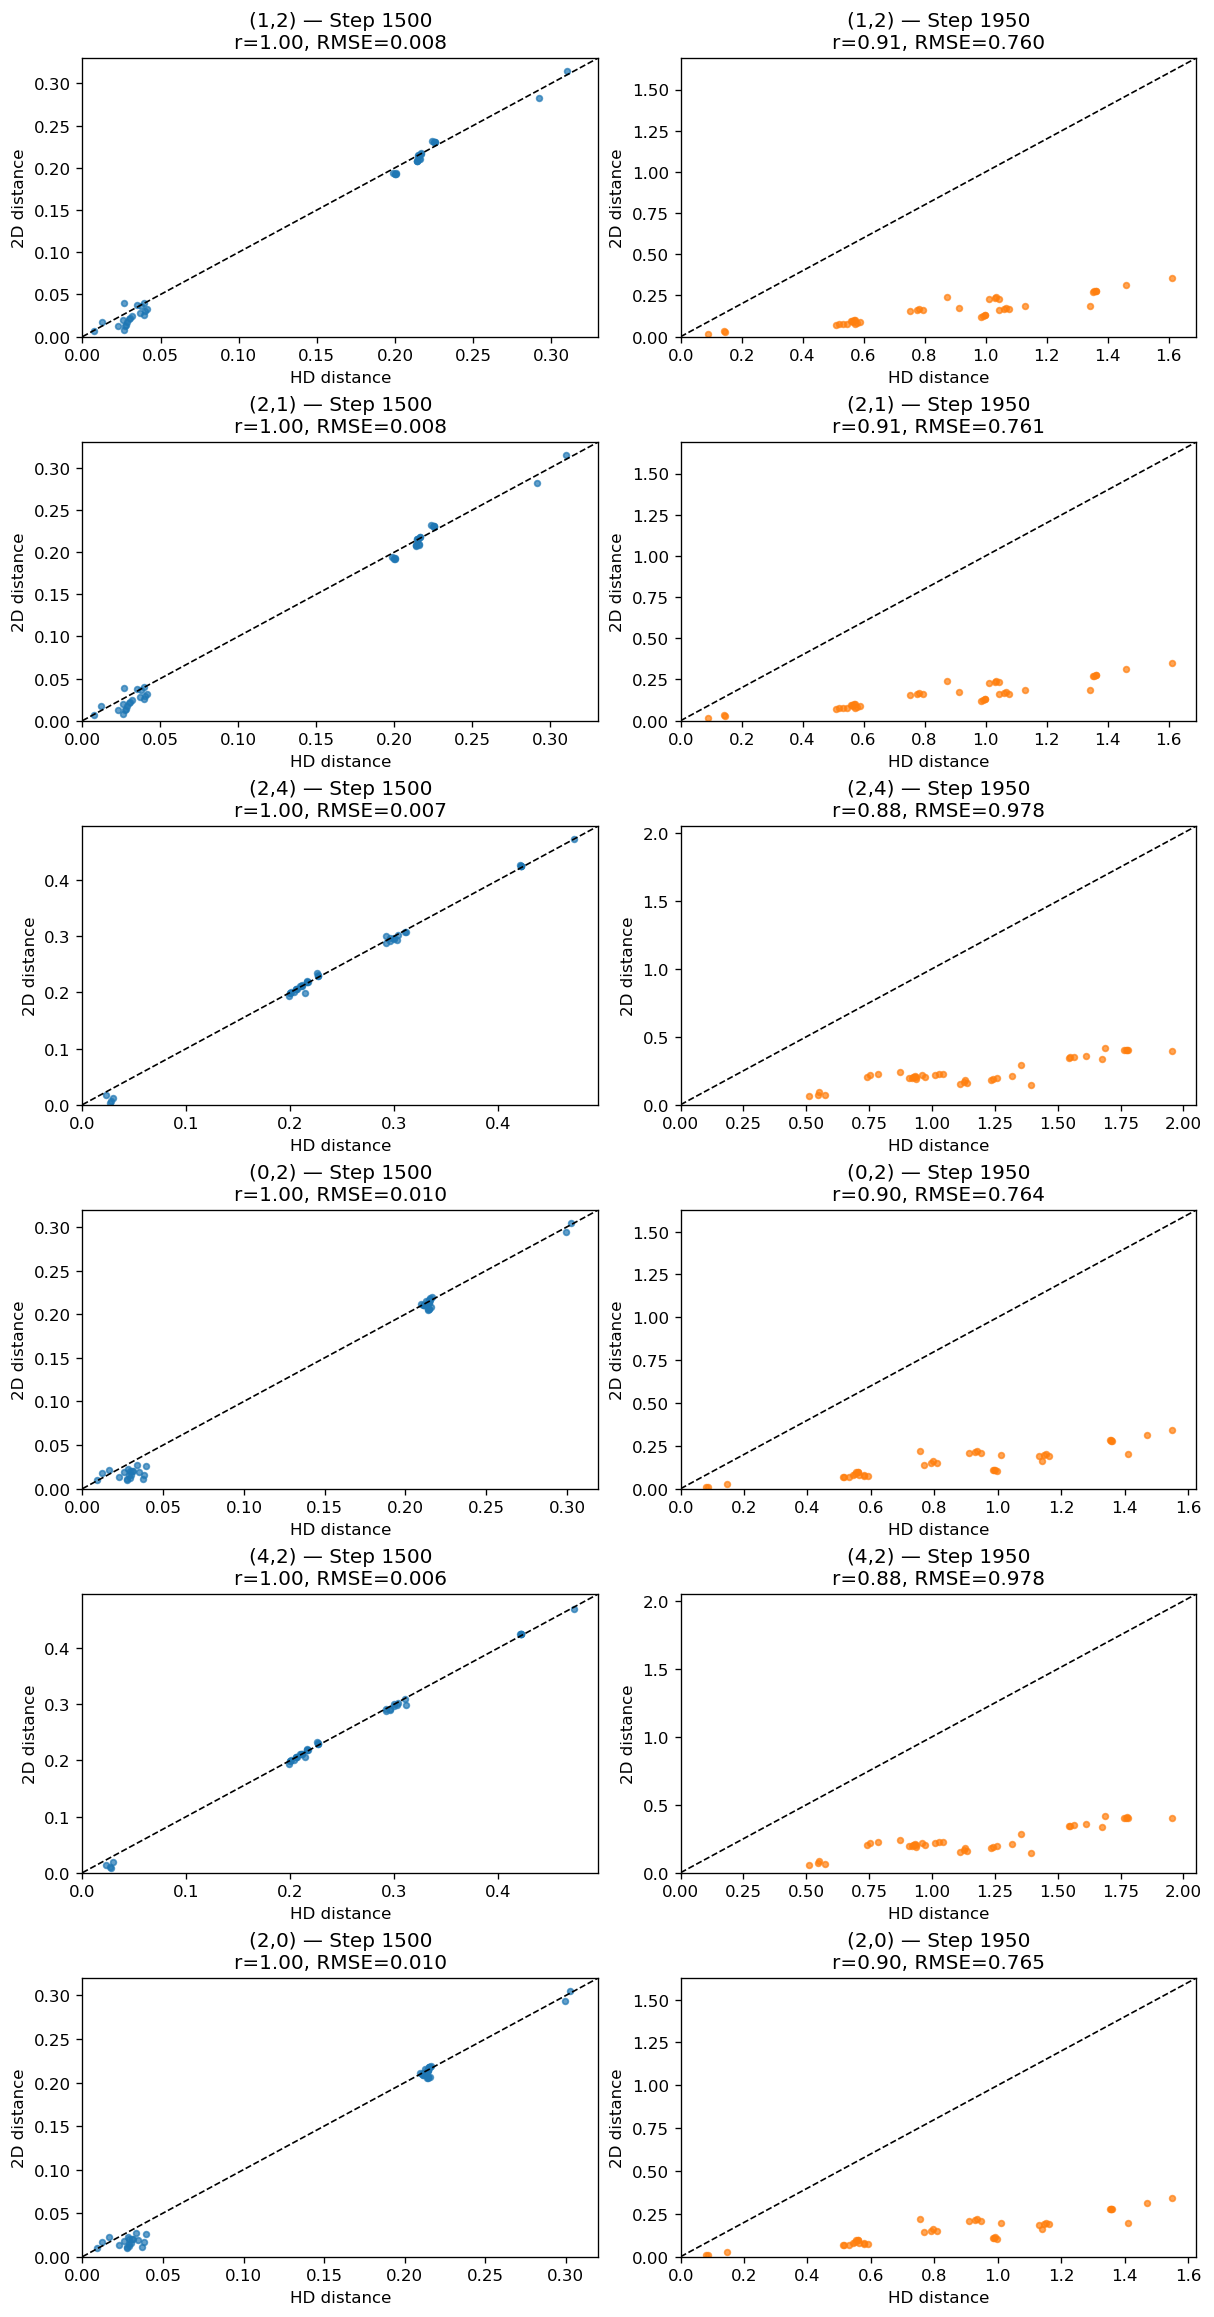

pair_label, 2D_disp, HD_feature_disp
(1,2), 0.101, 0.532
(2,1), 0.101, 0.532
(2,4), 0.091, 0.788
(0,2), 0.086, 0.530
(4,2), 0.086, 0.788
(2,0), 0.086, 0.530


In [145]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import manifold
from sklearn.metrics import euclidean_distances
from scipy.linalg import orthogonal_procrustes
import pandas as pd

# Get H2_avg (time_steps, items_n, h2_size) from CSV if not already present
if 'all_h2s' in globals():
    H2_avg = all_h2s
else:
    def load_h2_mean_from_csv_gz(csv_gz_path):
        df = pd.read_csv(csv_gz_path, compression='gzip')
        seed_cols = [c for c in df.columns if c.startswith('seed_')]
        grouped = df.groupby(['time_step', 'item', 'unit'])[seed_cols].mean()
        mean_series = grouped.mean(axis=1)
        T = int(df['time_step'].max()) + 1
        I = int(df['item'].max()) + 1
        U = int(df['unit'].max()) + 1
        arr = np.zeros((T, I, U))
        for (t, i, u), val in mean_series.items():
            arr[int(t), int(i), int(u)] = float(val)
        return arr
    H2_avg = load_h2_mean_from_csv_gz('conjunctive_lazy_rich_h2s.csv.gz')

time_steps, items_n_inferred, h2_size = H2_avg.shape
step_a = min(1500, time_steps - 1)
step_b = min(1950, time_steps - 1)
seed = mds_seed if 'mds_seed' in globals() else 0

def build_pairs(X_items):
    vecs, labels = [], []
    for i in range(items_n_inferred):
        for j in range(items_n_inferred):
            if i == j:
                continue
            v = np.concatenate([X_items[i], X_items[j]], axis=0)
            vecs.append(v)
            labels.append(f"({i},{j})")
    V = np.asarray(vecs)
    V = V - V.mean(axis=0, keepdims=True)
    return V, labels

Va, la = build_pairs(H2_avg[step_a])
Vb, lb = build_pairs(H2_avg[step_b])
assert la == lb

Da = euclidean_distances(Va)
Db = euclidean_distances(Vb)

# Independent 2D MDS per step
mds = manifold.MDS(n_components=2, dissimilarity='precomputed', random_state=seed, n_init=4, normalized_stress='auto')
A = mds.fit(Da).embedding_
B = manifold.MDS(n_components=2, dissimilarity='precomputed', random_state=seed, n_init=4, normalized_stress='auto').fit(Db).embedding_

# Procrustes-align B to A to remove rotation/scale/translation
A0 = A - A.mean(axis=0, keepdims=True)
B0 = B - B.mean(axis=0, keepdims=True)
R, _ = orthogonal_procrustes(B0, A0)
BR = B0 @ R
s = (A0 * BR).sum() / (BR * BR).sum()
B_aligned = s * BR + A.mean(axis=0, keepdims=True)

# 2D interpoint distances
da2 = euclidean_distances(A)
db2 = euclidean_distances(B_aligned)

# Top movers by aligned 2D displacement
disp = np.linalg.norm(B_aligned - A, axis=1)
top_k = 6
top_idx = np.argsort(-disp)[:top_k]

# Helper: correlation and RMSE between HD and 2D distances for a focal point p
def fit_quality_for_point(p, D_hd, D_2d):
    mask = np.ones(D_hd.shape[0], dtype=bool)
    mask[p] = False
    x = D_hd[p, mask]
    y = D_2d[p, mask]
    # Guard against all-zeros
    if np.allclose(x.std(), 0) or np.allclose(y.std(), 0):
        r = np.nan
    else:
        r = np.corrcoef(x, y)[0, 1]
    rmse = np.sqrt(np.mean((x - y) ** 2))
    return r, rmse, x, y

# Plot: for each top-moving point, HD vs 2D distances at step A and B
rows = top_k
fig, axes = plt.subplots(rows, 2, figsize=(10, 3.2 * rows), constrained_layout=True)
axes = np.atleast_2d(axes)

for r, p in enumerate(top_idx):
    rA, rmA, xA, yA = fit_quality_for_point(p, Da, da2)
    rB, rmB, xB, yB = fit_quality_for_point(p, Db, db2)

    ax = axes[r, 0]
    ax.scatter(xA, yA, s=12, alpha=0.7)
    lim = [0, max(xA.max(), yA.max()) * 1.05]
    ax.plot(lim, lim, 'k--', lw=1)
    ax.set_xlim(lim); ax.set_ylim(lim)
    ax.set_title(f"{la[p]} — Step {step_a}\nr={rA:.2f}, RMSE={rmA:.3f}")
    ax.set_xlabel("HD distance"); ax.set_ylabel("2D distance")

    ax = axes[r, 1]
    ax.scatter(xB, yB, s=12, alpha=0.7, color='C1')
    lim = [0, max(xB.max(), yB.max()) * 1.05]
    ax.plot(lim, lim, 'k--', lw=1)
    ax.set_xlim(lim); ax.set_ylim(lim)
    ax.set_title(f"{la[p]} — Step {step_b}\nr={rB:.2f}, RMSE={rmB:.3f}")
    ax.set_xlabel("HD distance"); ax.set_ylabel("2D distance")

plt.show()

# Optional: table of 2D displacement vs true HD displacement of that point (feature space)
hd_disp = np.linalg.norm(Vb - Va, axis=1)
print("pair_label, 2D_disp, HD_feature_disp")
for p in top_idx:
    print(f"{la[p]}, {disp[p]:.3f}, {hd_disp[p]:.3f}")

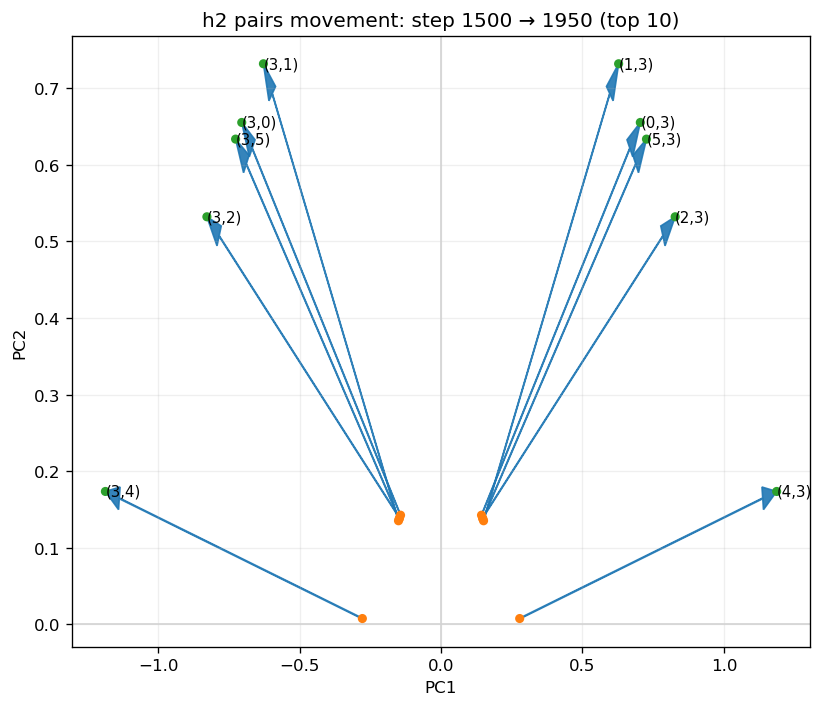

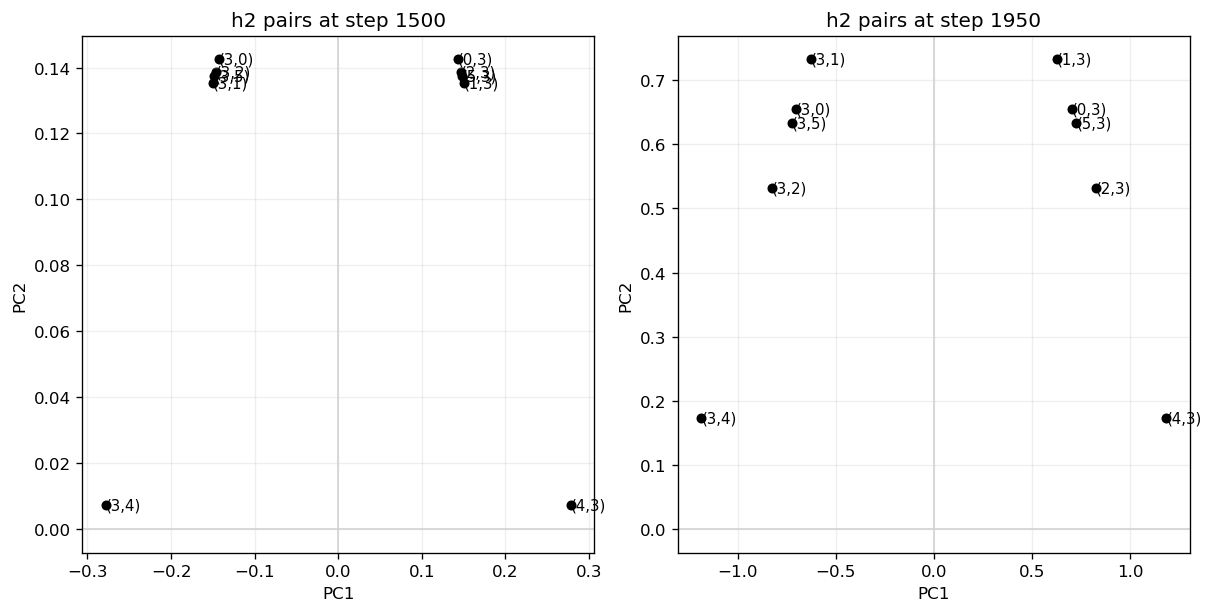

In [146]:
# h2 pair changes between steps 1500 and 1950: show top-5 moving pairs with arrows
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Prepare h2 data (mean across seeds)
H2_avg = all_h2s
time_steps, items_n_inferred, h2_size = H2_avg.shape

# Steps of interest (clip to available range)
step_a = min(1500, time_steps - 1)
step_b = min(1950, time_steps - 1)

# Build pair feature vectors by concatenation for all ordered pairs i != j
def build_pairs(X_items):
    vecs, labels, pairs = [], [], []
    for i in range(items_n_inferred):
        for j in range(items_n_inferred):
            if i == j:
                continue
            v = np.concatenate([X_items[i], X_items[j]], axis=0)
            vecs.append(v)
            labels.append(f"({i},{j})")
            pairs.append((i, j))
    V = np.asarray(vecs)
    V = V - V.mean(axis=0, keepdims=True)
    return V, labels, pairs

Xa, la, pa = build_pairs(H2_avg[step_a])
Xb, lb, pb = build_pairs(H2_avg[step_b])

# Fit PCA on the union to get a common 2D space
X_union = np.vstack([Xa, Xb])
if np.allclose(X_union.var(), 0.0):
    theta = np.linspace(0, 2*np.pi, Xa.shape[0], endpoint=False)
    coords_a = np.stack([np.cos(theta), np.sin(theta)], axis=1)
    coords_b = coords_a.copy()
else:
    pca = PCA(n_components=2, random_state=mds_seed if 'mds_seed' in globals() else 0)
    coords_union = pca.fit_transform(X_union)
    coords_a = coords_union[:Xa.shape[0]]
    coords_b = coords_union[Xa.shape[0]:]

# Compute displacements per pair (match by index; la and lb have same ordering)
deltas = coords_b - coords_a
move_norm = np.linalg.norm(deltas, axis=1)

# Select top-5 moving pairs
top_k = 10
top_idx = np.argsort(-move_norm)[:top_k]

# Plot arrows for the top pairs
plt.figure(figsize=(7, 6))
ax = plt.gca()
for idx in top_idx:
    x0, y0 = coords_a[idx]
    dx, dy = deltas[idx]
    x1, y1 = x0 + dx, y0 + dy
    ax.arrow(x0, y0, dx, dy, head_width=0.03, head_length=0.05, length_includes_head=True,
                fc='C0', ec='C0', alpha=0.9)
    ax.scatter([x0, x1], [y0, y1], s=20, color=['C1','C2'], zorder=3)
    ax.text(x1, y1, la[idx], fontsize=9, ha='left', va='center')
ax.set_title(f"h2 pairs movement: step {step_a} → {step_b} (top {top_k})")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.axhline(0, color='lightgray', linewidth=1)
ax.axvline(0, color='lightgray', linewidth=1)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

# Also provide separate scatter plots for the same 5 pairs at each step (optional clarity)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10., 5.), constrained_layout=True)
ax1.set_title(f"h2 pairs at step {step_a}")
ax2.set_title(f"h2 pairs at step {step_b}")
for idx in top_idx:
    x0, y0 = coords_a[idx]
    x1, y1 = coords_b[idx]
    ax1.scatter(x0, y0, s=25, color='k')
    ax1.text(x0, y0, la[idx], fontsize=9, ha='left', va='center')
    ax2.scatter(x1, y1, s=25, color='k')
    ax2.text(x1, y1, la[idx], fontsize=9, ha='left', va='center')
for axx in (ax1, ax2):
    axx.axhline(0, color='lightgray', linewidth=1)
    axx.axvline(0, color='lightgray', linewidth=1)
    axx.grid(True, alpha=0.2)
    axx.set_xlabel("PC1")
    axx.set_ylabel("PC2")
plt.show()


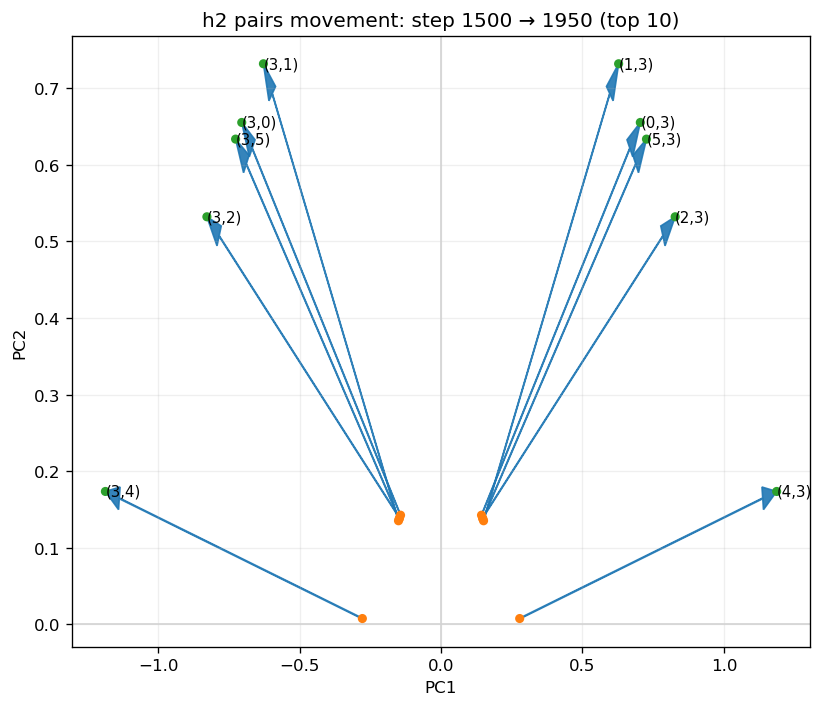

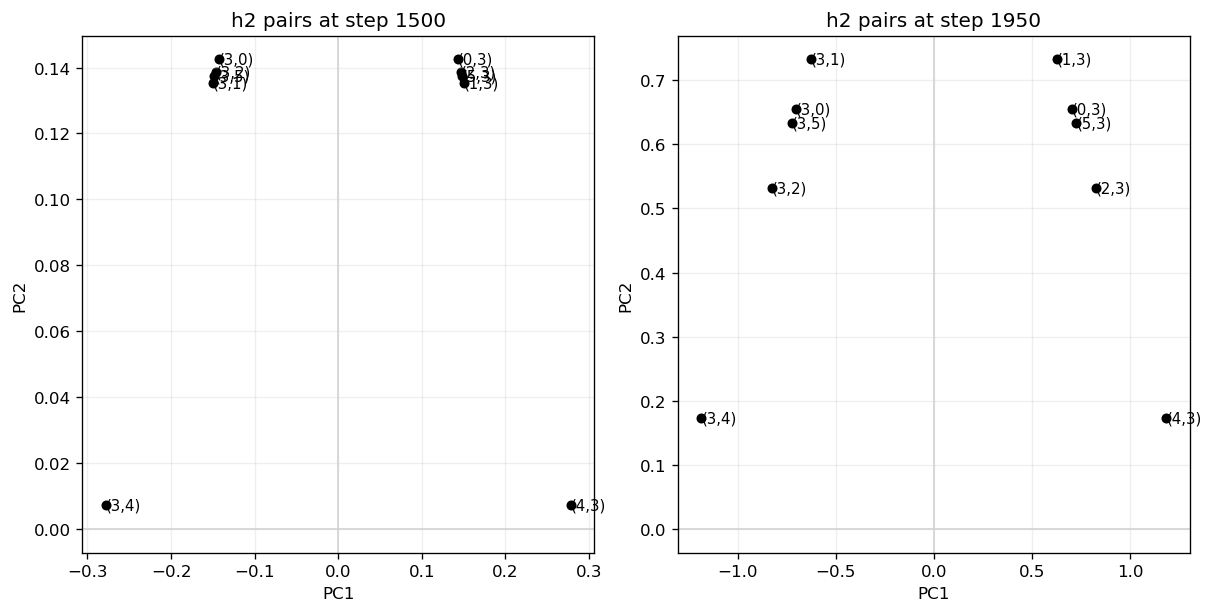

In [148]:
# h2 pair changes between steps 1500 and 1950: show top-5 moving pairs with arrows
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Prepare h2 data (mean across seeds)

H2_avg = H2_avg = all_h2s
time_steps, items_n_inferred, h2_size = H2_avg.shape

# Steps of interest (clip to available range)
step_a = min(1500, time_steps - 1)
step_b = min(1950, time_steps - 1)

# Build pair feature vectors by concatenation for all ordered pairs i != j
def build_pairs(X_items):
    vecs, labels, pairs = [], [], []
    for i in range(items_n_inferred):
        for j in range(items_n_inferred):
            if i == j:
                continue
            v = np.concatenate([X_items[i], X_items[j]], axis=0)
            vecs.append(v)
            labels.append(f"({i},{j})")
            pairs.append((i, j))
    V = np.asarray(vecs)
    V = V - V.mean(axis=0, keepdims=True)
    return V, labels, pairs

Xa, la, pa = build_pairs(H2_avg[step_a])
Xb, lb, pb = build_pairs(H2_avg[step_b])

# Fit PCA on the union to get a common 2D space
X_union = np.vstack([Xa, Xb])
if np.allclose(X_union.var(), 0.0):
    theta = np.linspace(0, 2*np.pi, Xa.shape[0], endpoint=False)
    coords_a = np.stack([np.cos(theta), np.sin(theta)], axis=1)
    coords_b = coords_a.copy()
else:
    pca = PCA(n_components=2, random_state=mds_seed if 'mds_seed' in globals() else 0)
    coords_union = pca.fit_transform(X_union)
    coords_a = coords_union[:Xa.shape[0]]
    coords_b = coords_union[Xa.shape[0]:]

# Compute displacements per pair (match by index; la and lb have same ordering)
deltas = coords_b - coords_a
move_norm = np.linalg.norm(deltas, axis=1)

# Select top-5 moving pairs
top_k = 10
top_idx = np.argsort(-move_norm)[:top_k]

# Plot arrows for the top pairs
plt.figure(figsize=(7, 6))
ax = plt.gca()
for idx in top_idx:
    x0, y0 = coords_a[idx]
    dx, dy = deltas[idx]
    x1, y1 = x0 + dx, y0 + dy
    ax.arrow(x0, y0, dx, dy, head_width=0.03, head_length=0.05, length_includes_head=True,
                fc='C0', ec='C0', alpha=0.9)
    ax.scatter([x0, x1], [y0, y1], s=20, color=['C1','C2'], zorder=3)
    ax.text(x1, y1, la[idx], fontsize=9, ha='left', va='center')
ax.set_title(f"h2 pairs movement: step {step_a} → {step_b} (top {top_k})")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.axhline(0, color='lightgray', linewidth=1)
ax.axvline(0, color='lightgray', linewidth=1)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

# Also provide separate scatter plots for the same 5 pairs at each step (optional clarity)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10., 5.), constrained_layout=True)
ax1.set_title(f"h2 pairs at step {step_a}")
ax2.set_title(f"h2 pairs at step {step_b}")
for idx in top_idx:
    x0, y0 = coords_a[idx]
    x1, y1 = coords_b[idx]
    ax1.scatter(x0, y0, s=25, color='k')
    ax1.text(x0, y0, la[idx], fontsize=9, ha='left', va='center')
    ax2.scatter(x1, y1, s=25, color='k')
    ax2.text(x1, y1, la[idx], fontsize=9, ha='left', va='center')
for axx in (ax1, ax2):
    axx.axhline(0, color='lightgray', linewidth=1)
    axx.axvline(0, color='lightgray', linewidth=1)
    axx.grid(True, alpha=0.2)
    axx.set_xlabel("PC1")
    axx.set_ylabel("PC2")
plt.show()


In [157]:
## (4) Heat Maps of Margins

In [ ]:
import numpy as np
import pandas as pd

def load_r_from_csv_gz(csv_gz_path):
    df = pd.read_csv(csv_gz_path, compression="gzip")
    seed_cols = [c for c in df.columns if c.startswith("seed_")]
    steps = np.array(sorted(df["time_step"].unique()))
    items_n = int(df["item"].max()) + 1
    units = int(df["unit"].max()) + 1
    seeds_n = len(seed_cols)
    arr = np.zeros((seeds_n, len(steps), items_n, units), dtype=float)
    step_to_idx = {s: k for k, s in enumerate(steps)}
    for _, row in df.iterrows():
        t = int(row["time_step"]); i = int(row["item"]); u = int(row["unit"])
        k = step_to_idx[t]
        for s_idx, sc in enumerate(seed_cols):
            arr[s_idx, k, i, u] = row[sc]
    return arr, steps  # (seeds, K, items, units), saved time steps

def nearest_index(saved_steps, target_step):
    idx = int(np.argmin(np.abs(saved_steps - target_step)))
    return idx, int(saved_steps[idx])

def print_pair_grid(rvals_1d, name="r1", decimals=3):
    items_n = rvals_1d.shape[0]
    fmt = f"{{:.{decimals}f}}"
    # Build string grid of (r(i), r(j))
    grid = [["" for _ in range(items_n+1)] for _ in range(items_n+1)]
    grid[0][0] = f"{name}(i),{name}(j)"
    for j in range(items_n):
        grid[0][j+1] = str(j)
    for i in range(items_n):
        grid[i+1][0] = str(i)
        for j in range(items_n):
            grid[i+1][j+1] = f"({fmt.format(rvals_1d[i])},{fmt.format(rvals_1d[j])})" 
    # Compute column widths
    col_w = [max(len(row[c]) for row in grid) for c in range(items_n+1)]
    # Print
    for row in grid:
        print("  ".join(cell.ljust(col_w[c]) for c, cell in enumerate(row)))

# Paths to your CSV.GZ (change to relative if needed)
r1_csv_gz = "conjunctive_lazy_rich_r1s.csv.gz"
r2_csv_gz = "conjunctive_lazy_rich_r2s.csv.gz"

# Load and average across seeds; take unit 0 since r1/r2 are scalars
R1_all, steps_r1 = load_r_from_csv_gz(r1_csv_gz)
R2_all, steps_r2 = load_r_from_csv_gz(r2_csv_gz)
R1 = R1_all.mean(axis=0)[..., 0]  # (K, items)
R2 = R2_all.mean(axis=0)[..., 0]  # (K, items)

# Choose a target step (change this as needed)
target_step = 1500

k1, actual1 = nearest_index(steps_r1, target_step)
k2, actual2 = nearest_index(steps_r2, target_step)

print(f"\nGrid of r1 pair values at step {actual1}:")
print_pair_grid(R1[k1], name="r1")

print(f"\nGrid of r2 pair values at step {actual2}:")
print_pair_grid(R2[k2], name="r2")


Grid of r1 pair values at step 1500:
r1(i),r1(j)  0                1               2               3                4               5               6             
0            (-0.417,-0.417)  (-0.417,0.206)  (-0.417,0.572)  (-0.417,-0.531)  (-0.417,0.135)  (-0.417,0.068)  (-0.417,0.069)
1            (0.206,-0.417)   (0.206,0.206)   (0.206,0.572)   (0.206,-0.531)   (0.206,0.135)   (0.206,0.068)   (0.206,0.069) 
2            (0.572,-0.417)   (0.572,0.206)   (0.572,0.572)   (0.572,-0.531)   (0.572,0.135)   (0.572,0.068)   (0.572,0.069) 
3            (-0.531,-0.417)  (-0.531,0.206)  (-0.531,0.572)  (-0.531,-0.531)  (-0.531,0.135)  (-0.531,0.068)  (-0.531,0.069)
4            (0.135,-0.417)   (0.135,0.206)   (0.135,0.572)   (0.135,-0.531)   (0.135,0.135)   (0.135,0.068)   (0.135,0.069) 
5            (0.068,-0.417)   (0.068,0.206)   (0.068,0.572)   (0.068,-0.531)   (0.068,0.135)   (0.068,0.068)   (0.068,0.069) 
6            (0.069,-0.417)   (0.069,0.206)   (0.069,0.572)   (0.069,-0.531)   (

In [ ]:
)
    arr = np.zeros((seeds_n, len(steps), items_n, units), dtype=float)
    step_to_idx = {s: k for k, s in enumerate(steps)}
    for _, row in df.iterrows():
        t = int(row["time_step"]); i = int(row["item"]); u = int(row["unit"])
        k = step_to_idx[t]
        for s_idx, sc in enumerate(seed_cols):
            arr[s_idx, k, i, u] = row[sc]
    return arr, steps  # (seeds, K, items, units), saved time steps

def nearest_index(saved_steps, target_step):
    idx = int(np.argmin(np.abs(saved_steps - target_step)))
    return idx, int(saved_steps[idx])

def print_pair_grid(rvals_1d, name="r1", decimals=3):
    items_n = rvals_1d.shape[0]
    fmt = f"{{:.{decimals}f}}"
    # Build string grid of (r(i), r(j))
    grid = [["" for _ in range(items_n+1)] for _ in range(items_n+1)]
    grid[0][0] = f"{name}(i),{name}(j)"
    for j in range(items_n):
        grid[0][j+1] = str(j)
    for i in range(items_n):
        grid[i+1][0] = str(i)
        for j in range(items_n):
            grid[i+1][j+1] = f"({fmt.format(rvals_1d[i])},{fmt.format(rvals_1d[j])})" 
    # Compute column widths
    col_w = [max(len(row[c]) for row in grid) for c in range(items_n+1)]
    # Print
    for row in grid:
        print("  ".join(cell.ljust(col_w[c]) for c, cell in enumerate(row)))

# Paths to your CSV.GZ (change to relative if needed)
r1_csv_gz = "conjunctive_lazy_rich_r1s.csv.gz"
r2_csv_gz = "conjunctive_lazy_rich_r2s.csv.gz"

# Load and average across seeds; take unit 0 since r1/r2 are scalars
R1_all, steps_r1 = load_r_from_csv_gz(r1_csv_gz)
R2_all, steps_r2 = load_r_from_csv_gz(r2_csv_gz)
R1 = R1_all.mean(axis=0)[..., 0]  # (K, items)
R2 = R2_all.mean(axis=0)[..., 0]  # (K, items)

# Choose a target step (change this as needed)
target_step = 1500

k1, actual1 = nearest_index(steps_r1, target_step)
k2, actual2 = nearest_index(steps_r2, target_step)

print(f"\nGrid of r1 pair values at step {actual1}:")
print_pair_grid(R1[k1], name="r1")

print(f"\nGrid of r2 pair values at step {actual2}:")
print_pair_grid(R2[k2], name="r2")

In [154]:
# Print at standard nine positions (map to nearest saved step)
positions = [0.00, 0.10, 0.20, 0.50, 0.65, 0.75, 0.85, 0.90, 1.00]

def print_all_positions(R, steps, name):
    max_step = int(steps.max())
    for p in positions:
        tgt = int(p * max_step)
        k, actual = nearest_index(steps, tgt)
        print(f"\nGrid of {name} pair values at step {actual} (pos={p:.2f}):")
        print_pair_grid(R[k], name=name)

print_all_positions(R1, steps_r1, "r1")
print_all_positions(R2, steps_r2, "r2")


Grid of r1 pair values at step 0 (pos=0.00):
r1(i),r1(j)  0                1               2               3                4               5               6             
0            (-0.236,-0.236)  (-0.236,0.155)  (-0.236,0.472)  (-0.236,-0.251)  (-0.236,0.084)  (-0.236,0.057)  (-0.236,0.029)
1            (0.155,-0.236)   (0.155,0.155)   (0.155,0.472)   (0.155,-0.251)   (0.155,0.084)   (0.155,0.057)   (0.155,0.029) 
2            (0.472,-0.236)   (0.472,0.155)   (0.472,0.472)   (0.472,-0.251)   (0.472,0.084)   (0.472,0.057)   (0.472,0.029) 
3            (-0.251,-0.236)  (-0.251,0.155)  (-0.251,0.472)  (-0.251,-0.251)  (-0.251,0.084)  (-0.251,0.057)  (-0.251,0.029)
4            (0.084,-0.236)   (0.084,0.155)   (0.084,0.472)   (0.084,-0.251)   (0.084,0.084)   (0.084,0.057)   (0.084,0.029) 
5            (0.057,-0.236)   (0.057,0.155)   (0.057,0.472)   (0.057,-0.251)   (0.057,0.084)   (0.057,0.057)   (0.057,0.029) 
6            (0.029,-0.236)   (0.029,0.155)   (0.029,0.472)   (0.029,-0.

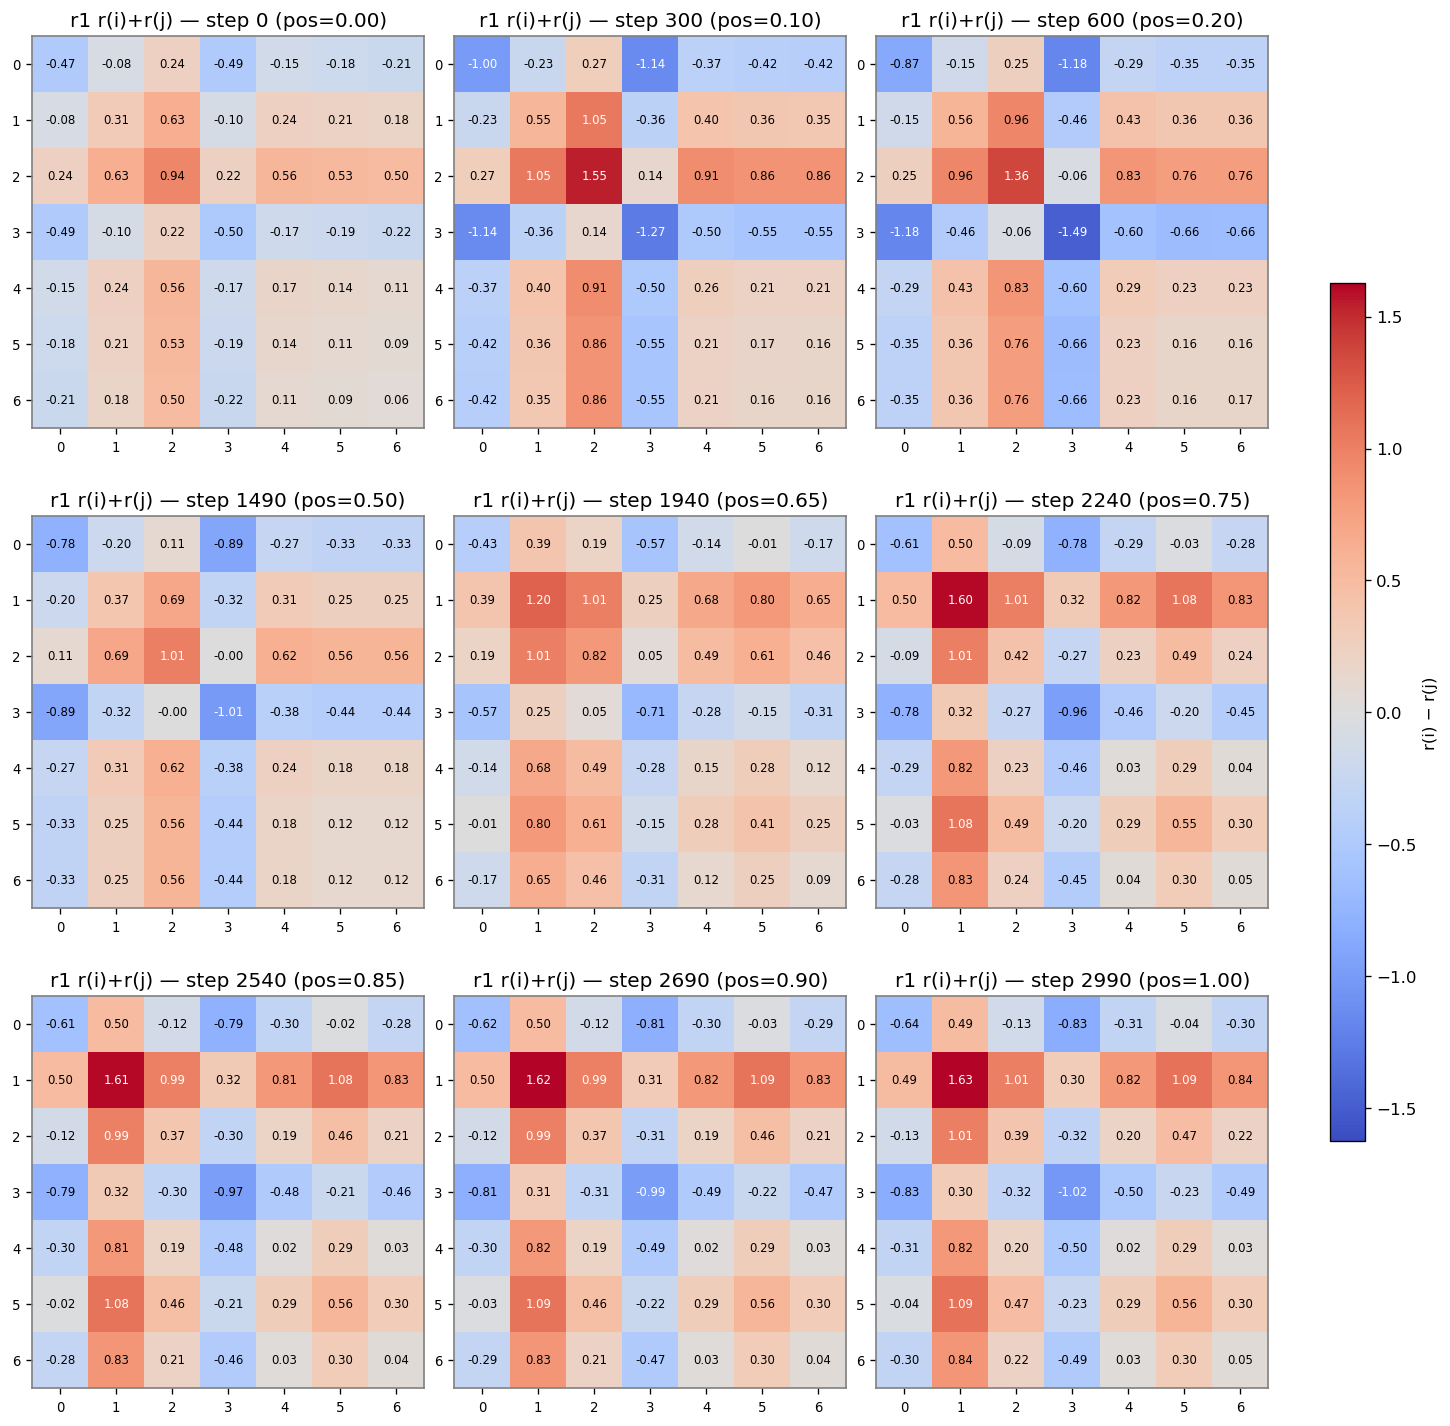

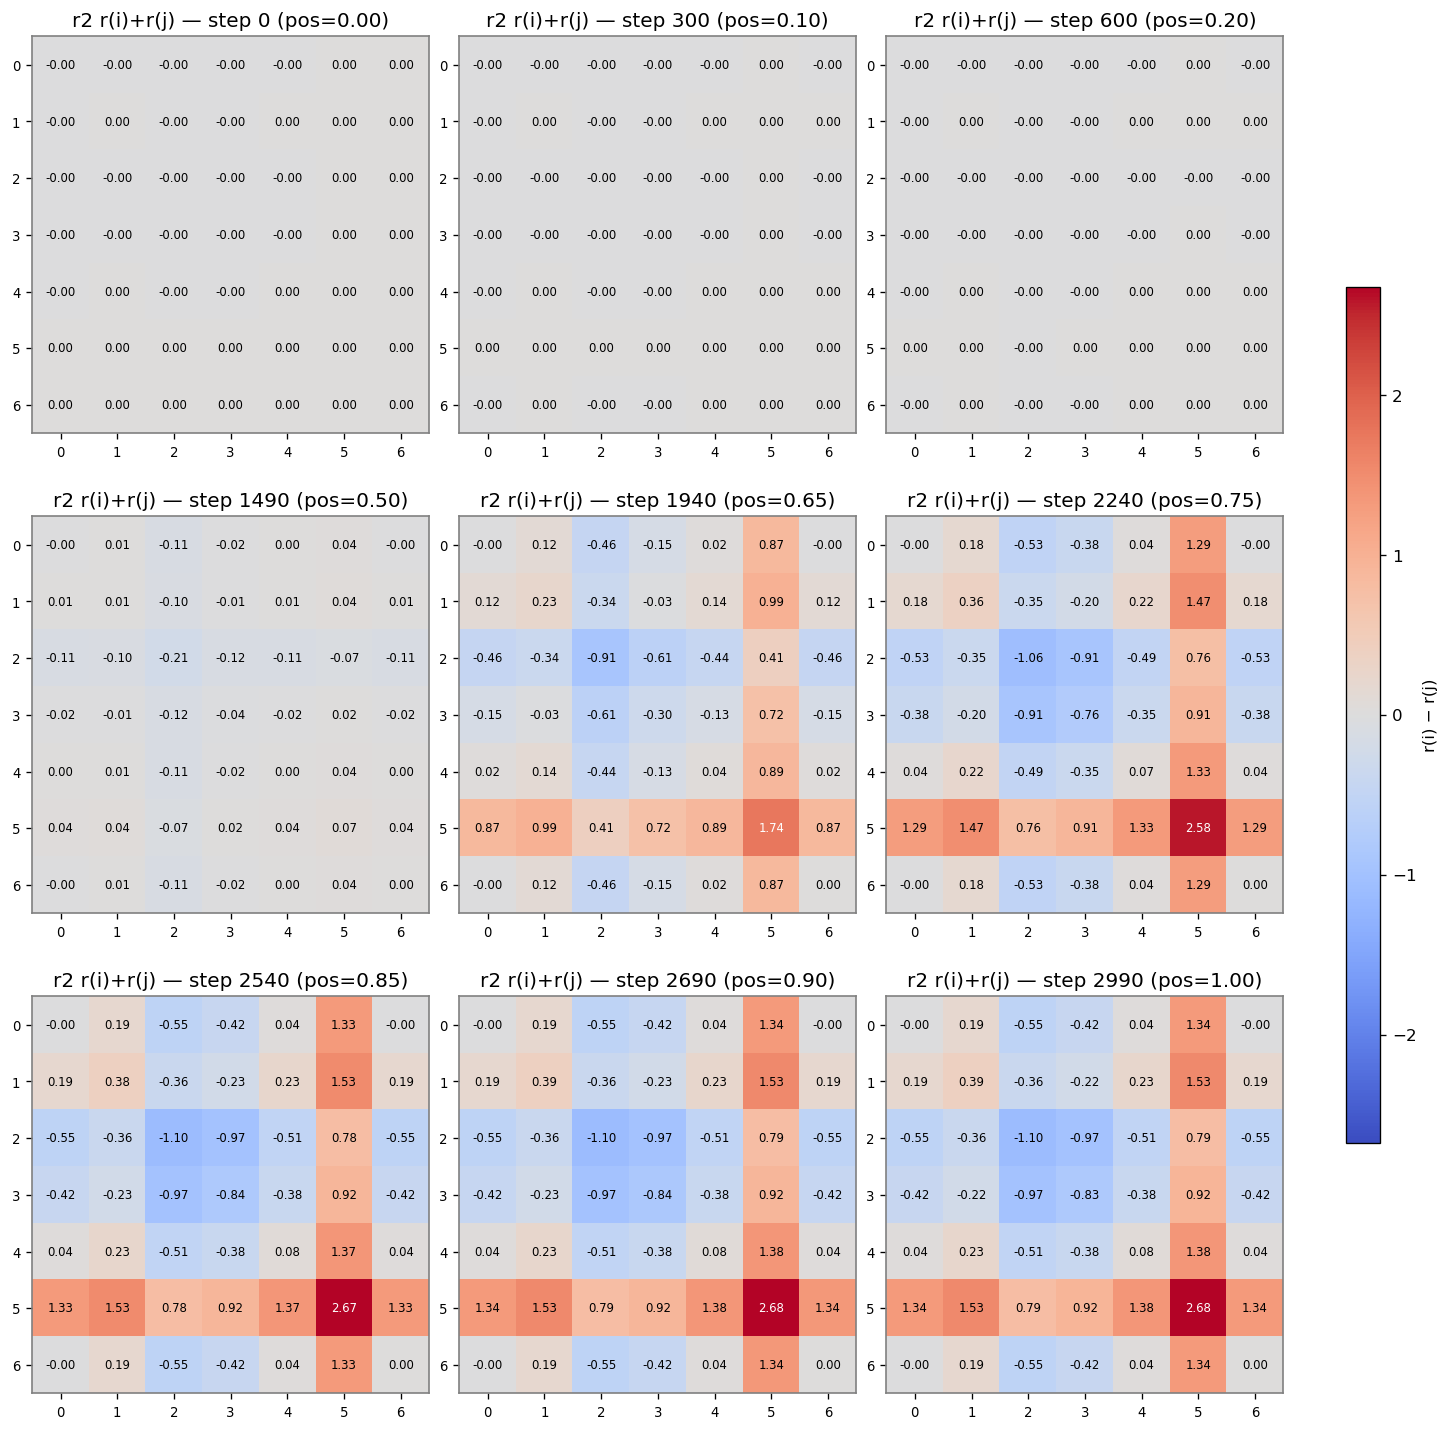

In [155]:
# Heatmap-style pair grids (like margins) for r1 and r2: cell = r(i) + r(j) with numeric annotations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def load_r_from_csv_gz(csv_gz_path):
    df = pd.read_csv(csv_gz_path, compression="gzip")
    seed_cols = [c for c in df.columns if c.startswith("seed_")]
    steps = np.array(sorted(df["time_step"].unique()))
    items_n = int(df["item"].max()) + 1
    units = int(df["unit"].max()) + 1
    seeds_n = len(seed_cols)
    arr = np.zeros((seeds_n, len(steps), items_n, units), dtype=float)
    step_to_idx = {s: k for k, s in enumerate(steps)}
    for _, row in df.iterrows():
        t = int(row["time_step"]); i = int(row["item"]); u = int(row["unit"])
        k = step_to_idx[t]
        for s_idx, sc in enumerate(seed_cols):
            arr[s_idx, k, i, u] = row[sc]
    return arr.mean(axis=0)[..., 0], steps  # (K, items), saved steps

def nearest_index(saved_steps, target_step):
    idx = int(np.argmin(np.abs(saved_steps - target_step)))
    return idx, int(saved_steps[idx])

def plot_readout_heatmaps(R, steps, positions, title_prefix, cmap="coolwarm"):
    # Select slices and determine common color scale across panels
    max_step = int(steps.max())
    sel = [nearest_index(steps, int(p * max_step))[0] for p in positions]
    mats = []
    for k in sel:
        r = R[k]  # shape (items,)
        M = r[:, None] + r[None, :]  # r(i) + r(j)
        mats.append(M)
    all_vals = np.concatenate([m.flatten() for m in mats])
    v = np.max(np.abs(all_vals))
    vmin, vmax = -v, v

    fig, axs = plt.subplots(3, 3, figsize=(12., 12.), constrained_layout=True)
    fig.patch.set_facecolor('white')
    im_last = None

    for idx, p in enumerate(positions):
        r, c = divmod(idx, 3)
        k, actual = nearest_index(steps, int(p * max_step))
        M = mats[idx]
        ax = axs[r, c]
        im_last = ax.imshow(M, cmap=cmap, vmin=vmin, vmax=vmax, interpolation='nearest')
        ax.set_title(f"{title_prefix} r(i)+r(j) — step {actual} (pos={p:.2f})")
        ax.set_xticks(range(M.shape[0])); ax.set_yticks(range(M.shape[0]))
        ax.tick_params(axis='both', labelsize=8)

        # Numeric annotations
        for i in range(M.shape[0]):
            for j in range(M.shape[1]):
                val = M[i, j]
                txt = f"{val:.2f}"
                # choose text color based on background
                color = "white" if abs(val) > 0.6 * v else "black"
                ax.text(j, i, txt, ha='center', va='center', fontsize=7, color=color)

        for pos in ["top", "right", "bottom", "left"]:
            ax.spines[pos].set_linewidth(1)
            ax.spines[pos].set_color([0.5] * 3)

    cbar = fig.colorbar(im_last, ax=axs, shrink=.6, aspect=25)
    cbar.set_label("r(i) − r(j)")
    plt.show()

# Load from CSV.GZ saved every 10 steps (adjust paths if needed)
r1_csv_gz = "conjunctive_lazy_rich_r1s.csv.gz"
r2_csv_gz = "conjunctive_lazy_rich_r2s.csv.gz"
R1, steps_r1 = load_r_from_csv_gz(r1_csv_gz)
R2, steps_r2 = load_r_from_csv_gz(r2_csv_gz)

# Same nine positions as other figures
positions = [0.00, 0.10, 0.20, 0.50, 0.65, 0.75, 0.85, 0.90, 1.00]

# Plot 3x3 grids
plot_readout_heatmaps(R1, steps_r1, positions, title_prefix="r1", cmap="coolwarm")
plot_readout_heatmaps(R2, steps_r2, positions, title_prefix="r2", cmap="coolwarm")

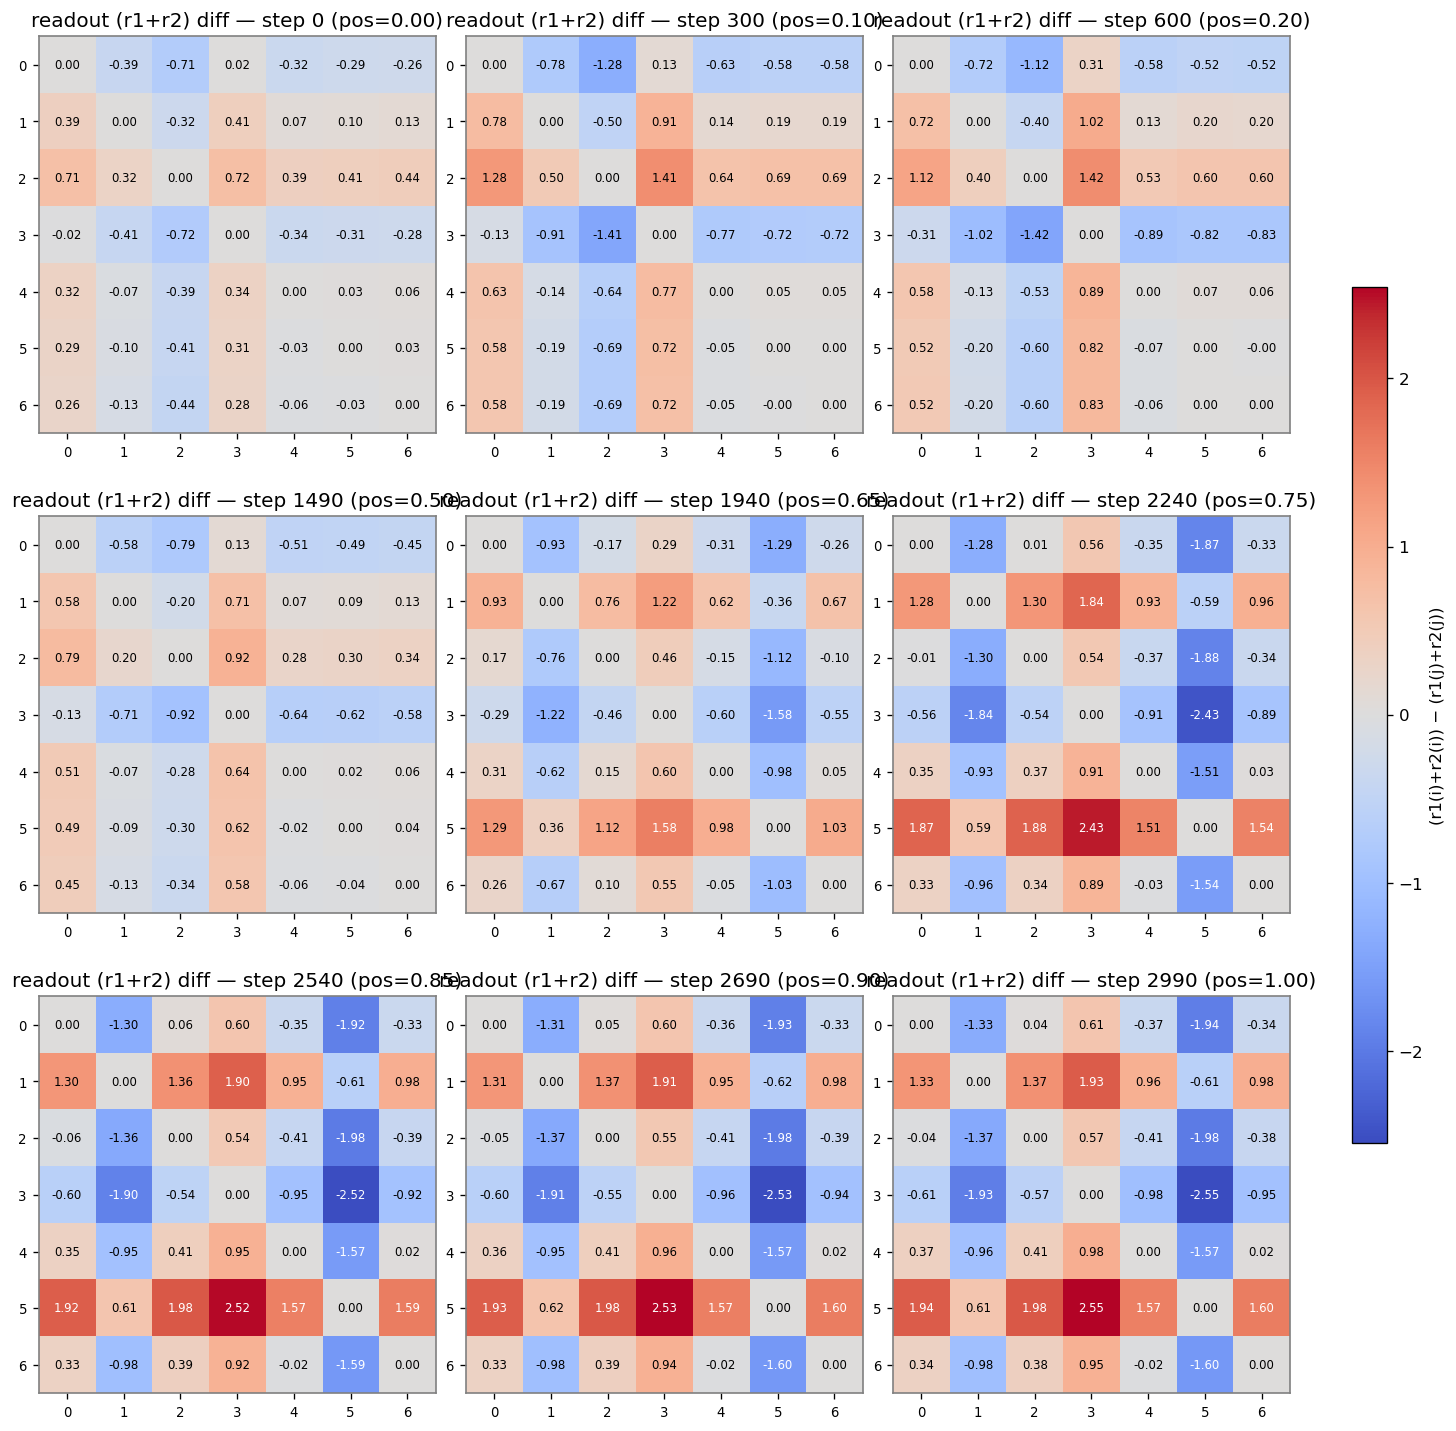

In [156]:
# Combined readout heatmaps: M(i,j) = (r1(i)+r2(i)) − (r1(j)+r2(j)) across nine positions

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def load_r_from_csv_gz(csv_gz_path):
    df = pd.read_csv(csv_gz_path, compression="gzip")
    seed_cols = [c for c in df.columns if c.startswith("seed_")]
    steps = np.array(sorted(df["time_step"].unique()))
    items_n = int(df["item"].max()) + 1
    units = int(df["unit"].max()) + 1
    seeds_n = len(seed_cols)
    arr = np.zeros((seeds_n, len(steps), items_n, units), dtype=float)
    step_to_idx = {s: k for k, s in enumerate(steps)}
    for _, row in df.iterrows():
        t = int(row["time_step"]); i = int(row["item"]); u = int(row["unit"])
        k = step_to_idx[t]
        for s_idx, sc in enumerate(seed_cols):
            arr[s_idx, k, i, u] = row[sc]
    return arr.mean(axis=0)[..., 0], steps  # (K, items), saved steps

def nearest_index(saved_steps, target_step):
    idx = int(np.argmin(np.abs(saved_steps - target_step)))
    return idx, int(saved_steps[idx])

def plot_combined_heatmaps(R1, steps1, R2, steps2, positions, cmap="coolwarm"):
    # Assume same saved steps for r1 and r2; if not, map positions separately
    max_step = int(min(steps1.max(), steps2.max()))
    idxs = [nearest_index(steps1, int(p * max_step))[0] for p in positions]

    # Build matrices and shared color scale
    mats = []
    for k in idxs:
        S = R1[k] + R2[k]             # combined readout per item
        M = S[:, None] - S[None, :]   # pair matrix
        np.fill_diagonal(M, 0.0)
        mats.append(M)
    all_vals = np.concatenate([m.ravel() for m in mats])
    v = float(np.max(np.abs(all_vals))) if all_vals.size else 1.0
    vmin, vmax = -v, v

    fig, axs = plt.subplots(3, 3, figsize=(12., 12.), constrained_layout=True)
    fig.patch.set_facecolor('white')
    im_last = None

    for idx, p in enumerate(positions):
        r, c = divmod(idx, 3)
        k, actual = nearest_index(steps1, int(p * max_step))
        M = mats[idx]
        ax = axs[r, c]
        im_last = ax.imshow(M, cmap=cmap, vmin=vmin, vmax=vmax, interpolation='nearest')
        ax.set_title(f"readout (r1+r2) diff — step {actual} (pos={p:.2f})")
        ax.set_xticks(range(M.shape[0])); ax.set_yticks(range(M.shape[0]))
        ax.tick_params(axis='both', labelsize=8)

        for i in range(M.shape[0]):
            for j in range(M.shape[1]):
                val = M[i, j]
                color = "white" if v > 0 and abs(val) > 0.6 * v else "black"
                ax.text(j, i, f"{val:.2f}", ha='center', va='center', fontsize=7, color=color)

        for pos in ["top", "right", "bottom", "left"]:
            ax.spines[pos].set_linewidth(1)
            ax.spines[pos].set_color([0.5] * 3)

    cbar = fig.colorbar(im_last, ax=axs, shrink=.6, aspect=25)
    cbar.set_label("(r1(i)+r2(i)) − (r1(j)+r2(j))")
    plt.show()

# Paths to CSV.GZ (adjust if needed)
r1_csv_gz = "conjunctive_lazy_rich_r1s.csv.gz"
r2_csv_gz = "conjunctive_lazy_rich_r2s.csv.gz"

R1, steps_r1 = load_r_from_csv_gz(r1_csv_gz)
R2, steps_r2 = load_r_from_csv_gz(r2_csv_gz)

positions = [0.00, 0.10, 0.20, 0.50, 0.65, 0.75, 0.85, 0.90, 1.00]
plot_combined_heatmaps(R1, steps_r1, R2, steps_r2, positions, cmap="coolwarm")